## 📊 Structural & Socioeconomic Analysis – Netherlands Dataset

### 💡 Introduction

This notebook presents an exploratory analysis of the Dutch residential building stock, combining **dwelling-level structural characteristics** with **PC6-level socioeconomic indicators**.

The objective is to:

- Identify relationships between physical dwelling characteristics  
- Map internal dependencies within the housing stock  
- Enrich the structural dataset with socioeconomic context at PC6 level  
- Prepare a robust feature architecture for regression modeling of electricity demand  

The workflow is structured in three stages:

- First, analyze dwelling-level structural characteristics  
- Then, construct compositional variables at PC6 level  
- Finally, integrate external CBS data to capture socioeconomic and housing context  

This combined approach enables a more comprehensive and interpretable modeling of residential electricity demand across the Netherlands.

### 1️⃣ Environment Setup

We use:

- pandas for data handling

- numpy for numerical operations

- matplotlib and seaborn for visualization

In [4]:
import scipy
import statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster

sns.set(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

pandas: 3.0.1
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.0
statsmodels: 0.14.6


## 2️⃣ Read and Filter the National Dwelling Dataset (Residential-only PC6s)

In this step we load the national dwelling dataset and directly construct a residential-only dataset. PC6s with 1 or more non-residential building are removed during this step.


The filtering is applied at two levels:

- Row level: keep rows where gebruiksdoelen == "woonfunctie" and sbicode is NaN.

- PC6 level: keep only those postcode areas where all rows satisfy the row-level condition.

We read only the required columns to keep memory use manageable.

### 2.1 National Dwelling Dataset (Structural Housing Data) - DEGO VNG

In this step, we load the national dwelling-level dataset and construct a residential-only dataset.

The filtering is applied at two levels:

- Row level: keep observations where  
  - `gebruiksdoelen == "woonfunctie"`  
  - `sbicode` is missing (residential-only building)

- PC6 level: retain only postcode areas where all observations satisfy the residential condition  

This ensures that each retained PC6 represents a purely residential area, which is essential for consistent aggregation and interpretation in later stages.

Only the required columns are loaded to reduce memory usage and improve computational efficiency.

In [5]:
file_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\dook_vng_gemeenten_csv\energiedata-match-gemeentecode_NL.csv"
)
sep = ";"

# read only what we need to identify residential-only PC6 codes
pc6_df = pd.read_csv(
    file_path,
    sep=sep,
    usecols=["postcode", "gebruiksdoelen", "sbicode"],
    dtype=str,
    low_memory=False,
)

pc6_df["is_residential_row"] = (
    pc6_df["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & pc6_df["sbicode"].isna()
)

# keep only PC6 where all rows are residential
residential_pc6_mask = pc6_df.groupby("postcode")["is_residential_row"].all()
residential_pc6_codes = residential_pc6_mask[residential_pc6_mask].index

print("Residential-only PC6 codes:", len(residential_pc6_codes))

# now load the dwelling-level structural variables, restricted to those PC6 codes
usecols_structural = [
    "gemeentecode",
    "postcode",
    "sbicode",
    "gebruiksdoelen",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023",
]

df_structural = pd.read_csv(
    file_path,
    sep=sep,
    usecols=usecols_structural,
    dtype=str,
    low_memory=False,
)

df_structural = df_structural[df_structural["postcode"].isin(residential_pc6_codes)].copy()

# enforce the row-level definition (should be redundant but keeps things explicit)
df_structural = df_structural[
    df_structural["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & df_structural["sbicode"].isna()
].copy()

# drop constant filter columns
df_structural = df_structural.drop(columns=["gebruiksdoelen", "sbicode"])

final_columns = [
    "gemeentecode",
    "postcode",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023",
]

df_structural = df_structural[final_columns].copy()

print("Residential-only structural dataset")
print("Rows:", len(df_structural))
print("Unique PC6:", df_structural["postcode"].nunique())

df_structural.head()

Residential-only PC6 codes: 261729
Residential-only structural dataset
Rows: 4881410
Unique PC6: 261729


,gemeentecode,postcode,woning_type,oppervlakte,pand_bouwjaar,energieklasse,gas_ean_count,p6_kwh_2023,p6_kwh_productie_2023,p6_gasm3_2023
0,GM0014,9725CZ,Flatwoning (overig),166.000000,2008,A,0,2471.470000,0.000000,0.000000
1,GM0014,9731HJ,NaN,135.000000,1981,NaN,1,1967.350000,0.000000,938.000000
2,GM0014,9744BD,NaN,163.000000,1912,NaN,1,2682.450000,0.000000,1448.500000
3,GM0014,9736CS,Flatwoning (overig),47.000000,1982,B,1,1647.540000,0.000000,783.520000
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.000000,1970,A,1,2124.250000,0.000000,1221.350000


### 2.2 CBS PC6 Dataset (Socioeconomic and Housing Context)

In this step, we load and prepare a CBS dataset at PC6 level containing socioeconomic and housing-related indicators.

The dataset complements the dwelling-level structural data with contextual information on residents, households, housing characteristics, and social security.

Due to the structure of the raw file, the correct header row is specified during loading and non-data rows are excluded. Only the relevant variables are selected in order to keep the dataset focused and computationally efficient.

In the raw CSV, some variables appear under generic labels such as `Totaal` and `Totaal.1`. Based on the CBS documentation, these are mapped to their official meanings.

The selected variables follow the official CBS definitions and naming:

- `Inwoners totaal` - total number of residents
- `Huishoudens totaal` - total number of private households. Private households consist of one or more residents who are housed alone or together in a dwelling and provide for their own daily needs.
- `Gemiddelde huishoudgrootte` - average household size. The number of inhabitants living in private households divided by the number of private households. Rounded to one decimal place.
- `Niet bewoonde woningen` - number of unoccupied dwellings
- `Gemiddelde WOZ-waarde woningen` - average WOZ value of dwellings. WOZ value (Waardering Onroerende Zaken) is the official, municipality-assessed market value of real estate in the Netherlands.
- `Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering` - Residents receiving unemployment benefits, social assistance, and/or disability benefits. This concerns benefits for residents up to the state pension age.

CBS data uses special placeholder values to encode missing or confidential information:

- `-99997`: 0 to 4 / secret / not present
- `-99995`: subject will be published in a later version

These values do not represent valid observations and are therefore treated as missing values (`NaN`) in the analysis.

At this stage, the dataset is kept in raw PC6 form. Derived indicators will be constructed later only where needed and with explicit denominator choices.

In [6]:
# ----------------------------
# 2.2 Load and Prepare CBS PC6 Dataset (Raw Selected Variables)
# ----------------------------

cbs_file_path = r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\v2_structural_social_economic\2025-cbs_pc6_2023_v2\pc6_2023_v2.csv"

# use the actual CSV headers, then immediately map them to official CBS meanings
cbs_usecols = [
    "Postcode-6",
    "Totaal",
    "Totaal.1",
    "Huishoudgrootte",
    "Niet bewoond",
    "WOZ-waarde\nwoning",
    "Elektra \nverbruik",
    "Gas\nverbruik",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd"
]

df_cbs_pc6 = pd.read_csv(
    cbs_file_path,
    header=8,
    skiprows=[9],
    usecols=cbs_usecols
)

df_cbs_pc6 = df_cbs_pc6.rename(columns={
    "Postcode-6": "postcode",
    "Totaal": "Inwoners totaal",
    "Totaal.1": "Huishoudens totaal",
    "Huishoudgrootte": "Gemiddelde huishoudgrootte",
    "Niet bewoond": "Niet bewoonde woningen",
    "WOZ-waarde\nwoning": "Gemiddelde WOZ-waarde woningen",
    "Elektra \nverbruik": "Gemiddeld elektriciteitsverbruik woning",
    "Gas\nverbruik": "Gemiddeld gasverbruik woning",
    "Personen met WW, Bijstand en/of AO uitkering\nBeneden AOW-leeftijd":
        "Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering"
})

# replace CBS placeholder values with NaN
df_cbs_pc6 = df_cbs_pc6.replace([-99997, -99995], np.nan)

# convert non-postcode columns to numeric
numeric_cols = [
    "Inwoners totaal",
    "Huishoudens totaal",
    "Gemiddelde huishoudgrootte",
    "Niet bewoonde woningen",
    "Gemiddelde WOZ-waarde woningen",
    "Gemiddeld elektriciteitsverbruik woning",
    "Gemiddeld gasverbruik woning",
    "Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering"
]

df_cbs_pc6[numeric_cols] = df_cbs_pc6[numeric_cols].apply(pd.to_numeric, errors="coerce")

print("CBS dataset prepared")
print("Rows:", len(df_cbs_pc6))
print("Unique PC6:", df_cbs_pc6["postcode"].nunique())

df_cbs_pc6.head()

CBS dataset prepared
Rows: 464138
Unique PC6: 464138


,postcode,Inwoners totaal,Huishoudens totaal,Gemiddelde huishoudgrootte,Niet bewoonde woningen,Gemiddelde WOZ-waarde woningen,Gemiddeld gasverbruik woning,Gemiddeld elektriciteitsverbruik woning,"Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering"
0,1011AB,5.0,5.0,1.4,NaN,NaN,NaN,NaN,NaN
1,1011AC,25.0,15.0,1.5,NaN,794.0,1260.0,2680.0,NaN
2,1011AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1011AE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1011AG,5.0,5.0,1.2,NaN,NaN,NaN,NaN,NaN


## 3️⃣ Preparation of the dwelling-level structural dataset

Before analysing the structural characteristics of the housing stock, the dwelling-level dataset must be prepared to ensure that key variables are consistently formatted, numerically interpretable, and free of obvious data issues.

This preparation step focuses on **structural dwelling features**, which will later be used both for exploratory analysis and for aggregation to postcode (PC6) level. The preparation consists of four steps:

1. **Standardizing categorical variables**  
   Text-based categorical variables such as dwelling type (`woning_type`) and energy label (`energieklasse`) are cleaned to ensure consistent formatting and to avoid artificial category duplication caused by whitespace or string inconsistencies.

2. **Converting numeric variables**  
   Structural characteristics (e.g., floor area and construction year) and energy-related variables are explicitly converted to numeric format to ensure that downstream calculations and statistical operations behave correctly.

3. **Removing implausible observations**  
   Basic plausibility checks are applied to remove clearly invalid values, such as missing or non-positive floor areas and construction years that exceed the current year.

4. **Handling energy label availability**  
   Dwellings without a registered energy label are retained in the dataset and assigned to a dedicated category (`no_label`). This allows later analysis to distinguish between labelled dwellings and dwellings for which no official energy label is available.

### 3.1 Structural dataset preparation

In [7]:
# ----------------------------
# 3.1 Structural dataset preparation
# ----------------------------

df_dwelling = df_structural.copy()

# 1) standardize categorical strings
for c in ["woning_type", "energieklasse"]:
    df_dwelling[c] = df_dwelling[c].astype(str).str.strip()

df_dwelling["woning_type"] = df_dwelling["woning_type"].replace({"nan": np.nan, "": np.nan})
df_dwelling["energieklasse"] = df_dwelling["energieklasse"].replace({"nan": np.nan, "": np.nan})

# 2) numeric conversions
num_cols = [
    "oppervlakte",
    "pand_bouwjaar",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023"
]

for c in num_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# 3) remove implausible values
df_dwelling = df_dwelling[df_dwelling["oppervlakte"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["oppervlakte"] > 0].copy()

df_dwelling = df_dwelling[df_dwelling["pand_bouwjaar"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["pand_bouwjaar"] <= 2026].copy()

# 4) treat dwellings without energy label as structural category
df_dwelling["energieklasse"] = df_dwelling["energieklasse"].fillna("no_label")

label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energieklasse"] = pd.Categorical(
    df_dwelling["energieklasse"],
    categories=label_order,
    ordered=False
)

print("Structural dwelling dataset prepared")
print("Number of dwelling observations:", len(df_dwelling))
print("Number of PC6 areas:", df_dwelling["postcode"].nunique())

Structural dwelling dataset prepared
Number of dwelling observations: 4881409
Number of PC6 areas: 261729


### 3.2 Data integrity diagnostics

Before proceeding with the structural analysis, several diagnostics are performed to verify the integrity and internal consistency of the energy variables included in the dataset.

The dataset contains three energy-related variables:

- `p6_kwh_2023` — electricity consumption  
- `p6_gasm3_2023` — gas consumption  
- `p6_kwh_productie_2023` — electricity production (PV)

Electricity consumption and PV production originate from postcode-level statistics that report **average values per dwelling at PC6 level**. As a result, these values are repeated for all dwellings within the same postcode area in the dataset.  

Gas consumption behaves differently: dwellings without a gas connection have zero gas consumption, meaning that `p6_gasm3_2023` can vary within the same PC6 area depending on the presence of a gas connection.

To verify the integrity of these variables, three diagnostics are performed.

**1. Row-level missing and zero values**

First, the number of missing values and zero values is counted across dwelling observations.  
This provides a basic integrity check and allows identification of potential reporting gaps or structurally meaningful zeros.

**2. PC6-level all-zero checks**

Next, the number of postcode areas where all dwelling rows report zero values is computed.  
This diagnostic identifies postcode areas that appear to have zero electricity consumption, zero gas consumption, or zero PV production across all dwellings.

This information is useful because row-level zeros may arise either from true postcode-level zeros or from dwelling-specific characteristics (such as dwellings without gas connections).

**3. Within-PC6 constancy check**

Finally, we verify that electricity consumption and PV production are constant within each postcode area.  
Since these variables represent postcode-level averages repeated across dwellings, each PC6 area should contain only one unique value for these variables.

Gas consumption is excluded from this constancy check because its variation within PC6 areas reflects meaningful structural differences in gas connectivity between dwellings.

Together, these diagnostics ensure that the energy variables behave consistently with the structure of the source dataset before further analysis is conducted.

In [8]:
# ----------------------------
# 3.2 Data integrity diagnostics
# ----------------------------

# energy variables
energy_cols = [
    "p6_kwh_2023",
    "p6_gasm3_2023",
    "p6_kwh_productie_2023"
]

# ----------------------------
# A. Row-level missing / zero values
# ----------------------------

row_level_check = pd.DataFrame({
    "n_nan_rows": df_dwelling[energy_cols].isna().sum(),
    "n_zero_rows": (df_dwelling[energy_cols] == 0).sum()
})

print("Row-level integrity check for energy variables:")
display(row_level_check)

# ----------------------------
# B. PC6-level all-zero diagnostics
# ----------------------------

pc6_all_zero_check = pd.DataFrame({
    "n_pc6_all_zero": [
        df_dwelling.groupby("postcode")["p6_kwh_2023"].apply(lambda x: (x == 0).all()).sum(),
        df_dwelling.groupby("postcode")["p6_gasm3_2023"].apply(lambda x: (x == 0).all()).sum(),
        df_dwelling.groupby("postcode")["p6_kwh_productie_2023"].apply(lambda x: (x == 0).all()).sum()
    ]
}, index=energy_cols)

print("\nPC6 areas where all dwelling rows have zero energy value:")
display(pc6_all_zero_check)

# ----------------------------
# C. Within-PC6 constancy check
# ----------------------------

constancy_cols = ["p6_kwh_2023", "p6_kwh_productie_2023"]

variation_check = (
    df_dwelling
    .groupby("postcode")[constancy_cols]
    .nunique()
)

n_pc6_with_variation = (variation_check > 1).sum()

print("\nPC6 areas with more than one unique value within postcode:")
display(n_pc6_with_variation)

Row-level integrity check for energy variables:


,n_nan_rows,n_zero_rows
p6_kwh_2023,0,59035
p6_gasm3_2023,0,729690
p6_kwh_productie_2023,0,3421829



PC6 areas where all dwelling rows have zero energy value:


,n_pc6_all_zero
p6_kwh_2023,2974
p6_gasm3_2023,22816
p6_kwh_productie_2023,181101



PC6 areas with more than one unique value within postcode:


p6_kwh_2023              76
p6_kwh_productie_2023    15
dtype: int64

#### Final modelling decision

Postcode areas exhibiting inconsistent electricity or PV values within the same PC6 are removed from the dataset, since these variables represent postcode-level statistics that should be constant across dwellings. In addition, postcode areas reporting zero electricity consumption across all dwellings are excluded from further analysis, as these cases likely reflect measurement artefacts and do not provide meaningful information for modelling residential energy demand.

In [9]:
# ----------------------------
# Remove problematic PC6 areas
# ----------------------------

# 1. PC6 with electricity = 0 across all dwellings
pc6_zero_electricity = (
    df_dwelling
    .groupby("postcode")["p6_kwh_2023"]
    .apply(lambda x: (x == 0).all())
)

pc6_zero_electricity = pc6_zero_electricity[pc6_zero_electricity].index


# 2. PC6 with inconsistent electricity or PV values
pc6_variation = (
    df_dwelling
    .groupby("postcode")[["p6_kwh_2023", "p6_kwh_productie_2023"]]
    .nunique()
)

pc6_inconsistent = pc6_variation[
    (pc6_variation["p6_kwh_2023"] > 1) |
    (pc6_variation["p6_kwh_productie_2023"] > 1)
].index


# 3. Combine both sets
pc6_to_remove = set(pc6_zero_electricity).union(set(pc6_inconsistent))

print("PC6 with zero electricity:", len(pc6_zero_electricity))
print("PC6 with inconsistent electricity/PV:", len(pc6_inconsistent))
print("Total PC6 removed:", len(pc6_to_remove))


# 4. Remove them
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_to_remove)
].copy()

print("\nDataset after filtering")
print("rows:", len(df_dwelling))
print("unique PC6:", df_dwelling["postcode"].nunique())

PC6 with zero electricity: 2974
PC6 with inconsistent electricity/PV: 76
Total PC6 removed: 3050

Dataset after filtering
rows: 4820210
unique PC6: 258679


## 4️⃣ Structural-only exploratory analysis (dwelling features)

This section investigates the internal structure of the housing stock at dwelling level, 
before introducing energy consumption or spatial aggregation.

The purpose is to:

- Quantify variation in structural features
- Identify distributional patterns
- Detect structural imbalances or anomalies
- Examine relationships between dwelling characteristics

The analysis proceeds in four steps:

1. Descriptive statistics (univariate numerical overview)  
2. Distribution visualization  
3. Structural diagnostics  
4. Correlation analysis between dwelling features

### 4.1 Descriptive statistics

We begin with univariate descriptive statistics to characterize the structural distribution of dwelling features.

This step provides:

- Central tendency (mean, median)
- Dispersion (standard deviation, interquartile range)
- Preliminary insight into skewness and spread
- Structural composition across categorical classes

Extreme-value diagnostics are conducted separately in Section 4.3.
Continuous and categorical variables are treated separately.

In [10]:
# 4.1A continuous variables: descriptive statistics

summary_cont = df_dwelling[num_cols].describe(
    percentiles=[0.001, 0.25, 0.5, 0.75, 0.999]
).T

summary_cont

,count,mean,std,min,0.1%,25%,50%,75%,99.9%,max
oppervlakte,4820210.0,117.017397,1025.860448,1.0,22.0,84.00,108.00,136.00,501.00,999999.0
pand_bouwjaar,4820210.0,1966.640725,137.737643,0.0,0.0,1963.00,1978.00,1994.00,2023.00,2024.0
gas_ean_count,4820210.0,0.863655,0.355258,0.0,0.0,1.00,1.00,1.00,2.00,18.0
p6_kwh_2023,4820210.0,2833.935510,1296.503479,14.0,891.0,2093.69,2608.83,3213.00,14274.00,53717.1
p6_kwh_productie_2023,4820210.0,259.876073,538.558356,0.0,0.0,0.00,0.00,261.00,3722.00,17977.0
p6_gasm3_2023,4820210.0,931.647847,594.806501,0.0,0.0,695.48,961.47,1197.67,4343.14,26168.7


In [11]:
# 4.1B categorical variables: counts and shares (energieklasse in efficiency order)

counts_label = (
    df_dwelling["energieklasse"]
    .value_counts(sort=False)
    .reindex(label_order)
)

summary_label = pd.DataFrame({
    "count": counts_label,
    "share_%": (counts_label / len(df_dwelling) * 100).round(3)
})

summary_label

,count,share_%
energieklasse,,
A++++,18187,0.377
A+++,50969,1.057
A++,26943,0.559
A+,52836,1.096
A,924361,19.177
B,525650,10.905
C,791408,16.419
D,299098,6.205
E,171236,3.552


In [12]:
# 4.1C categorical variables: counts and shares (woning_type)

counts_type = df_dwelling["woning_type"].value_counts()

summary_type = pd.DataFrame({
    "count": counts_type,
    "share_%": (counts_type / len(df_dwelling) * 100).round(3)
})

summary_type

,count,share_%
woning_type,,
Rijwoning tussen,955361,19.820
Flatwoning (overig),596385,12.373
Twee-onder-een-kap / rijwoning hoek,583731,12.110
Appartement,349408,7.249
Vrijstaande woning,232606,4.826
Rijwoning hoek,131385,2.726
Maisonnette,86917,1.803
Twee-onder-één-kap,62770,1.302
Galerijwoning,27766,0.576


### 4.2 Distribution visualization

Descriptive statistics are complemented with visual inspection to identify:

- Skewness
- Heavy tails
- Outliers
- Dominant categories
- Structural concentration

Visual inspection provides intuition about distribution shape, which is important before correlation analysis.

For variables with extreme outliers (e.g., floor area), we show both the full-scale distribution and a clipped view for readability.

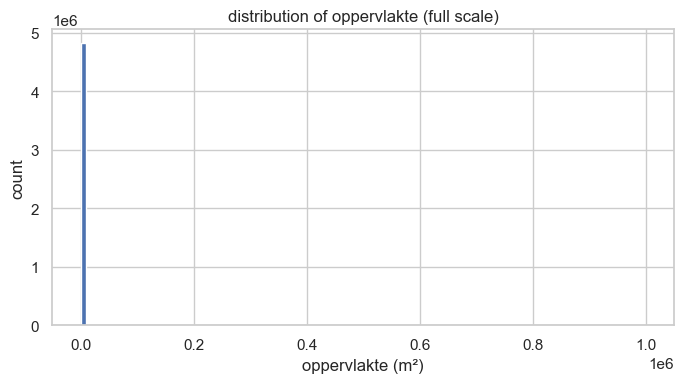

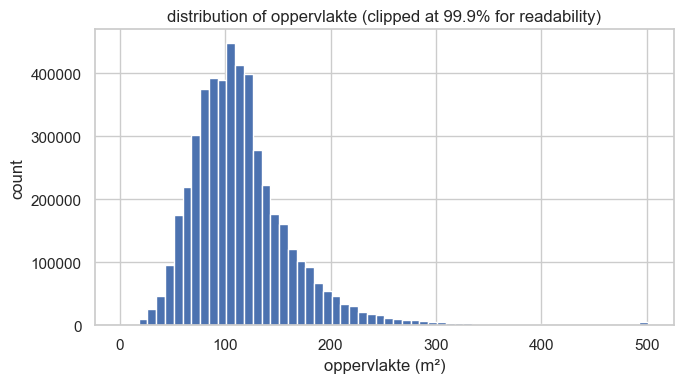

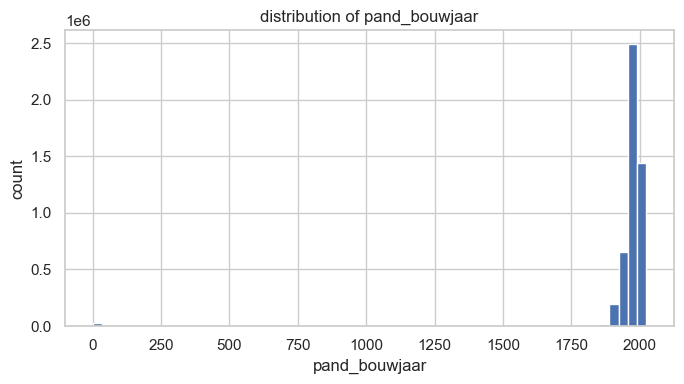

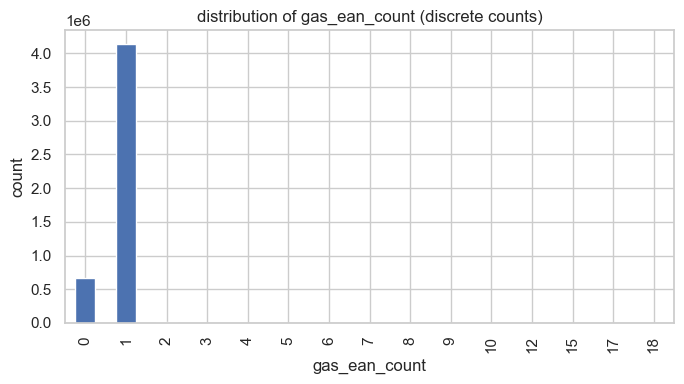

In [13]:
# ----------------------------
# 4.2A numeric distributions
# ----------------------------

# 1) oppervlakte (floor area): show full scale once to reveal extreme tail
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["oppervlakte"].dropna(), bins=100)
plt.title("distribution of oppervlakte (full scale)")
plt.xlabel("oppervlakte (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) oppervlakte (floor area): clipped view for readability only
upper_99 = df_dwelling["oppervlakte"].quantile(0.999)

plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["oppervlakte"].dropna().clip(upper=upper_99), bins=60)
plt.title("distribution of oppervlakte (clipped at 99.9% for readability)")
plt.xlabel("oppervlakte (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3) pand_bouwjaar: normal histogram
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["pand_bouwjaar"].dropna(), bins=60)
plt.title("distribution of pand_bouwjaar")
plt.xlabel("pand_bouwjaar")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 4) gas_ean_count: discrete count plot (not a histogram)
vc_gas = df_dwelling["gas_ean_count"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
vc_gas.plot(kind="bar")
plt.title("distribution of gas_ean_count (discrete counts)")
plt.xlabel("gas_ean_count")
plt.ylabel("count")
plt.tight_layout()
plt.show()

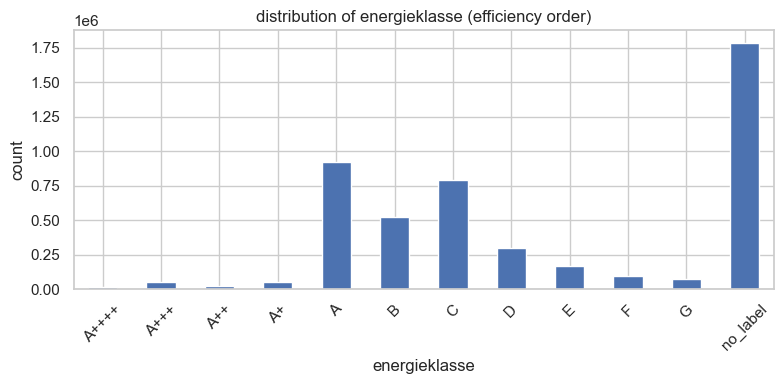

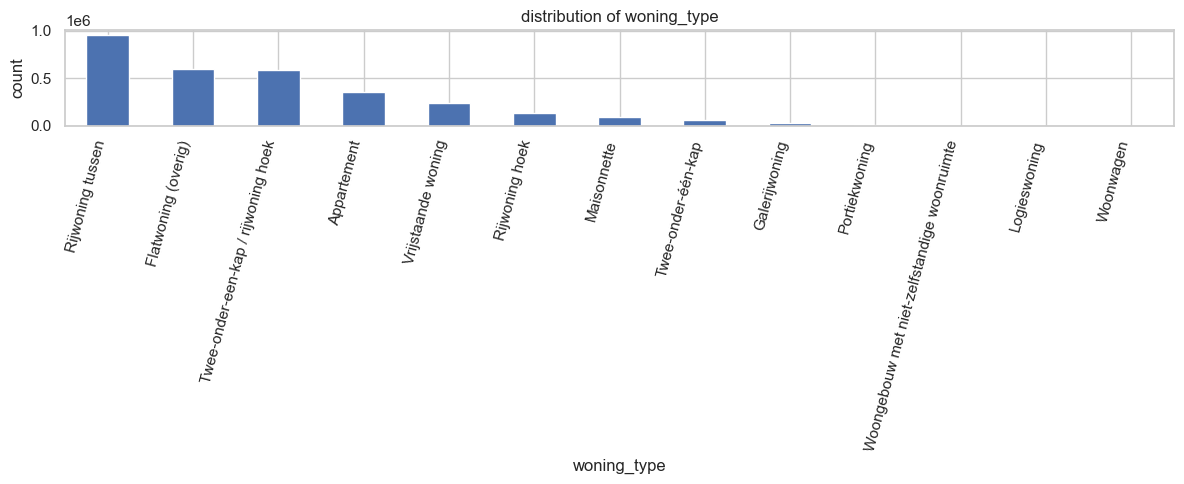

In [14]:
# ----------------------------
# 4.2B categorical distributions
# ----------------------------

# energieklasse bar plot (efficiency order, includes no_label)
plt.figure(figsize=(8, 4))
counts_label.reindex(label_order).plot(kind="bar")
plt.title("distribution of energieklasse (efficiency order)")
plt.xlabel("energieklasse")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# woning_type bar plot
plt.figure(figsize=(12, 5))
counts_type.plot(kind="bar")
plt.title("distribution of woning_type")
plt.xlabel("woning_type")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### 4.3 Structural diagnostics

This subsection identifies modeling-relevant structural properties and applies only transformations that are supported by clear empirical evidence.

We focus on four checks:

- 4.3A Gas connection structure (`gas_ean_count`)
- 4.3B Rare housing type categories (`woning_type`)
- 4.3C Floor area tail diagnostics and threshold decision (`oppervlakte`)
- 4.3D Construction year diagnostics

These checks improve stability and interpretability in later regression stages.

#### 4.3A Gas connection structure (`gas_ean_count`)

We first explore the distribution of gas connections and gas consumption to understand how dwellings access and use gas.  

The purpose of this section is to:

1. Determine if `gas_ean_count` behaves effectively as a binary variable or has meaningful variation.
2. Check for PC6-level vs dwelling-level variation.
3. Inspect gas consumption in dwellings with and without gas connections.
4. Explore whether a potential separation of heating vs cooking/hot water consumption could be feasible.

No assumptions or transformations will be made before inspecting the outputs.

We proceed in structured diagnostic steps.

=== gas_ean_count distribution ===


gas_ean_count
0      673455
1     4133488
2       10816
3        2125
4         247
5          42
6           9
7          14
8           2
9           5
10          2
12          2
15          1
17          1
18          1
Name: count, dtype: int64


Number of unique gas_ean_count values: 15

Share of PC6s with more than one unique gas_ean_count value:
0.21536730851750624

Distribution of unique gas_ean_count values per PC6:


gas_ean_count
1    202968
2     50290
3      4834
4       544
5        38
6         3
7         1
8         1
Name: count, dtype: int64


Gas consumption statistics for dwellings with gas_ean_count = 0:


count    673455.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: p6_gasm3_2023, dtype: float64


Share of dwellings with gas_ean_count = 0 but positive gas consumption:
0.0


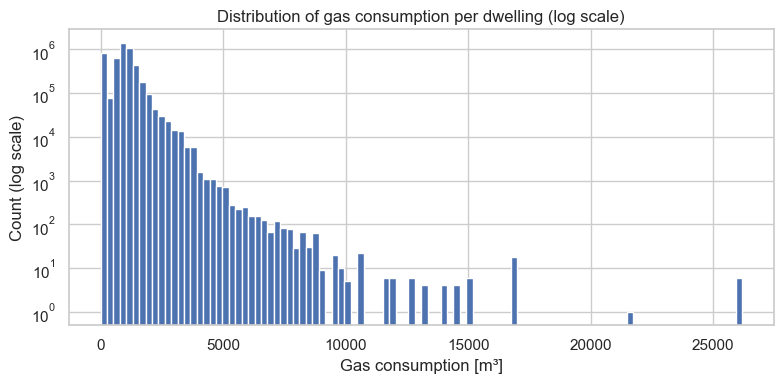

In [15]:
# ----------------------------
# 4.3A Gas connection diagnostics
# ----------------------------

# Step 1: Inspect overall distribution of gas connections
print("=== gas_ean_count distribution ===")
vc_gas = df_dwelling["gas_ean_count"].value_counts().sort_index()
display(vc_gas)

print("\nNumber of unique gas_ean_count values:", df_dwelling["gas_ean_count"].nunique())

# Step 2: Check variation within PC6 areas
pc6_variation = df_dwelling.groupby("postcode")["gas_ean_count"].nunique()

print("\nShare of PC6s with more than one unique gas_ean_count value:")
print((pc6_variation > 1).mean())

print("\nDistribution of unique gas_ean_count values per PC6:")
display(pc6_variation.value_counts().sort_index())

# Step 3: Examine gas consumption when gas_ean_count = 0
gas_zero_stats = df_dwelling.loc[
    df_dwelling["gas_ean_count"] == 0,
    "p6_gasm3_2023"
].describe()

print("\nGas consumption statistics for dwellings with gas_ean_count = 0:")
display(gas_zero_stats)

# Step 4: Inspect dwellings with gas_ean_count = 0 but positive gas consumption
inconsistent = (
    (df_dwelling["gas_ean_count"] == 0) &
    (df_dwelling["p6_gasm3_2023"] > 0)
)

print("\nShare of dwellings with gas_ean_count = 0 but positive gas consumption:")
print(inconsistent.mean())

# Step 5: Plot histogram of gas consumption to explore possible separation of heating vs cooking/hot water
plt.figure(figsize=(8, 4))
plt.hist(df_dwelling["p6_gasm3_2023"].dropna(), bins=100, log=True)
plt.title("Distribution of gas consumption per dwelling (log scale)")
plt.xlabel("Gas consumption [m³]")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

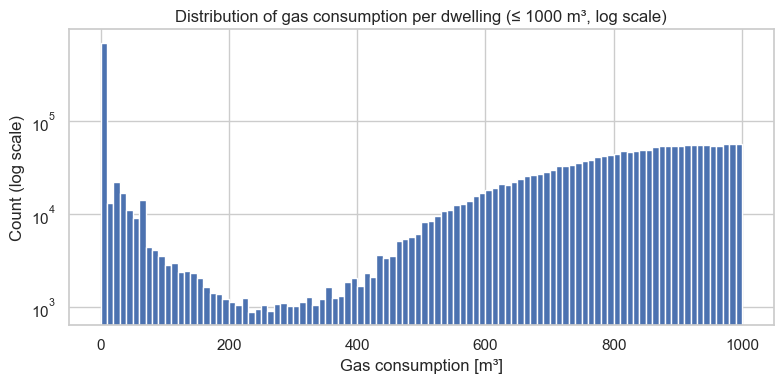

In [16]:
# Step 5: Plot histogram of gas consumption (clipped at 1000 m³ for readability)

gas_plot = df_dwelling["p6_gasm3_2023"].dropna()

# keep only values up to 1000 for visualization
gas_plot = gas_plot[gas_plot <= 1000]

plt.figure(figsize=(8, 4))
plt.hist(gas_plot, bins=100, log=True)
plt.title("Distribution of gas consumption per dwelling (≤ 1000 m³, log scale)")
plt.xlabel("Gas consumption [m³]")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

#### Final gas connection variable consideration

The diagnostic analysis confirms that `gas_ean_count` is concentrated at values **0 and 1**, with only a tiny fraction of dwellings having multiple gas connections. Most dwellings either have no gas or a single gas connection.

Inspection of gas consumption (`p6_gasm3_2023`) shows that dwellings with `gas_ean_count = 0` consistently consume **zero gas**, with no exceptions. This indicates that zero counts accurately represent the **absence of a gas connection**.

Variation of `gas_ean_count` within PC6 areas exists but is limited: most PC6s are homogeneous, and only ~21% have more than one unique value.  

Because the histogram of gas consumption does not reveal clear modes separating cooking/hot water from heating demand, creating a separate `gas_heated` variable from the current data would be **arbitrary and potentially misleading**.  

**Conclusion:** For now, the structural information about gas availability is best captured using a **binary indicator**:

- **`has_gas = True`** if `gas_ean_count > 0`  
- **`has_gas = False`** if `gas_ean_count = 0`

This variable reliably reflects the presence of gas in the dwelling without introducing assumptions about heating versus non-heating gas usage.

In [17]:
# ----------------------------
# create binary gas connection indicator
# ----------------------------

df_dwelling["has_gas"] = df_dwelling["gas_ean_count"].fillna(0) > 0

print("share of dwellings with gas connection (has_gas=True):")
print(round(df_dwelling["has_gas"].mean(), 4))

share of dwellings with gas connection (has_gas=True):
0.8603


#### 4.3B Rare housing type categories (`woning_type`)

Very rare housing categories may create unstable estimates in later modelling stages.  
When PC6 compositions are computed, categories with extremely small sample sizes can produce noisy or unreliable shares.

To diagnose this, we first examine the structural characteristics and sample size of each housing type.

The objective of this step is to:

- understand structural differences between housing types
- detect extremely rare categories
- determine whether any categories should be removed from the modelling dataset

In [18]:
# ----------------------------
# 4.3B woning_type structural comparison
# ----------------------------

type_structure = (
    df_dwelling
    .groupby("woning_type")[["oppervlakte", "pand_bouwjaar"]]
    .agg(["mean", "median", "count"])
)

display(type_structure)

oppervlakte                 \
                                                   mean median   count   
woning_type                                                              
Appartement                                   73.975433   73.0  349408   
Flatwoning (overig)                           73.921175   72.0  596385   
Galerijwoning                                 68.687315   70.0   27766   
Logieswoning                                 104.896907   93.0      97   
Maisonnette                                   88.835303   86.0   86917   
Portiekwoning                                 68.922706   68.0    9742   
Rijwoning hoek                               111.574327  107.0  131385   
Rijwoning tussen                             110.026657  108.0  955361   
Twee-onder-een-kap / rijwoning hoek          128.817983  124.0  583731   
Twee-onder-één-kap                           138.627003  137.0   62770   
Vrijstaande woning                           192.025511  180.0  232606   
Woongebouw met niet-zelfstandige woonruimte   64.753012   33.0     166   
Woonwagen                                    101.454545   79.0      11   

                                            pand_bouwjaar                  
                                                     mean  median   count  
woning_type                                                                
Appartement                                   1969.930743  1974.0  349408  
Flatwoning (overig)                           1975.118787  1975.0  596385  
Galerijwoning                                 1981.333790  1976.0   27766  
Logieswoning                                  1850.072165  1975.0      97  
Maisonnette                                   1967.642694  1977.0   86917  
Portiekwoning                                 1964.512626  1962.0    9742  
Rijwoning hoek                                1970.210709  1975.0  131385  
Rijwoning tussen                              1976.355324  1978.0  955361  
Twee-onder-een-kap / rijwoning hoek           1979.765558  1981.0  583731  
Twee-onder-één-kap                            1971.997101  1980.0   62770  
Vrijstaande woning                            1978.132692  1988.0  232606  
Woongebouw met niet-zelfstandige woonruimte   1969.391566  1986.0     166  
Woonwagen                                     1807.727273  1987.0      11

To further examine structural similarities between housing types, we compute a standardized structural profile and visualize it using hierarchical clustering.

This diagnostic helps identify which housing types share similar structural characteristics such as:

- floor area
- construction year
- gas connection presence

The clustering is used only as an exploratory diagnostic and not as the sole basis for modelling decisions.

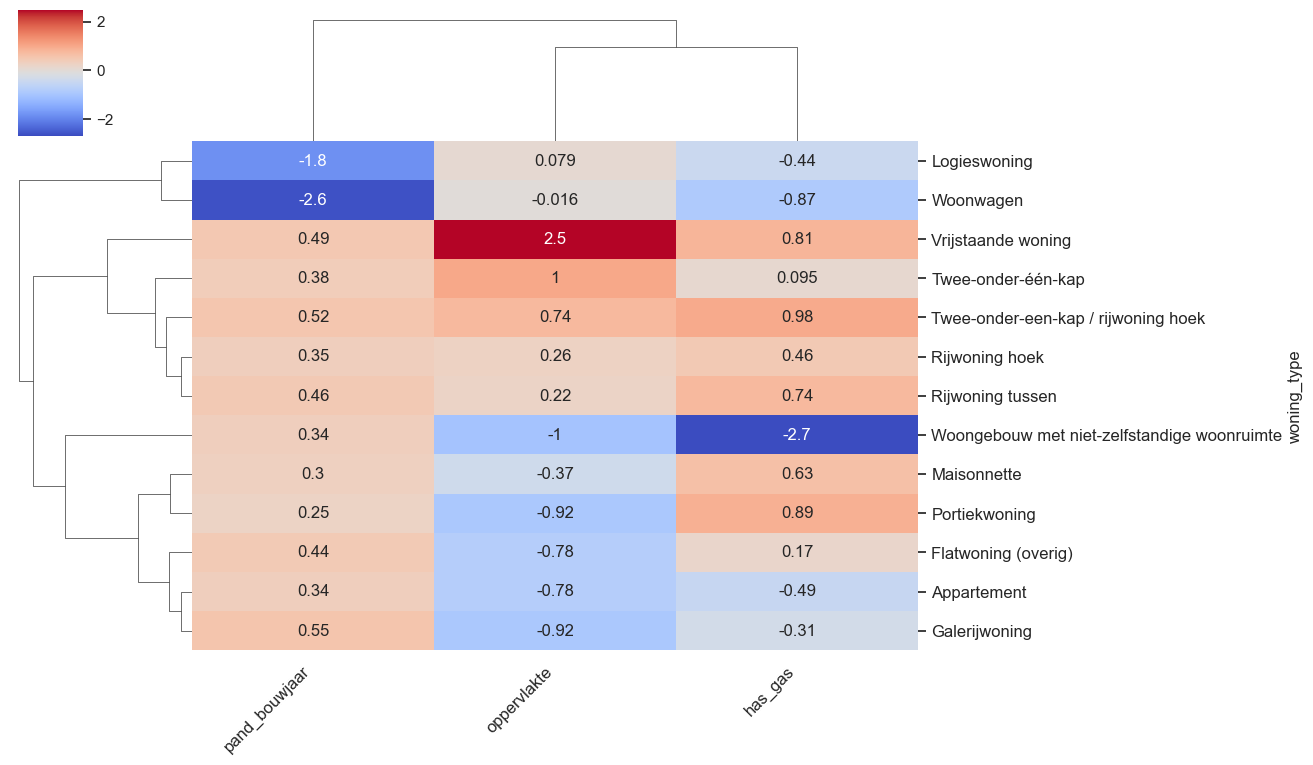

In [19]:
# ----------------------------
# Structural profile per woning_type
# ----------------------------

cols = ["oppervlakte", "pand_bouwjaar", "has_gas"]

# ensure numeric types
for c in ["oppervlakte", "pand_bouwjaar"]:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")


# compute mean structural profile
profile = df_dwelling.groupby("woning_type")[cols].mean()

# standardize variables
profile_scaled = (profile - profile.mean()) / profile.std()

# clustered heatmap
g = sns.clustermap(
    profile_scaled,
    cmap="coolwarm",
    metric="euclidean",
    method="ward",
    figsize=(13,7),
    annot=True
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=12)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12)

plt.show()

In [20]:
# ----------------------------
# Diagnostic: PC6 affected by rare housing types
# ----------------------------

rare_types = [
    "Logieswoning",
    "Woongebouw met niet-zelfstandige woonruimte",
    "Woonwagen"
]

# PC6 that contain at least one rare type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["woning_type"].isin(rare_types),
    "postcode"
].unique()

n_pc6_with_rare = len(pc6_with_rare)
total_pc6 = df_dwelling["postcode"].nunique()

print("PC6 containing rare dwelling types:", n_pc6_with_rare)
print("Total PC6:", total_pc6)
print("Share of PC6 affected:", round(n_pc6_with_rare / total_pc6, 4))


# ----------------------------
# How many dwellings would be removed?
# ----------------------------

rows_in_pc6_with_rare = df_dwelling["postcode"].isin(pc6_with_rare).sum()
total_rows = len(df_dwelling)

print("\nDwellings located in those PC6:", rows_in_pc6_with_rare)
print("Total dwellings:", total_rows)
print("Share of dwellings affected:", round(rows_in_pc6_with_rare / total_rows, 4))


# ----------------------------
# How many rare dwellings themselves?
# ----------------------------

rare_rows = df_dwelling["woning_type"].isin(rare_types).sum()

print("\nRare dwelling rows only:", rare_rows)
print("Share of rare dwellings:", round(rare_rows / total_rows, 6))

PC6 containing rare dwelling types: 116
Total PC6: 258679
Share of PC6 affected: 0.0004

Dwellings located in those PC6: 2705
Total dwellings: 4820210
Share of dwellings affected: 0.0006

Rare dwelling rows only: 274
Share of rare dwellings: 5.7e-05


#### Final modelling decision

The structural comparison and clustering diagnostics reveal that three housing types are extremely rare within the national dataset:

- **Logieswoning**
- **Woongebouw met niet-zelfstandige woonruimte**
- **Woonwagen**

These categories together represent a negligible share of the housing stock and occur in only a very small number of postcode areas.

Because the energy variables in the dataset are defined at **PC6 level**, removing only the individual dwelling rows would create an inconsistency between the structural composition of a PC6 and its associated energy totals.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing these rare dwelling types are removed from the modelling dataset**.

This exclusion affects only a very small fraction of the dataset and therefore does not materially alter the representation of the Dutch residential housing stock.

The analysis proceeds with the remaining PC6 areas, which represent virtually the entire residential building stock.

In [21]:
# ----------------------------
# remove PC6 areas containing extremely rare housing types
# ----------------------------

# identify PC6 that contain any rare dwelling type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["woning_type"].isin(rare_types),
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_rare)
].copy()

print("Remaining PC6:", df_dwelling["postcode"].nunique())
print("Remaining dwellings:", len(df_dwelling))

print("\nRemaining housing types:")
print(df_dwelling["woning_type"].value_counts())

Remaining PC6: 258563
Remaining dwellings: 4817505

Remaining housing types:
woning_type
Rijwoning tussen                       955165
Flatwoning (overig)                    596069
Twee-onder-een-kap / rijwoning hoek    583623
Appartement                            349090
Vrijstaande woning                     232362
Rijwoning hoek                         131356
Maisonnette                             86898
Twee-onder-één-kap                      62750
Galerijwoning                           27748
Portiekwoning                            9726
Name: count, dtype: int64


#### 4.3C Floor area tail diagnostics and threshold decision (`oppervlakte`)

The floor area distribution contains extreme values that strongly distort scale.
We treat percentiles as diagnostic evidence, and we choose thresholds using a hybrid approach:

- Percentiles to understand where the bulk of the housing stock lies
- Direct inspection to detect sentinel or implausible magnitudes
- Candidate threshold testing to quantify how much data is affected

Based on the diagnostics in Sections 4.3C1–4.3C6, floor area limits were defined to remove implausible observations while preserving realistic housing variability.

In [22]:
# 4.3C1 inspect upper tail values directly (structural plausibility check)

# ---extremely large values (>2000 m²)
extreme_threshold = 2000

extreme_values = (
    df_dwelling[df_dwelling["oppervlakte"] > extreme_threshold]["oppervlakte"]
    .value_counts()
    .head(20)
)

print(f"most frequent floor area values above {extreme_threshold} m²:")
display(extreme_values)


# ---large but potentially plausible band (1000–2000 m²)
large_band = (
    df_dwelling[
        (df_dwelling["oppervlakte"] > 1000) &
        (df_dwelling["oppervlakte"] <= 2000)
    ]["oppervlakte"]
    .value_counts()
    .head(20)
)

print("most frequent floor area values between 1000 and 2000 m²:")
display(large_band)


# --- diagnostic summary
n_above_1000 = (df_dwelling["oppervlakte"] > 1000).sum()
share_above_1000 = 100 * n_above_1000 / len(df_dwelling)

print(f"total dwellings above 1000 m²: {n_above_1000}")
print(f"share of dataset above 1000 m²: {share_above_1000:.6f}%")

most frequent floor area values above 2000 m²:


oppervlakte
999999.0    5
2003.0      3
99999.0     2
9999.0      2
2993.0      2
6745.0      2
13388.0     2
110171.0    2
2835.0      2
2487.0      1
21867.0     1
6214.0      1
7440.0      1
2202.0      1
117615.0    1
9288.0      1
3298.0      1
2163.0      1
4920.0      1
4518.0      1
Name: count, dtype: int64

most frequent floor area values between 1000 and 2000 m²:


oppervlakte
1092.0    5
1021.0    3
1009.0    3
1172.0    3
1019.0    3
1135.0    3
1128.0    3
1111.0    3
1039.0    3
1158.0    3
1072.0    3
1081.0    3
1935.0    3
1031.0    2
1105.0    2
1051.0    2
1010.0    2
1195.0    2
1107.0    2
1138.0    2
Name: count, dtype: int64

total dwellings above 1000 m²: 456
share of dataset above 1000 m²: 0.009465%


In [23]:
# 4.3C2 candidate upper limits and removal shares

candidate_upper_limits = [800, 1000, 1500, 2000]

print("removal share for candidate upper limits:")
for limit in candidate_upper_limits:
    removed_share = (df_dwelling["oppervlakte"] > limit).mean() * 100
    print(f"upper limit {limit} m² → {removed_share:.5f}% removed")

removal share for candidate upper limits:
upper limit 800 m² → 0.01800% removed
upper limit 1000 m² → 0.00947% removed
upper limit 1500 m² → 0.00326% removed
upper limit 2000 m² → 0.00189% removed


In [24]:
# 4.3C3 inspect lower tail values directly (structural plausibility check)

# ---extremely small values (<10 m²)
extreme_lower_threshold = 10

extreme_lower_values = (
    df_dwelling[df_dwelling["oppervlakte"] < extreme_lower_threshold]["oppervlakte"]
    .value_counts()
)

print(f"most frequent floor area values below {extreme_lower_threshold} m²:")
display(extreme_lower_values)


# ---small but potentially plausible band (10–20 m²)
small_band = (
    df_dwelling[
        (df_dwelling["oppervlakte"] >= 10) &
        (df_dwelling["oppervlakte"] < 20)
    ]["oppervlakte"]
    .value_counts()
)

print("most frequent floor area values between 10 and 20 m²:")
display(small_band)


# --- diagnostic summary
n_below_10 = (df_dwelling["oppervlakte"] < 10).sum()
share_below_10 = 100 * n_below_10 / len(df_dwelling)

print(f"total dwellings below 10 m²: {n_below_10}")
print(f"share of dataset below 10 m²: {share_below_10:.6f}%")

most frequent floor area values below 10 m²:


oppervlakte
1.0    151
5.0      3
8.0      2
9.0      2
2.0      1
7.0      1
Name: count, dtype: int64

most frequent floor area values between 10 and 20 m²:


oppervlakte
19.0    729
18.0    673
15.0    314
17.0    307
16.0    139
14.0     50
11.0     46
13.0     45
12.0     32
10.0     26
Name: count, dtype: int64

total dwellings below 10 m²: 160
share of dataset below 10 m²: 0.003321%


In [25]:
# 4.3C4 candidate lower limits and removal shares

candidate_lower_limits = [5, 10, 15, 20]

print("removal share for candidate lower limits:")
for limit in candidate_lower_limits:
    removed_share = (df_dwelling["oppervlakte"] < limit).mean() * 100
    print(f"lower limit {limit} m² → {removed_share:.6f}% removed")

removal share for candidate lower limits:
lower limit 5 m² → 0.003155% removed
lower limit 10 m² → 0.003321% removed
lower limit 15 m² → 0.007452% removed
lower limit 20 m² → 0.052330% removed


In [26]:
# ----------------------------
# 4.3C5 diagnostic: effect of removing whole PC6 vs only outlier rows
# ----------------------------

lower_limit = 10
upper_limit = 1000

# dwellings outside the accepted floor area range
area_outlier_mask = (
    (df_dwelling["oppervlakte"] < lower_limit) |
    (df_dwelling["oppervlakte"] > upper_limit)
)

# PC6 containing at least one floor-area outlier
pc6_with_area_outliers = df_dwelling.loc[area_outlier_mask, "postcode"].unique()

n_pc6_total = df_dwelling["postcode"].nunique()
n_rows_total = len(df_dwelling)

n_outlier_rows = area_outlier_mask.sum()
share_outlier_rows = n_outlier_rows / n_rows_total

n_pc6_with_outliers = len(pc6_with_area_outliers)
share_pc6_with_outliers = n_pc6_with_outliers / n_pc6_total

rows_in_affected_pc6 = df_dwelling["postcode"].isin(pc6_with_area_outliers).sum()
share_rows_in_affected_pc6 = rows_in_affected_pc6 / n_rows_total

print("=== Floor area outlier diagnostic ===")
print(f"Outlier dwellings only: {n_outlier_rows}")
print(f"Share of outlier dwellings: {share_outlier_rows:.6%}")

print(f"\nPC6 containing at least one area outlier: {n_pc6_with_outliers}")
print(f"Share of PC6 affected: {share_pc6_with_outliers:.6%}")

print(f"\nDwellings located in those affected PC6: {rows_in_affected_pc6}")
print(f"Share of dwellings affected if whole PC6 were removed: {share_rows_in_affected_pc6:.6%}")

=== Floor area outlier diagnostic ===
Outlier dwellings only: 616
Share of outlier dwellings: 0.012787%

PC6 containing at least one area outlier: 518
Share of PC6 affected: 0.200338%

Dwellings located in those affected PC6: 11362
Share of dwellings affected if whole PC6 were removed: 0.235848%


#### Final floor area threshold decision

Based on percentile diagnostics, direct inspection of extreme values, and evaluation of candidate thresholds, floor area limits were defined to identify implausible dwelling records while preserving realistic housing variability.

Inspection of the upper tail revealed rare sentinel-like values (e.g., 99,999 m² and 999,999 m²) and highly implausible dwelling sizes above 2000 m². Additional analysis showed that values between 1000–2000 m² were extremely sparse and did not represent a meaningful segment of the housing stock.

Lower-tail inspection identified a small number of dwellings with floor areas below 10 m², which are physically implausible for residential units and likely represent data artifacts or misclassified structures.

Because the energy variables in the dataset are defined at **PC6 level**, removing only the individual outlier dwellings would create an inconsistency between the structural composition of a PC6 and its associated energy totals.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing dwellings outside the accepted floor area range** are removed from the modelling dataset.

The adopted structural limits are:

- **Lower limit:** 10 m²  
- **Upper limit:** 1000 m²  

This exclusion affects only a very small share of the dataset and ensures that the remaining PC6 areas have structurally consistent housing composition and energy totals.

In [27]:
# 4.3C6 final structural thresholds (PC6-consistent filtering)

lower_limit = 10
upper_limit = 1000

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one floor-area outlier
area_outlier_mask = (
    (df_dwelling["oppervlakte"] < lower_limit) |
    (df_dwelling["oppervlakte"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[
    area_outlier_mask, "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_area_outliers)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent floor area filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent floor area filtering
remaining PC6: 258045
remaining rows: 4806143

PC6 removed: 518
dwellings removed: 11362

share of PC6 removed: 0.20034%
share of dwellings removed: 0.23585%


#### 4.3D Construction year diagnostics and threshold decision (`pand_bouwjaar`)

Construction year is retained during minimal cleaning so that lower-tail values can be diagnosed before applying a structural threshold.

We inspect the lower tail of `pand_bouwjaar` to identify clearly implausible or administrative values and then apply a final lower bound supported by the observed distribution.

In [28]:
# 4.3D1 construction year diagnostics

print("minimum bouwjaar:", df_dwelling["pand_bouwjaar"].min())
print(df_dwelling["pand_bouwjaar"].describe(percentiles=[0.001, 0.01, 0.05]))

print("most frequent bouwjaar values below 1700:")
display(
    df_dwelling.loc[df_dwelling["pand_bouwjaar"] < 1700, "pand_bouwjaar"]
    .value_counts()
    .head(20)
)

print("Construction year values between 1 and 999:")

display(
    df_dwelling.loc[
        (df_dwelling["pand_bouwjaar"] >= 1) &
        (df_dwelling["pand_bouwjaar"] < 1000),
        "pand_bouwjaar"
    ]
    .value_counts()
    .sort_index()
)

minimum bouwjaar: 0
count    4.806143e+06
mean     1.966671e+03
std      1.376194e+02
min      0.000000e+00
0.1%     0.000000e+00
1%       1.889000e+03
5%       1.922000e+03
max      2.024000e+03
Name: pand_bouwjaar, dtype: float64
most frequent bouwjaar values below 1700:


pand_bouwjaar
0       22421
1650      296
1600      116
1450       84
1681       76
1660       69
1625       59
1592       51
1680       39
1675       37
1666       36
1690       30
1670       29
1005       29
1350       28
1683       24
1659       24
1671       24
1616       22
1685       21
Name: count, dtype: int64

Construction year values between 1 and 999:


Series([], Name: count, dtype: int64)

#### Final construction year threshold decision

Inspection of the lower tail revealed a concentration of entries with a construction year equal to **0**, which represent administrative placeholders rather than valid construction dates. These records do not correspond to real building years and therefore cannot be interpreted meaningfully in structural analysis.

To address this issue while preserving the historical housing stock, only observations with **`pand_bouwjaar = 0`** are removed. All other registry construction years are retained, including very early historical values, as they represent valid entries in the national building registry and do not distort the statistical distribution of the dataset.

In [29]:
# 4.3D2 final construction year threshold

n_before = len(df_dwelling)

# lower construction year limit
# set to 1 to only remove the administrative artifact (year = 0)
year_lower_limit = 1

df_dwelling = df_dwelling[
    df_dwelling["pand_bouwjaar"] >= year_lower_limit
].copy()

n_after = len(df_dwelling)

print("after construction year filtering")
print("rows:", n_after)
print(f"share removed by bouwjaar filtering: {(1 - n_after / n_before) * 100:.5f}%")

after construction year filtering
rows: 4783722
share removed by bouwjaar filtering: 0.46651%


### 4.4 Correlation analysis between dwelling features

This section quantifies statistical relationships between dwelling characteristics, building directly on the previous steps:

- **4.1 Descriptive statistics** confirmed that each feature has meaningful variation.
- **4.2 Distribution visualization** revealed skewness, heavy tails, and category imbalance.
- **4.3 Structural diagnostics** handled artifacts (especially in `oppervlakte`) and clarified how variables behave. In particular, the gas connection variable was shown to behave largely as a binary structural characteristic, so the derived indicator `has_gas` is used in the correlation analysis that follows.

Because the dataset includes mixed variable types, no single classical association coefficient is appropriate for all variable pairs. Therefore, associations are evaluated using measures matched to variable type:

- **Spearman correlation** for numeric-numeric relationships
- **Cramér’s V** for categorical-categorical relationships
- **Correlation ratio (η)** for categorical-numeric relationships

After evaluating each pair type separately, a **mixed-type association matrix** is constructed to provide a unified overview of all relationships between dwelling features.

Finally, a **Variance Inflation Factor (VIF)** diagnostic is performed to detect multicollinearity within the predictor set used later in regression modelling.

#### 4.4A Prepare analysis variables

The association analysis uses a set of structural dwelling variables describing building characteristics and energy-related attributes.

Numeric variables:
• `oppervlakte` – dwelling floor area  
• `pand_bouwjaar` – construction year  

Categorical variables:
• `energieklasse` – energy performance label  
• `woning_type` – dwelling type  
• `has_gas` – indicator of gas connection presence  

Energy labels are treated as **categorical variables**, including the category `no_label`, which represents dwellings without a registered energy label.

The variable `has_gas` is derived from `gas_ean_count` and used as a binary structural indicator.

In [30]:
# ----------------------------
# 4.4A Prepare analysis variables
# ----------------------------

# numeric features used in association analysis
num_cols = ["oppervlakte", "pand_bouwjaar"]

# categorical features used in association analysis
cat_cols = ["energieklasse", "woning_type", "has_gas"]

# ensure has_gas exists
if "has_gas" not in df_dwelling.columns:
    df_dwelling["has_gas"] = df_dwelling["gas_ean_count"].fillna(0) > 0

# ensure energieklasse remains an explicit categorical variable
label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energieklasse"] = pd.Categorical(
    df_dwelling["energieklasse"],
    categories=label_order,
    ordered=False
)

# quick sanity checks
print("sanity checks")
print("rows:", len(df_dwelling))
print("unique pc6:", df_dwelling["postcode"].nunique())
print("share has_gas = true:", round(df_dwelling["has_gas"].mean(), 4))
print("share energieklasse == 'no_label':",
      round((df_dwelling["energieklasse"] == "no_label").mean(), 4))
print("\nenergieklasse counts:")
display(df_dwelling["energieklasse"].value_counts(dropna=False).sort_index())

sanity checks
rows: 4783722
unique pc6: 257669
share has_gas = true: 0.8649
share energieklasse == 'no_label': 0.3681

energieklasse counts:


energieklasse
A++++         17588
A+++          49387
A++           26667
A+            52588
A            922046
B            524431
C            789993
D            298436
E            170670
F             94603
G             76435
no_label    1760878
Name: count, dtype: int64

#### 4.4B Numeric structural correlations

Relationships between numeric dwelling characteristics are evaluated using **Spearman rank correlation**.

Spearman correlation is chosen because several variables exhibit skewed distributions and potential outliers, making a rank-based measure more robust than Pearson correlation.

The analysis focuses on:

• `oppervlakte` – dwelling floor area  
• `pand_bouwjaar` – construction year

The resulting matrix summarizes the strength and direction of monotonic relationships between these structural variables.

,oppervlakte,pand_bouwjaar
oppervlakte,1.000000,0.235873
pand_bouwjaar,0.235873,1.000000


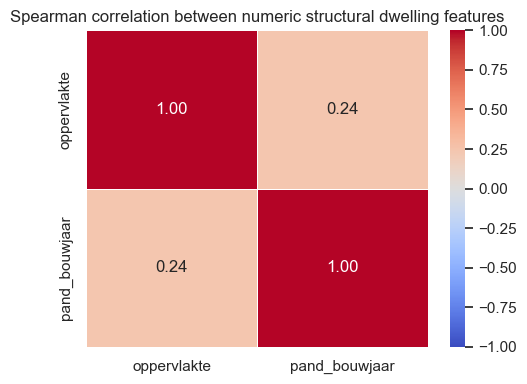

In [31]:
# ----------------------------
# 4.4B Spearman correlation matrix
# ----------------------------

spearman_cols = [
    "oppervlakte",
    "pand_bouwjaar"
]

corr_spearman = df_dwelling[spearman_cols].corr(method="spearman")

display(corr_spearman)

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Spearman correlation between numeric structural dwelling features")
plt.tight_layout()
plt.show()

#### 4.4C Categorical–categorical associations (Cramér’s V)

Associations between categorical dwelling characteristics are measured using **Cramér’s V**, which is based on the chi-squared statistic and provides a normalized measure of association between categorical variables.

The categorical variables considered are:

• `energieklasse` – energy performance label  
• `woning_type` – dwelling type  
• `has_gas` – gas connection indicator

Cramér’s V ranges from **0 (no association)** to **1 (perfect association)**.

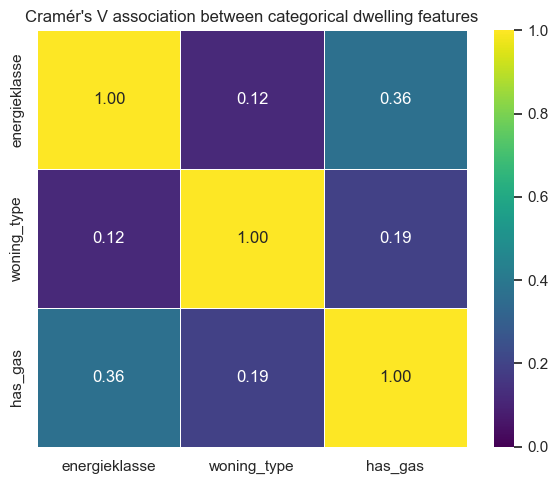

In [32]:
# ----------------------------
# 4.4C Cramér's V association matrix
# ----------------------------

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Compute Cramér's V statistic for categorical-categorical association.
    """
    contingency_table = pd.crosstab(x, y)

    if contingency_table.size == 0:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    denom = min(r - 1, k - 1)

    if denom <= 0 or n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / denom)


# categorical variables to analyze
cat_for_v = ["energieklasse", "woning_type", "has_gas"]

# create empty matrix
V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)

# compute pairwise Cramér's V
for i in cat_for_v:
    for j in cat_for_v:
        if i == j:
            V.loc[i, j] = 1.0
        else:
            V.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

# ----------------------------
# Cramér's V heatmap
# ----------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    V,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Cramér's V association between categorical dwelling features")
plt.tight_layout()
plt.show()

#### 4.4D Categorical–numeric associations (correlation ratio η)

Relationships between categorical variables and numeric variables are evaluated using the **correlation ratio (η)**.

The correlation ratio measures how strongly the distribution of a numeric variable differs across categories of a categorical variable.

In this analysis, it is used to evaluate how variables such as dwelling type, energy label, or gas connection presence relate to numeric structural characteristics like floor area or construction year.

The statistic ranges from **0 (no association)** to **1 (perfect association)**.

,oppervlakte,pand_bouwjaar
woning_type,0.690216,0.092794
energieklasse,0.216555,0.468057
has_gas,0.067754,0.244161


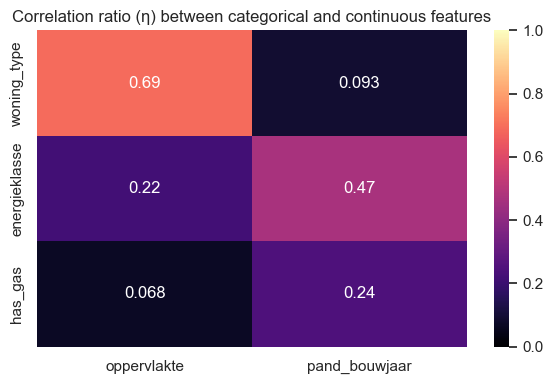

In [33]:
# ----------------------------
# 4.4D Correlation ratio (η)
# ----------------------------

def correlation_ratio(categories, measurements):
    """
    Compute correlation ratio (η) for categorical → continuous association.
    """
    valid = pd.notna(categories) & pd.notna(measurements)
    categories = pd.Series(categories)[valid]
    measurements = pd.Series(measurements)[valid].astype(float)

    if len(measurements) == 0:
        return np.nan

    codes, uniques = pd.factorize(categories)
    cat_num = len(uniques)

    if cat_num <= 1:
        return np.nan

    y_avg = np.zeros(cat_num)
    n = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[codes == i]
        n[i] = len(cat_measures)
        if len(cat_measures) > 0:
            y_avg[i] = np.mean(cat_measures)

    y_total = np.sum(y_avg * n) / np.sum(n)

    numerator = np.sum(n * (y_avg - y_total) ** 2)
    denominator = np.sum((measurements - y_total) ** 2)

    if denominator == 0:
        return np.nan

    return np.sqrt(numerator / denominator)


cont_vars = ["oppervlakte", "pand_bouwjaar"]
cat_vars = ["woning_type", "energieklasse", "has_gas"]

eta_matrix = pd.DataFrame(index=cat_vars, columns=cont_vars)

for cat in cat_vars:
    for cont in cont_vars:
        eta_matrix.loc[cat, cont] = correlation_ratio(
            df_dwelling[cat],
            df_dwelling[cont]
        )

eta_matrix = eta_matrix.astype(float)

display(eta_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(eta_matrix, annot=True, cmap="magma", vmin=0, vmax=1)
plt.title("Correlation ratio (η) between categorical and continuous features")
plt.tight_layout()
plt.show()

#### 4.4E Mixed association matrix

To provide a consolidated overview of dependencies between all dwelling characteristics, a mixed-type association matrix is constructed.

Different association measures are applied depending on the variable pair:

• Spearman correlation for numeric–numeric pairs  
• Cramér’s V for categorical–categorical pairs  
• Correlation ratio (η) for categorical–numeric pairs  

Because different statistics are used for different variable combinations, the resulting matrix does **not represent a single unified correlation coefficient** but rather a collection of appropriate association measures.

The matrix therefore serves as an exploratory diagnostic tool to identify potentially strong dependencies between structural dwelling variables.

,oppervlakte,pand_bouwjaar,energieklasse,woning_type,has_gas
oppervlakte,1.000000,0.235873,0.216555,0.690216,0.067754
pand_bouwjaar,0.235873,1.000000,0.468057,0.092794,0.244161
energieklasse,0.216555,0.468057,1.000000,0.115442,0.363538
woning_type,0.690216,0.092794,0.115442,1.000000,0.194012
has_gas,0.067754,0.244161,0.363538,0.194012,1.000000


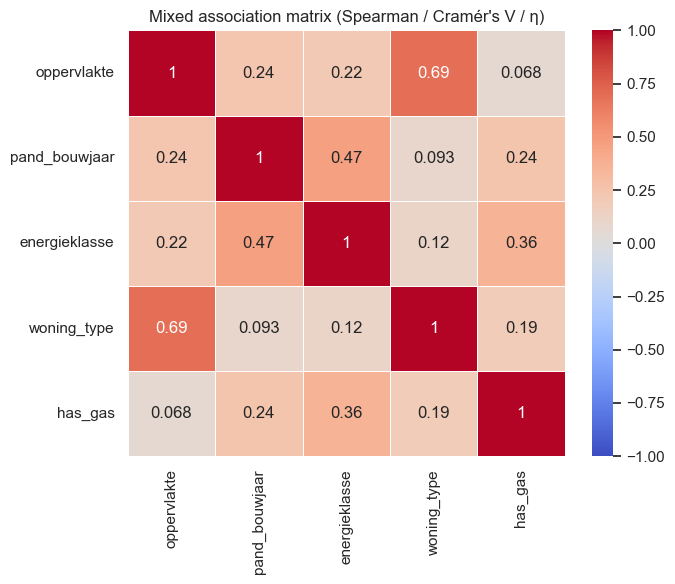

In [34]:
# ----------------------------
# 4.4E Mixed association matrix
# ----------------------------

num_vars = ["oppervlakte", "pand_bouwjaar"]
cat_vars = ["energieklasse", "woning_type", "has_gas"]

all_vars = num_vars + cat_vars

mixed_matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for i in all_vars:
    for j in all_vars:

        if i == j:
            mixed_matrix.loc[i, j] = 1.0

        # numeric-numeric → Spearman
        elif i in num_vars and j in num_vars:
            mixed_matrix.loc[i, j] = df_dwelling[[i, j]].corr(method="spearman").iloc[0, 1]

        # categorical-categorical → Cramér's V
        elif i in cat_vars and j in cat_vars:
            mixed_matrix.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

        # mixed → correlation ratio (η)
        else:
            cat_var = i if i in cat_vars else j
            cont_var = j if i in cat_vars else i
            mixed_matrix.loc[i, j] = correlation_ratio(
                df_dwelling[cat_var],
                df_dwelling[cont_var]
            )

display(mixed_matrix)

plt.figure(figsize=(7, 6))
sns.heatmap(
    mixed_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Mixed association matrix (Spearman / Cramér's V / η)")
plt.tight_layout()
plt.show()

#### 4.4F Multicollinearity diagnostic


After examining pairwise associations and the unified mixed-type association matrix, we perform a **multicollinearity diagnostic** using the **Variance Inflation Factor (VIF)**.

While correlation matrices reveal pairwise relationships, multicollinearity occurs when one predictor can be explained by a combination of other predictors. VIF quantifies how much the variance of a regression coefficient is inflated due to such dependencies.

The VIF for a variable is defined as:

VIF = 1 / (1 − R²)

where R² is obtained when regressing the variable against all other predictors.

For this diagnostic, we construct a predictor set consisting of:

- `oppervlakte`
- `pand_bouwjaar`
- `has_gas`

These variables correspond to the structural features intended for later regression modelling.

In [35]:
# ----------------------------
# 4.4F Multicollinearity check (VIF)
# ----------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# keep this diagnostic limited to currently numeric / binary predictors
# energieklasse will be added later through dummy variables in regression
vif_vars = [
    "oppervlakte",
    "pand_bouwjaar",
    "has_gas"
]

X = df_dwelling[vif_vars].copy()
X["has_gas"] = X["has_gas"].astype(int)

X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_data)

,variable,VIF
0,const,5277.564512
1,pand_bouwjaar,1.089509
2,has_gas,1.075100
3,oppervlakte,1.029283


### Interpretation of structural correlations

The mixed-type association matrix provides an overview of the relationships between the main structural dwelling characteristics in the dataset. Overall, the results indicate that the selected variables capture related but largely distinct aspects of the housing stock.

The strongest association is observed between **dwelling floor area (`oppervlakte`) and dwelling type (`woning_type`)** (0.50). This reflects a clear structural relationship in the housing stock, where certain dwelling types (e.g., detached or semi-detached houses) tend to have systematically larger floor areas than others such as apartments.

A **moderate association between construction year (`pand_bouwjaar`) and energy label (`energieklasse`)** (0.47) is also observed. This relationship is expected, as newer buildings generally comply with more recent building codes and energy efficiency standards, resulting in better energy performance labels.

The presence of a **gas connection (`has_gas`) shows moderate association with energy label (0.36)** and weaker associations with construction year (0.25) and dwelling type (0.20). These patterns reflect structural transitions in heating technologies and building efficiency across the housing stock, where more efficient dwellings are somewhat less likely to rely on gas heating.

Other relationships remain relatively weak. For example, the association between floor area and construction year (0.23) and between floor area and energy label (0.21) suggests that dwelling size is only moderately related to building vintage or energy efficiency.

Overall, the correlation structure indicates that while some structural relationships exist—particularly between dwelling type and floor area, and between building age and energy performance—the predictor variables largely represent different structural dimensions of the housing stock.

The multicollinearity diagnostic confirms this interpretation. All predictor variables exhibit **very low Variance Inflation Factor (VIF) values (≈1.06–1.17)**, which indicates that no strong multicollinearity is present among the explanatory variables. Consequently, the selected structural predictors can be used jointly in subsequent regression modelling without introducing instability in coefficient estimation.

#### 4.4G Association between structural dwelling characteristics and PC6 average per-dwelling energy values

To explore how dwelling characteristics relate to energy outcomes at postcode level, we compute a mixed-type association matrix between structural variables and PC6-level energy variables.

The structural variables considered are:

- `oppervlakte` — dwelling floor area  
- `pand_bouwjaar` — construction year  
- `energieklasse` — dwelling energy performance label  
- `woning_type` — dwelling type classification  
- `has_gas` — binary indicator of gas connection presence  

These variables are compared against the PC6 average per-dwelling energy values:

- `p6_kwh_2023` — annual electricity consumption  
- `p6_gasm3_2023` — annual gas consumption  
- `p6_kwh_productie_2023` — annual electricity production  

Because the variables include both continuous and categorical types, the association measure depends on the variable pair:

- **Spearman correlation** is used for continuous–continuous relationships.
- **Correlation ratio (η)** is used for categorical–continuous relationships.

It is important to note that the energy variables are reported at **PC6 level**, meaning that all dwellings within the same postcode share identical energy values. The resulting associations should therefore be interpreted as **exploratory relationships between dwelling characteristics and area-level energy outcomes**, rather than strictly dwelling-level causal relationships.

,p6_kwh_2023,p6_gasm3_2023,p6_kwh_productie_2023
oppervlakte,0.575324,0.433670,0.174214
pand_bouwjaar,0.267100,-0.274055,0.093832
energieklasse,0.206874,0.283990,0.127830
woning_type,0.399023,0.417299,0.270828
has_gas,0.150313,0.627117,0.028991


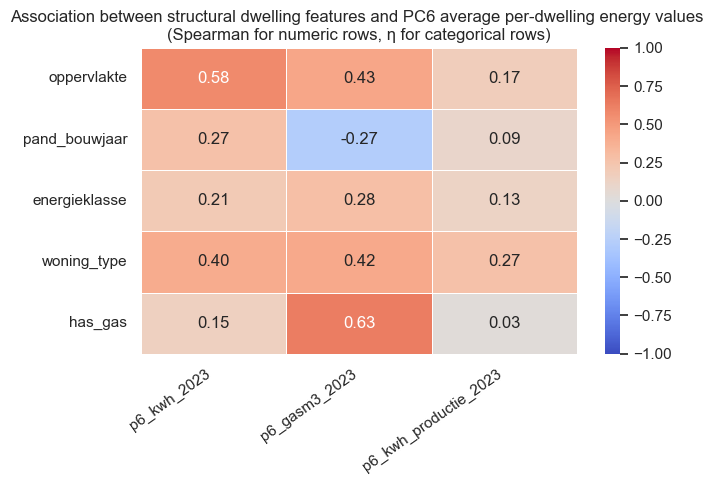

In [36]:
# ----------------------------
# 4.4G Structural ↔ energy association matrix
# ----------------------------

# energy variables
energy_vars = [
    "p6_kwh_2023",
    "p6_gasm3_2023",
    "p6_kwh_productie_2023"
]

# structural variables
struct_num = ["oppervlakte", "pand_bouwjaar"]
struct_cat = ["energieklasse", "woning_type", "has_gas"]

struct_vars = struct_num + struct_cat

# ensure energy columns numeric
for c in energy_vars:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")


# create association matrix
assoc_matrix = pd.DataFrame(index=struct_vars, columns=energy_vars)

for s in struct_vars:
    for e in energy_vars:

        # continuous ↔ continuous → Spearman
        if s in struct_num:
            assoc_matrix.loc[s, e] = df_dwelling[[s, e]].corr(method="spearman").iloc[0, 1]

        # categorical ↔ continuous → correlation ratio
        else:
            assoc_matrix.loc[s, e] = correlation_ratio(df_dwelling[s], df_dwelling[e])

assoc_matrix = assoc_matrix.astype(float)

display(assoc_matrix)

# ----------------------------
# Plot heatmap
# ----------------------------

plt.figure(figsize=(7,5))

ax = sns.heatmap(
    assoc_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Association between structural dwelling features and PC6 average per-dwelling energy values \n(Spearman for numeric rows, η for categorical rows)")

# fix x-axis readability
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

### Interpretation of structural–energy associations

The strongest relationship is observed between **floor area (`oppervlakte`) and electricity consumption (`p6_kwh_2023`)** (≈0.57), indicating that larger dwellings tend to consume substantially more electricity. This is consistent with expectations since larger homes typically contain more appliances, lighting, and conditioned space.

**Construction year (`pand_bouwjaar`)** exhibits a negative relationship with gas consumption (≈−0.28), suggesting that newer buildings tend to require less gas for heating due to improved insulation and building standards. 

**Dwelling type (`woning_type`)** shows strong-moderate associations with both electricity and gas demand (≈0.40), indicating that building typology captures structural differences in dwelling scale. In other words grouping dwellings by type (e.g. apartment, detached) reveals systematic differences in average electricity consumption across categories, with dwelling type accounting for approximately 40% of the observed variation.

In contrast, associations with **electricity production (`p6_kwh_productie_2023`)** are relatively weak across all structural variables, suggesting that photovoltaic adoption is influenced by additional factors beyond the building characteristics captured in this dataset.

Overall, the results indicate that residential energy demand is influenced by the **structural composition of the housing stock**, particularly dwelling size, typology, and heating infrastructure. This motivates the later modelling approach where PC6-level energy demand is related to the composition of dwelling characteristics within each postcode area.

### Methodological note

Energy variables are reported at **PC6 level**, meaning that all dwellings within the same postcode share identical energy values. As a result, postcode areas with more dwellings contribute more observations to the correlation analysis. The results should therefore be interpreted as **exploratory relationships between dwelling characteristics and area-level energy outcomes**, rather than strictly dwelling-level causal relationships.

## 5️⃣ PC6-level structural composition and energy analysis

The previous chapter examined structural dwelling characteristics at micro level and explored how these characteristics relate to postcode-level energy variables.

The next step is to move from the **dwelling level** to the **PC6 level**, since the final modelling stage is based on postcode areas rather than individual dwellings.

This requires constructing a new dataset with **one row per PC6**, where:

- dwelling-level structural information can be aggregated into postcode-level composition variables
- energy variables are expressed consistently at PC6 level

We proceed in structured steps:

1. Construct a clean **PC6 base dataset**
2. Examine **PC6 energy scaling**
3. Compute **PC6 structural composition variables**
4. Construct **size-normalized PC6 energy indicators**

### 5.1 Within-PC6 structural dispersion

Before aggregating dwelling-level variables to postcode level, it is useful to examine how heterogeneous dwellings are within each PC6 area. If dwellings inside a postcode area are structurally homogeneous, postcode averages provide a reliable representation of the housing stock. If large internal variation exists, aggregation may hide important structural differences.

To evaluate this, we measure the **coefficient of variation (CV)** of key dwelling characteristics within each PC6. The coefficient of variation is defined as:

$$ CV = \frac{{σ}}{{μ}} $$
where:
- σ is the standard deviation within a PC6
- μ is the mean value within the PC6

The CV measures **relative dispersion**, meaning the amount of variation compared to the typical level of the variable. For example:
- CV = 0.10 → variation equals about 10% of the mean
- CV = 0.25 → variation equals about 25% of the mean

This metric is useful because it allows dispersion to be compared across variables with different units and scales. The analysis focuses on two structural dwelling characteristics:
- `oppervlakte` — dwelling floor area  
- `pand_bouwjaar` — construction year

For each PC6 area we compute the coefficient of variation and examine the distribution of these values across postcode areas.

Number of PC6 areas: 257669

Summary statistics of within-PC6 dispersion (Coefficient of Variation):


,cv_oppervlakte,cv_bouwjaar
count,254398.000000,254398.000000
mean,0.173108,0.002509
std,0.143099,0.006443
min,0.000000,0.000000
1%,0.000000,0.000000
5%,0.000000,0.000000
25%,0.072926,0.000000
50%,0.142427,0.000000
75%,0.238276,0.001279
95%,0.436176,0.014895


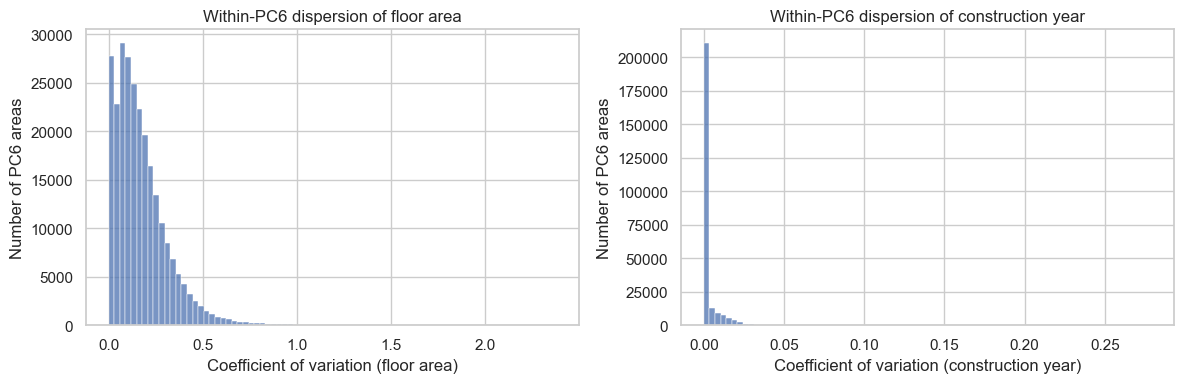

In [37]:
# ----------------------------
# 5.1 Within-PC6 structural dispersion (Coefficient of Variation)
# ----------------------------

# variables of interest
dispersion_vars = ["oppervlakte", "pand_bouwjaar"]

# compute mean and standard deviation within each PC6
pc6_mean = df_dwelling.groupby("postcode")[dispersion_vars].mean()
pc6_std = df_dwelling.groupby("postcode")[dispersion_vars].std()

# compute coefficient of variation
pc6_cv = pd.DataFrame({
    "cv_oppervlakte": pc6_std["oppervlakte"] / pc6_mean["oppervlakte"],
    "cv_bouwjaar": pc6_std["pand_bouwjaar"] / pc6_mean["pand_bouwjaar"]
})

print("Number of PC6 areas:", len(pc6_cv))

# summary statistics
print("\nSummary statistics of within-PC6 dispersion (Coefficient of Variation):")
display(
    pc6_cv.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])
)

# ----------------------------
# visualization
# ----------------------------

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(pc6_cv["cv_oppervlakte"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("Within-PC6 dispersion of floor area")
axes[0].set_xlabel("Coefficient of variation (floor area)")
axes[0].set_ylabel("Number of PC6 areas")

sns.histplot(pc6_cv["cv_bouwjaar"].dropna(), bins=80, ax=axes[1])
axes[1].set_title("Within-PC6 dispersion of construction year")
axes[1].set_xlabel("Coefficient of variation (construction year)")
axes[1].set_ylabel("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Interpretation

The coefficient of variation shows that postcode areas exhibit **moderate internal variation in dwelling size but very little variation in construction year**.  
For floor area, the median CV is approximately **0.14**, meaning that the standard deviation of dwelling size within a typical PC6 area is about **14% of the mean dwelling size**. This indicates that most postcode areas contain dwellings of broadly similar size, although the upper tail of the distribution reveals some mixed neighbourhoods with substantially larger size variation.

In contrast, construction year shows **very low dispersion**. The median CV is **0**, indicating that more than half of postcode areas contain dwellings built in the same construction period. This reflects the common development pattern of Dutch neighbourhoods, where housing is often constructed as part of a single development phase.

Given the moderate within-PC6 variation in floor area and the very low within-PC6 variation in construction year, the use of `mean_oppervlakte` and `mean_bouwjaar` as PC6-level summary variables in the following aggregation step is considered appropriate.

### 5.2 Construct PC6 base dataset

We begin by creating a base dataset with **one observation per PC6**.

The dwelling-level dataset contains multiple rows per postcode area, since each row corresponds to an individual dwelling. By contrast, the CBS dataset is already defined at PC6 level and contains one row per postcode area.

To combine these two sources consistently, the dwelling-level dataset is first aggregated to postcode level. The resulting PC6 base dataset is then enriched with selected CBS socioeconomic and housing-context variables using postcode as the common key.

For each postcode area, the base dataset includes:

- `n_dwellings` — number of dwellings in the PC6  
- `pc6_kwh_total_2023` — total electricity consumption in the PC6  
- `pc6_gasm3_total_2023` — total gas consumption in the PC6  
- `pc6_kwh_productie_total_2023` — total electricity production in the PC6  
- selected CBS variables:
  - `population_total`
  - `avg_household_size`
  - `unoccupied_dwellings`
  - `avg_woz_value`
  - `population_on_benefits`

Electricity consumption and PV production are reported in the source dataset as postcode-level average values per dwelling and are repeated across dwellings within the same PC6. Aggregating them using `sum` therefore reconstructs total PC6 energy demand. Gas consumption is also aggregated using `sum`, but unlike electricity and PV production it may vary across dwellings within the same postcode due to differences in gas connectivity.

In [38]:
# ----------------------------
# 5.2 Construct PC6 base dataset
# ----------------------------

# ensure energy variables are numeric
energy_cols = ["p6_kwh_2023", "p6_gasm3_2023", "p6_kwh_productie_2023"]

for c in energy_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# aggregate dwelling-level data to one row per PC6
pc6_base = (
    df_dwelling
    .groupby("postcode")
    .agg(
        municipality_code=("gemeentecode", "first"),
        n_dwellings=("postcode", "size"),
        pc6_kwh_total_2023=("p6_kwh_2023", "sum"),
        pc6_gasm3_total_2023=("p6_gasm3_2023", "sum"),
        pc6_kwh_productie_total_2023=("p6_kwh_productie_2023", "sum")
    )
    .reset_index()
)

# keep only relevant CBS variables
cbs_cols_for_base = [
    "postcode",
    "Inwoners totaal",
    "Gemiddelde huishoudgrootte",
    "Niet bewoonde woningen",
    "Gemiddelde WOZ-waarde woningen",
    "Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering"
]

df_cbs_pc6_model = df_cbs_pc6.loc[
    df_cbs_pc6["postcode"].isin(pc6_base["postcode"]),
    cbs_cols_for_base
].copy()

# merge CBS PC6-level variables into PC6 base dataset
pc6_base = pc6_base.merge(
    df_cbs_pc6_model,
    on="postcode",
    how="left",
    validate="one_to_one"
)

# translate CBS variables directly in pc6_base
pc6_base = pc6_base.rename(columns={
    "Inwoners totaal": "population_total",
    "Gemiddelde huishoudgrootte": "avg_household_size",
    "Niet bewoonde woningen": "unoccupied_dwellings",
    "Gemiddelde WOZ-waarde woningen": "avg_woz_value",
    "Inwoners met WW, Bijstand en/of Arbeidsongeschiktheidsuitkering":
        "population_on_benefits"
})

# ----------------------------
# Diagnostics BEFORE filtering
# ----------------------------

total_pc6_before = len(pc6_base)

missing_cbs = pc6_base["population_total"].isna().sum()
available_cbs = pc6_base["population_total"].notna().sum()

print("Total PC6 before filtering:", total_pc6_before)
print("PC6 with CBS data:", available_cbs)
print("PC6 without CBS data (to be dropped):", missing_cbs)
print("Share removed:", round(missing_cbs / total_pc6_before * 100, 3), "%")

# restrict to PC6 with CBS data (analysis sample)
pc6_base = pc6_base.dropna(subset=["population_total"]).copy()

print("PC6 base dataset")
print("rows:", len(pc6_base))
print("unique PC6:", pc6_base["postcode"].nunique())

pc6_base.head()

Total PC6 before filtering: 257669
PC6 with CBS data: 247049
PC6 without CBS data (to be dropped): 10620
Share removed: 4.122 %
PC6 base dataset
rows: 247049
unique PC6: 247049


,postcode,municipality_code,n_dwellings,pc6_kwh_total_2023,pc6_gasm3_total_2023,pc6_kwh_productie_total_2023,population_total,avg_household_size,unoccupied_dwellings,avg_woz_value,population_on_benefits
0,1011AN,GM0363,26,68146.0,38114.0,0.0,40.0,1.6,NaN,622.0,NaN
1,1011AX,GM0363,16,51824.0,19799.0,0.0,30.0,2.1,5.0,870.0,NaN
2,1011BA,GM0363,9,17217.0,5202.0,387.0,15.0,1.4,NaN,559.0,NaN
3,1011BR,GM0363,12,22896.0,11664.0,0.0,15.0,1.3,NaN,647.0,NaN
4,1011CW,GM0363,13,37375.0,9997.0,2106.0,25.0,1.8,NaN,623.0,NaN


### Methodological Note

A total of 10,620 PC6 areas (approximately 4.1% of the dataset) are excluded due to missing CBS variables. In the dataset, these appear as NaN values after converting CBS placeholder codes for suppressed or unavailable data. These missing values arise because CBS does not publish statistics for postcode areas with very small populations or insufficient observations, in order to protect confidentiality and ensure statistical reliability. The final analysis sample therefore consists of 247,049 PC6 areas for which both structural dwelling data and CBS socioeconomic variables are available.

### 5.3 PC6 energy scaling diagnostics

Before choosing how to normalize energy consumption, we examine how total PC6 energy demand scales with the number of dwellings in each postcode area.

If energy increases proportionally with the number of dwellings, dividing energy by dwelling count would provide a meaningful measure of average demand per dwelling. If the relationship is non-linear, simple normalization may fail to fully remove the influence of postcode size and may distort the structural signal.

To investigate this, we analyse the relationship between postcode size and three PC6 energy totals:

- `pc6_kwh_total_2023`
- `pc6_gasm3_total_2023`
- `pc6_kwh_productie_total_2023`

The PC6 energy totals are reconstructed by aggregating postcode-level average consumption values per dwelling from the source dataset. Since these averages are repeated for all dwellings within a PC6, summing them yields total energy demand at postcode level.

The scaling relationship is estimated using the regression model

$$
\log(E_{pc6}) = a + b \log(N_{pc6}) + \varepsilon
$$

where:

- $E_{pc6}$ is total PC6 energy demand
- $N_{pc6}$ is the number of dwellings in the postcode
- $a$ is the intercept
- $b$ is the scaling exponent
- $\varepsilon$ represents unexplained variation

The parameter of primary interest is the scaling exponent $b$.

- If $b = 1$, energy scales proportionally with postcode size
- If $b < 1$, larger postcode areas tend to consume less energy per dwelling on average
- If $b > 1$, larger postcode areas tend to consume more energy per dwelling

Log-log scatterplots and fitted scaling lines are used to visualize this relationship.

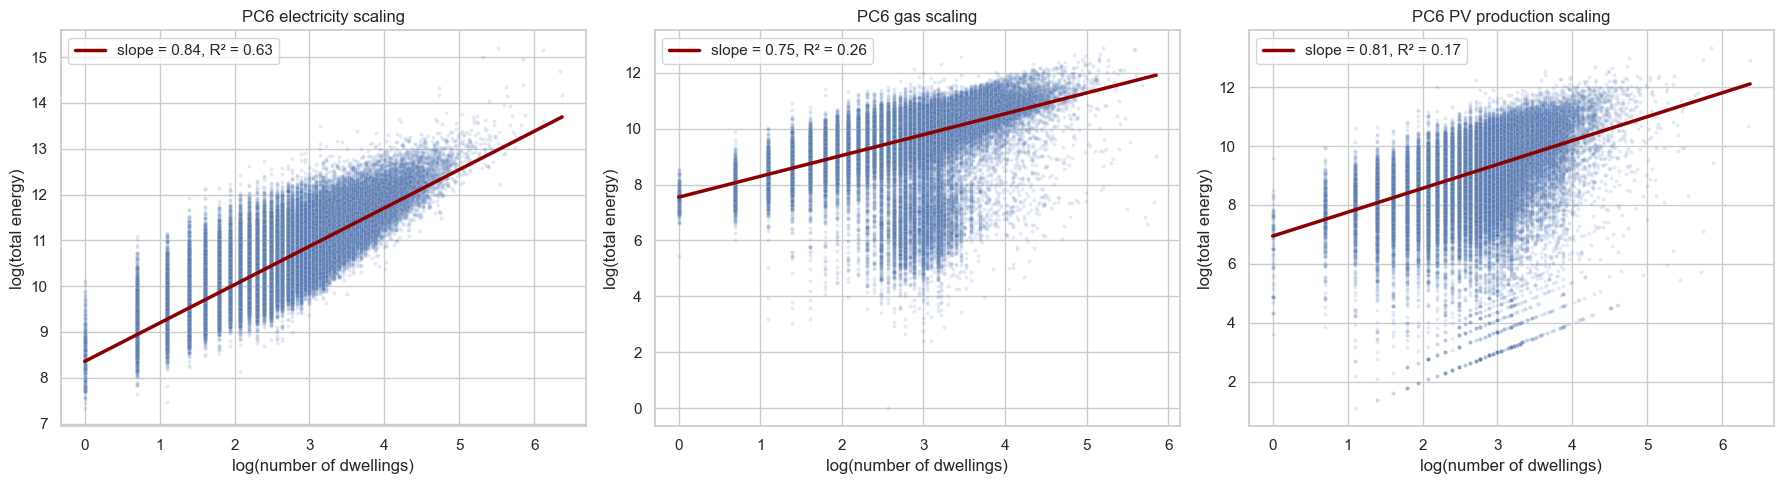


pc6_kwh_total_2023
log(E_pc6) = 8.357 + 0.837 * log(N_pc6)
scaling exponent b = 0.837
R² = 0.631

pc6_gasm3_total_2023
log(E_pc6) = 7.550 + 0.746 * log(N_pc6)
scaling exponent b = 0.746
R² = 0.262

pc6_kwh_productie_total_2023
log(E_pc6) = 6.944 + 0.810 * log(N_pc6)
scaling exponent b = 0.810
R² = 0.172


,Energy variable,Scaling exponent b,R²
0,Electricity consumption,0.837,0.631
1,Gas consumption,0.746,0.262
2,PV production,0.810,0.172


In [39]:
# ----------------------------
# 5.3 PC6 energy scaling diagnostics
# ----------------------------

from scipy.stats import linregress

scaling_vars = [
    "pc6_kwh_total_2023",
    "pc6_gasm3_total_2023",
    "pc6_kwh_productie_total_2023"
]

titles = [
    "PC6 electricity scaling",
    "PC6 gas scaling",
    "PC6 PV production scaling"
]

# dictionary to store regression results
scaling_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for var, title, ax in zip(scaling_vars, titles, axes):

    tmp = pc6_base.loc[
        (pc6_base["n_dwellings"] > 0) &
        (pc6_base[var] > 0)
    ].copy()

    tmp["log_n_dwellings"] = np.log(tmp["n_dwellings"])
    tmp["log_energy"] = np.log(tmp[var])

    sns.scatterplot(
        data=tmp,
        x="log_n_dwellings",
        y="log_energy",
        s=8,
        alpha=0.15,
        ax=ax
    )

    slope, intercept, r, p, se = linregress(
        tmp["log_n_dwellings"],
        tmp["log_energy"]
    )

    # store results
    scaling_results[var] = {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2
    }

    # regression line
    x_line = np.linspace(
        tmp["log_n_dwellings"].min(),
        tmp["log_n_dwellings"].max(),
        200
    )
    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        color="darkred",
        linewidth=2.5,
        label=f"slope = {slope:.2f}, R² = {r**2:.2f}"
    )

    ax.set_title(title)
    ax.set_xlabel("log(number of dwellings)")
    ax.set_ylabel("log(total energy)")
    ax.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Print stored scaling results
# ----------------------------

for var in scaling_vars:

    intercept = scaling_results[var]["intercept"]
    slope = scaling_results[var]["slope"]
    r2 = scaling_results[var]["r2"]

    print(f"\n{var}")
    print(f"log(E_pc6) = {intercept:.3f} + {slope:.3f} * log(N_pc6)")
    print(f"scaling exponent b = {slope:.3f}")
    print(f"R² = {r2:.3f}")

# ----------------------------
# Scaling results summary table
# ----------------------------

scaling_summary = pd.DataFrame({
    "Energy variable": [
        "Electricity consumption",
        "Gas consumption",
        "PV production"
    ],
    "Scaling exponent b": [
        scaling_results["pc6_kwh_total_2023"]["slope"],
        scaling_results["pc6_gasm3_total_2023"]["slope"],
        scaling_results["pc6_kwh_productie_total_2023"]["slope"]
    ],
    "R²": [
        scaling_results["pc6_kwh_total_2023"]["r2"],
        scaling_results["pc6_gasm3_total_2023"]["r2"],
        scaling_results["pc6_kwh_productie_total_2023"]["r2"]
    ]
})

scaling_summary["Scaling exponent b"] = scaling_summary["Scaling exponent b"].round(3)
scaling_summary["R²"] = scaling_summary["R²"].round(3)

display(scaling_summary)

### Interpretation of PC6 energy scaling

All estimated exponents are **below one**, indicating **sublinear scaling**. This means that energy demand increases with the number of dwellings but less than proportionally. For example, the electricity exponent of 0.837 implies that a 10% increase in the number of dwellings corresponds to approximately an **8.4% increase in electricity demand**.

The coefficient of determination ($R^2$) indicates how much of the variation in postcode energy demand is explained by postcode size alone. Electricity demand shows the strongest scaling relationship with postcode size, whereas gas consumption and PV production show weaker relationships, indicating that additional structural characteristics influence these energy outcomes.

The intercept $a$ represents the baseline energy level implied by the scaling relationship. Rewriting the model gives

$$
E_{pc6} = e^{a} \cdot N_{pc6}^{b}
$$

which shows that $e^{a}$ corresponds to the expected energy demand for a postcode containing a single dwelling. In practice, this intercept reflects the baseline energy intensity of the housing stock independent of postcode size.

Because the estimated exponents are below one, dividing energy by the number of dwellings would not fully remove the influence of postcode size. Postcode size should therefore be accounted for explicitly in the subsequent modelling stage.

### 5.4 Compute PC6 composition variables

We now compute composition indicators describing the housing stock within each postcode area.

These variables summarize the dwelling-level structural dataset at PC6 level and are combined with selected contextual variables from the CBS dataset.

Two types of indicators are constructed.

**Average variables**

- mean floor area (`mean_oppervlakte`)
- mean construction year (`mean_bouwjaar`)
- average household size (`avg_household_size`)
- average WOZ value (`avg_woz_value`)

**Composition shares**

- share of dwellings with gas connection (`share_has_gas`)
- share of each dwelling type (`woning_type`)
- share of each energy label (`energieklasse`)
- share of unoccupied dwellings (`share_unoccupied`)
- share of population receiving benefits (`share_population_on_benefits`)

These variables describe the structural and socioeconomic composition of the housing stock within each postcode and will later be used to examine how postcode composition relates to energy demand.


In [40]:
# ----------------------------
# 5.4 Compute PC6 composition variables
# ----------------------------

df_dwelling["oppervlakte"] = pd.to_numeric(df_dwelling["oppervlakte"], errors="coerce")
df_dwelling["pand_bouwjaar"] = pd.to_numeric(df_dwelling["pand_bouwjaar"], errors="coerce")
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

# 1. Basic structural averages / shares
pc6_structure_basic = (
    df_dwelling
    .groupby("postcode")
    .agg(
        mean_oppervlakte=("oppervlakte", "mean"),
        mean_bouwjaar=("pand_bouwjaar", "mean"),
        share_has_gas=("has_gas", "mean")
    )
    .reset_index()
)

# 2. Dwelling type shares
pc6_woningtype = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["woning_type"],
    normalize="index"
)

pc6_woningtype.columns = [
    f"share_woning_type_{c}" for c in pc6_woningtype.columns
]
pc6_woningtype = pc6_woningtype.reset_index()

# 3. Energy label shares
pc6_energylabel = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["energieklasse"],
    normalize="index"
)

present_labels = [c for c in label_order if c in pc6_energylabel.columns]
pc6_energylabel = pc6_energylabel.reindex(columns=present_labels)

pc6_energylabel.columns = [
    f"share_energieklasse_{c}" for c in pc6_energylabel.columns
]
pc6_energylabel = pc6_energylabel.reset_index()

# 4. Merge into temporary PC6 dataset
pc6_temp = (
    pc6_base
    .merge(pc6_structure_basic, on="postcode", how="left")
    .merge(pc6_woningtype, on="postcode", how="left")
    .merge(pc6_energylabel, on="postcode", how="left")
)

# 5. Construct CBS-based share variables
pc6_temp["share_unoccupied"] = (
    pc6_temp["unoccupied_dwellings"] / pc6_temp["n_dwellings"]
)

pc6_temp["share_population_on_benefits"] = (
    pc6_temp["population_on_benefits"] / pc6_temp["population_total"]
)

# avoid division issues
pc6_temp.loc[pc6_temp["n_dwellings"] == 0, "share_unoccupied"] = np.nan
pc6_temp.loc[pc6_temp["population_total"] == 0, "share_population_on_benefits"] = np.nan

# fill only structural composition shares
share_cols_structural = (
    ["share_has_gas"] +
    [c for c in pc6_temp.columns if c.startswith("share_woning_type_")] +
    [c for c in pc6_temp.columns if c.startswith("share_energieklasse_")]
)

pc6_temp[share_cols_structural] = pc6_temp[share_cols_structural].fillna(0)

# 6. Keep only variables needed later
composition_cols = [
    "postcode",
    "municipality_code",
    "n_dwellings",
    "pc6_kwh_total_2023",
    "pc6_gasm3_total_2023",
    "pc6_kwh_productie_total_2023",
    "population_total",
    "avg_household_size",
    "avg_woz_value",
    "mean_oppervlakte",
    "mean_bouwjaar",
    "share_has_gas",
    "share_unoccupied",
    "share_population_on_benefits",
]

composition_cols += [c for c in pc6_temp.columns if c.startswith("share_woning_type_")]
composition_cols += [c for c in pc6_temp.columns if c.startswith("share_energieklasse_")]

pc6_dataset = pc6_temp[composition_cols].copy()

print("PC6 composition dataset")
print("rows:", len(pc6_dataset))
print("columns:", len(pc6_dataset.columns))

print("\nMissing values in CBS-derived variables:")
display(
    pc6_dataset[[
        "avg_household_size",
        "avg_woz_value",
        "share_unoccupied",
        "share_population_on_benefits"
    ]].isna().sum()
)

pc6_dataset.head()

PC6 composition dataset
rows: 247049
columns: 36

Missing values in CBS-derived variables:


avg_household_size               11683
avg_woz_value                    12617
share_unoccupied                245073
share_population_on_benefits    188164
dtype: int64

,postcode,municipality_code,n_dwellings,pc6_kwh_total_2023,pc6_gasm3_total_2023,pc6_kwh_productie_total_2023,population_total,avg_household_size,avg_woz_value,mean_oppervlakte,...,share_energieklasse_A++,share_energieklasse_A+,share_energieklasse_A,share_energieklasse_B,share_energieklasse_C,share_energieklasse_D,share_energieklasse_E,share_energieklasse_F,share_energieklasse_G,share_energieklasse_no_label
0,1011AN,GM0363,26,68146.0,38114.0,0.0,40.0,1.6,622.0,75.615385,...,0.0,0.0,0.346154,0.038462,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231
1,1011AX,GM0363,16,51824.0,19799.0,0.0,30.0,2.1,870.0,113.312500,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500
2,1011BA,GM0363,9,17217.0,5202.0,387.0,15.0,1.4,559.0,58.111111,...,0.0,0.0,0.444444,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556
3,1011BR,GM0363,12,22896.0,11664.0,0.0,15.0,1.3,647.0,85.333333,...,0.0,0.0,0.000000,0.000000,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667
4,1011CW,GM0363,13,37375.0,9997.0,2106.0,25.0,1.8,623.0,83.384615,...,0.0,0.0,0.000000,0.000000,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538


### Methodological Note
For certain CBS count variables, the code -99997 indicates values between 0 and 4 or suppressed observations. These values are therefore not imputed when constructing shares. Instead, they are retained as missing and handled explicitly in later correlation and regression analyses.

### 5.5 Size-normalized PC6 energy indicators

The scaling diagnostics in Section 5.3 showed that total PC6 energy demand increases sublinearly with the number of dwellings. To remove the mechanical influence of postcode size, we compute **size-normalized energy indicators**:

$$
E_{\text{normalized}} = \frac{E_{pc6}}{N_{pc6}^{b}}
$$

where:

- $E_{pc6}$ is total energy consumption in the postcode area  
- $N_{pc6}$ is the number of dwellings  
- $b$ is the scaling exponent from Section 5.3  

This transformation preserves variation associated with structural and socioeconomic composition while removing the mechanical influence of postcode size.

Normalized energy variables:

- `kwh_norm_pc6`
- `gas_norm_pc6`
- `pv_norm_pc6`

In [41]:
# ----------------------------
# 5.5 Size-normalized PC6 energy indicators
# ----------------------------

b_kwh = scaling_results["pc6_kwh_total_2023"]["slope"]
b_gas = scaling_results["pc6_gasm3_total_2023"]["slope"]
b_pv  = scaling_results["pc6_kwh_productie_total_2023"]["slope"]

pc6_dataset["kwh_norm_pc6"] = pc6_dataset["pc6_kwh_total_2023"] / (pc6_dataset["n_dwellings"] ** b_kwh)
pc6_dataset["gas_norm_pc6"] = pc6_dataset["pc6_gasm3_total_2023"] / (pc6_dataset["n_dwellings"] ** b_gas)
pc6_dataset["pv_norm_pc6"] = pc6_dataset["pc6_kwh_productie_total_2023"] / (pc6_dataset["n_dwellings"] ** b_pv)

pc6_dataset[["n_dwellings", "kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]].describe()

,n_dwellings,kwh_norm_pc6,gas_norm_pc6,pv_norm_pc6
count,247049.000000,247049.000000,247049.000000,247049.000000
mean,19.025748,4598.468446,2043.936221,468.057122
std,12.537213,2126.538501,1093.527885,939.917620
min,1.000000,595.898517,0.000000,0.000000
25%,12.000000,3370.598523,1572.741123,0.000000
50%,17.000000,4185.181511,2040.728254,0.000000
75%,23.000000,5216.908686,2537.445715,548.663080
max,586.000000,52221.615899,23903.070176,27268.982587


### 5.6 Association between PC6 composition and normalized energy

After removing the mechanical effect of postcode size, we investigate how **structural and socioeconomic composition** relates to energy intensity across postcode areas.

Before computing the correlation heatmaps, we first evaluate how missing CBS-derived variables should be handled. In particular, we test whether missingness itself carries predictive information and therefore whether some variables should be supplemented with a **binary missing indicator** in later modelling.

The analysis therefore proceeds in two steps:

1. **Diagnostic 5.6A**: identify which CBS-derived variables should be:
   - excluded entirely,
   - kept as filled variables only,
   - or kept together with a binary missing indicator

2. **Correlation analysis 5.6B**: compute the association between the resulting PC6 composition variables and the normalized energy indicators.

Normalized energy indicators:

- `kwh_norm_pc6`
- `gas_norm_pc6`
- `pv_norm_pc6`

### 5.6A Diagnostic: Checking which CBS variables need a missingness indicator

Some CBS variables contain missing or suppressed values (`NaN`). Before running correlation heatmaps or regression models, it is important to determine whether the missingness itself carries predictive information.

For each candidate variable $X$:

1. **Filled variable** (replace missing values with 0):  
$$
X_{\text{filled}} =
\begin{cases}
X & \text{if observed} \\
0 & \text{if missing}
\end{cases}
$$

2. **Binary missing indicator**:  
$$
\text{missing} =
\begin{cases}
1 & \text{if } X \text{ is missing} \\
0 & \text{otherwise}
\end{cases}
$$

We regress the normalized energy variables (`kwh_norm_pc6`, `gas_norm_pc6`, `pv_norm_pc6`) on both `filled` and `missing`:

$$
Y_{\text{norm}} = \alpha + \beta X_{\text{filled}} + \gamma \,\text{missing} + \varepsilon
$$

The diagnostic compares three approaches:

1. **Dropna**: use only PC6 areas with observed values  
2. **Filled**: replace missing values with 0  
3. **Filled + missing indicator**: replace missing values with 0 and include a binary indicator

The table also reports the missing fraction of each variable. These results are used to determine which CBS-derived variables should be excluded, which should be kept as filled variables only, and which should be kept together with a binary missing indicator.

In [42]:
# ----------------------------
# 5.6A Diagnostic: Missing indicator check
# ----------------------------

import statsmodels.api as sm
import pandas as pd
import numpy as np

# normalized energy variables
energy_norm_vars = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]

# CBS-derived composition variables to check
cbs_vars = [
    "avg_woz_value",
    "avg_household_size",
    "share_unoccupied",
    "share_population_on_benefits"
]

results = []

for var in cbs_vars:

    tmp = pc6_dataset.copy()

    # compute missing fraction
    missing_frac = tmp[var].isna().mean()

    # create filled + missing indicator
    tmp["filled"] = tmp[var].fillna(0)
    tmp["missing"] = tmp[var].isna().astype(int)

    for energy in energy_norm_vars:

        # ----------------------------
        # dropna correlation
        # ----------------------------
        tmp_drop = tmp[[var, energy]].dropna()
        corr_drop = (
            tmp_drop.corr(method="spearman").iloc[0, 1]
            if len(tmp_drop) > 1 else np.nan
        )

        # ----------------------------
        # filled only correlation
        # ----------------------------
        corr_filled = tmp[["filled", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # missing indicator correlation
        # ----------------------------
        corr_missing = tmp[["missing", energy]].corr(method="spearman").iloc[0, 1]

        # ----------------------------
        # Regression models
        # ----------------------------

        # Model 1: dropna
        if len(tmp_drop) > 10:
            X1 = sm.add_constant(tmp_drop[[var]])
            y1 = tmp_drop[energy]
            m1 = sm.OLS(y1, X1).fit()
            r2_drop = m1.rsquared_adj
            n_drop = int(m1.nobs)
        else:
            r2_drop = np.nan
            n_drop = 0

        # Model 2: filled only
        X2 = sm.add_constant(tmp[["filled"]])
        y2 = tmp[energy]
        m2 = sm.OLS(y2, X2).fit()

        # Model 3: filled + missing indicator
        X3 = sm.add_constant(tmp[["filled", "missing"]])
        y3 = tmp[energy]
        m3 = sm.OLS(y3, X3).fit()

        results.append({
            "variable": var,
            "energy_norm": energy,
            "missing_fraction": missing_frac,
            "corr_dropna": corr_drop,
            "corr_filled": corr_filled,
            "corr_missing": corr_missing,
            "N_dropna": n_drop,
            "N_full": len(tmp),
            "R2_dropna": r2_drop,
            "R2_filled": m2.rsquared_adj,
            "R2_filled+ind": m3.rsquared_adj,
            "coef_filled": m2.params["filled"],
            "p_filled": m2.pvalues["filled"],
            "coef_missing": m3.params["missing"],
            "p_missing": m3.pvalues["missing"]
        })

results_df = pd.DataFrame(results).round(4)
display(results_df)

,variable,energy_norm,missing_fraction,corr_dropna,corr_filled,corr_missing,N_dropna,N_full,R2_dropna,R2_filled,R2_filled+ind,coef_filled,p_filled,coef_missing,p_missing
0,avg_woz_value,kwh_norm_pc6,0.0511,0.5263,0.4529,0.0455,234432,247049,0.2643,0.1524,0.2326,4.0396,0.0000,2977.5699,0.0000
1,avg_woz_value,gas_norm_pc6,0.0511,0.3233,0.3166,-0.0742,234432,247049,0.1400,0.1224,0.1329,1.8620,0.0000,552.6085,0.0000
2,avg_woz_value,pv_norm_pc6,0.0511,0.2104,0.1824,0.0178,234432,247049,0.0299,0.0209,0.0282,0.6617,0.0000,395.6643,0.0000
3,avg_household_size,kwh_norm_pc6,0.0473,0.5259,0.4577,0.0432,235366,247049,0.1631,0.0481,0.1486,622.6596,0.0000,4118.5725,0.0000
4,avg_household_size,gas_norm_pc6,0.0473,0.3003,0.2964,-0.0680,235366,247049,0.0580,0.0417,0.0560,297.8913,0.0000,799.5009,0.0000
5,avg_household_size,pv_norm_pc6,0.0473,0.1743,0.1516,0.0175,235366,247049,0.0425,0.0195,0.0401,175.1128,0.0000,825.5359,0.0000
6,share_unoccupied,kwh_norm_pc6,0.9920,-0.1517,0.0062,-0.0062,1976,247049,-0.0001,0.0000,0.0004,198.3407,0.0025,-492.0659,0.0000
7,share_unoccupied,gas_norm_pc6,0.9920,-0.0555,-0.0536,0.0536,1976,247049,0.0019,0.0009,0.0034,-498.0068,0.0000,689.1640,0.0000
8,share_unoccupied,pv_norm_pc6,0.9920,-0.0700,-0.0262,0.0262,1976,247049,-0.0004,0.0001,0.0004,-108.2929,0.0002,209.3144,0.0000
9,share_population_on_benefits,kwh_norm_pc6,0.7616,-0.4655,-0.2382,0.2079,58885,247049,0.1040,0.0420,0.0420,-4601.5663,0.0000,-2.4238,0.8928


### 5.6A Interpretation and variable decisions

The diagnostic results indicate three different cases.

- **`share_unoccupied`** has an extremely high missing fraction (about 99%) and exhibits essentially zero explanatory power across all normalized energy variables. It is therefore excluded from subsequent correlation analysis and regression modelling.

- **`share_population_on_benefits`** has substantial missingness (about 76%), but the addition of a binary missing indicator yields either no improvement or only a negligible improvement in explanatory power. It is therefore retained as a **filled variable only**, without a binary missing indicator.

- **`avg_woz_value`** and **`avg_household_size`** have relatively low missing fractions (about 5%), and the addition of a binary missing indicator yields a substantial improvement in explanatory power, especially for normalized electricity and gas demand. These variables are therefore retained together with both:
  - a **filled version**, and
  - a **binary missing indicator**

The resulting modelling decisions are summarized below.

| Variable | Missing fraction | Keep in analysis? | Use filled version? | Add missing indicator? |
|----------|------------------|-------------------|---------------------|------------------------|
| avg_woz_value | ~5% | Yes | Yes | Yes |
| avg_household_size | ~5% | Yes | Yes | Yes |
| share_unoccupied | ~99% | No | No | No |
| share_population_on_benefits | ~76% | Yes | Yes | No |

These decisions are applied below to construct the final set of PC6 composition variables used in the heatmaps and in the later regression analysis.

In [43]:
# ----------------------------
# 5.6A Apply variable decisions
# ----------------------------

pc6_analysis = pc6_dataset.copy()

# 1. Remove variable with extreme missingness and negligible explanatory power
pc6_analysis = pc6_analysis.drop(columns=["share_unoccupied"])

# 2. Create filled versions and missing indicators for selected variables
pc6_analysis["avg_woz_value_filled"] = pc6_analysis["avg_woz_value"].fillna(0)
pc6_analysis["avg_woz_value_missing"] = pc6_analysis["avg_woz_value"].isna().astype(int)

pc6_analysis["avg_household_size_filled"] = pc6_analysis["avg_household_size"].fillna(0)
pc6_analysis["avg_household_size_missing"] = pc6_analysis["avg_household_size"].isna().astype(int)

# 3. Keep population on benefits as filled only
pc6_analysis["share_population_on_benefits_filled"] = (
    pc6_analysis["share_population_on_benefits"].fillna(0)
)

# 4. Drop original CBS variables that are replaced
pc6_analysis = pc6_analysis.drop(columns=[
    "avg_woz_value",
    "avg_household_size",
    "share_population_on_benefits"
])

print("PC6 analysis dataset")
print("rows:", len(pc6_analysis))
print("columns:", len(pc6_analysis.columns))

display(pc6_analysis.head())

PC6 analysis dataset
rows: 247049
columns: 40


,postcode,municipality_code,n_dwellings,pc6_kwh_total_2023,pc6_gasm3_total_2023,pc6_kwh_productie_total_2023,population_total,mean_oppervlakte,mean_bouwjaar,share_has_gas,...,share_energieklasse_G,share_energieklasse_no_label,kwh_norm_pc6,gas_norm_pc6,pv_norm_pc6,avg_woz_value_filled,avg_woz_value_missing,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1011AN,GM0363,26,68146.0,38114.0,0.0,40.0,75.615385,1789.923077,0.730769,...,0.038462,0.269231,4450.913513,3358.368197,0.000000,622.0,0,1.6,0,0.0
1,1011AX,GM0363,16,51824.0,19799.0,0.0,30.0,113.312500,1688.812500,0.812500,...,0.000000,0.937500,5083.023459,2505.487065,0.000000,870.0,0,2.1,0,0.0
2,1011BA,GM0363,9,17217.0,5202.0,387.0,15.0,58.111111,1975.555556,0.666667,...,0.000000,0.555556,2734.087439,1010.926174,65.225914,559.0,0,1.4,0,0.0
3,1011BR,GM0363,12,22896.0,11664.0,0.0,15.0,85.333333,1818.750000,0.750000,...,0.000000,0.666667,2857.476505,1829.138168,0.000000,647.0,0,1.3,0,0.0
4,1011CW,GM0363,13,37375.0,9997.0,2106.0,25.0,83.384615,1673.769231,1.000000,...,0.000000,0.461538,4362.065595,1476.900521,263.481778,623.0,0,1.8,0,0.0


### Example: interpretation of missing-indicator specification


The model for PC6 normalized energy:

$\text{kwh\_norm\_pc6} = \beta_0 + \beta_{\text{filled}} \cdot \text{WOZ\_filled} + \beta_{\text{missing}} \cdot \text{missing\_indicator} + \varepsilon$

Where:

- `WOZ_filled` = actual WOZ value if available, else 0  
- `missing_indicator` = 1 if WOZ is missing, 0 otherwise  

Coefficients from your regression:

- $\beta_{\text{filled}} = 4.04$  
- $\beta_{\text{missing}} = 2,978$  

---

#### Example PC6s

| PC6  | WOZ value (k€) | WOZ_filled | missing_indicator | Predicted contribution (kWh) |
|------|----------------|------------|-----------------|------------------------------|
| A    | 300            | 300        | 0               | $4.04 \cdot 300 = 1,212$ |
| B    | NaN            | 0          | 1               | $0 + 2,978 = 2,978$      |

---

#### Interpretation

1. **Without missing-indicator**: PC6 B would be underestimated as $\beta_0$ only.  
2. **With missing-indicator**: Corrects for artificial 0-fill, adding $\sim$ 2,978 kWh to reflect expected energy.  
3. Economically, missing WOZ corresponds roughly to $\sim$ 744 k€ when using $ \beta_{\text{filled}} $ as a scaling reference.  
4. Ensures PC6s with missing WOZ are **not systematically underestimated** in energy intensity.  

### 5.6B Association between PC6 composition and normalized energy

After applying the variable decisions from Diagnostic 5.6A, we compute the association between the final PC6 composition variables and the normalized energy indicators.

The composition variables now include:

- structural averages:
  - `mean_oppervlakte`
  - `mean_bouwjaar`

- structural shares:
  - `share_has_gas`
  - dwelling type shares
  - energy label shares

- CBS-derived variables retained after the missingness diagnostic:
  - `avg_woz_value_filled`
  - `avg_woz_value_missing`
  - `avg_household_size_filled`
  - `avg_household_size_missing`
  - `share_population_on_benefits_filled`

Normalized energy indicators:

- `kwh_norm_pc6`
- `gas_norm_pc6`
- `pv_norm_pc6`

Spearman correlation is used because the variables are often skewed, may be related monotonically rather than linearly, and several predictors are bounded shares.

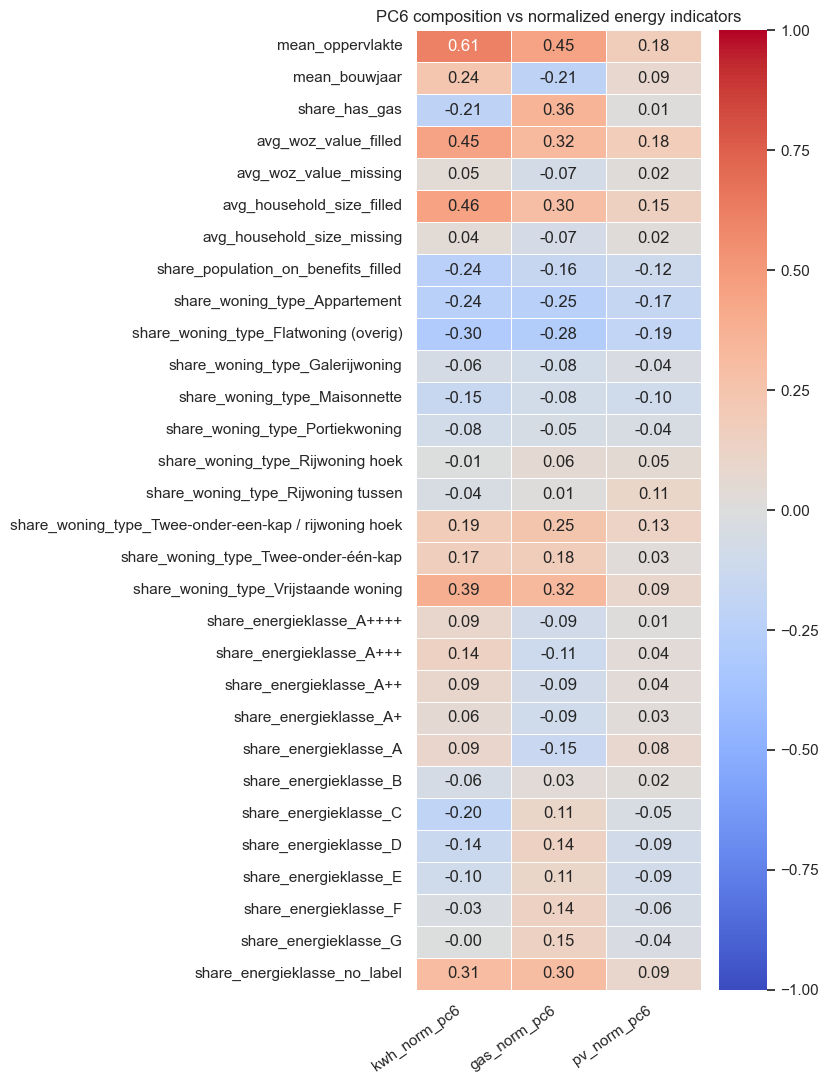

In [44]:
# ----------------------------
# 5.6B PC6 composition vs normalized energy
# ----------------------------

energy_norm_vars = [
    "kwh_norm_pc6",
    "gas_norm_pc6",
    "pv_norm_pc6"
]

composition_vars = [
    "mean_oppervlakte",
    "mean_bouwjaar",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_woz_value_missing",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_woning_type_")
]

composition_vars += [
    c for c in pc6_analysis.columns if c.startswith("share_energieklasse_")
]

corr_block = (
    pc6_analysis[composition_vars + energy_norm_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_norm_vars]
)

plt.figure(figsize=(8, 11))
ax = sns.heatmap(
    corr_block,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(
    energy_norm_vars,
    rotation=35,
    ha="right"
)

plt.title("PC6 composition vs normalized energy indicators")
plt.tight_layout()
plt.show()

### Diagnostic 1: correlation between postcode size and normalized energy

To verify that normalization removed the mechanical influence of postcode size, we examine correlations between the number of dwellings and the normalized energy indicators.

If normalization is successful, these correlations should be reduced substantially relative to those observed for total energy.

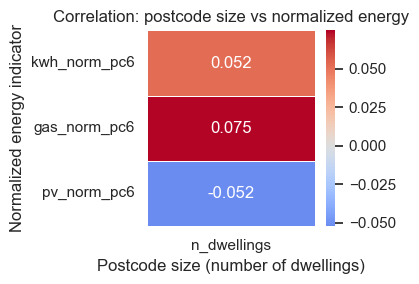

In [45]:
# ----------------------------
# Diagnostic 1: normalized energy vs postcode size
# ----------------------------

norm_vars = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]
size_var = "n_dwellings"

size_corrs = []
for var in norm_vars:
    tmp = pc6_analysis[[size_var, var]].dropna()
    size_corrs.append(tmp.corr(method="spearman").iloc[0, 1])

heatmap_df = pd.DataFrame(size_corrs, index=norm_vars, columns=[size_var])

plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation: postcode size vs normalized energy")
plt.ylabel("Normalized energy indicator")
plt.xlabel("Postcode size (number of dwellings)")
plt.tight_layout()
plt.show()

### Diagnostic 2: regression test

A log-log regression of normalized energy against postcode size checks whether any residual scaling remains after normalization. Slope values near zero and $R^2 \approx 0$ indicate that variation in normalized energy is no longer explained by the number of dwellings.

In [46]:
# ----------------------------
# Diagnostic 2: remaining log-log dependence
# ----------------------------

from scipy.stats import linregress

norm_vars = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]

for var in norm_vars:

    tmp = pc6_analysis.loc[
        (pc6_analysis["n_dwellings"] > 0) &
        (pc6_analysis[var] > 0),
        ["n_dwellings", var]
    ].dropna().copy()

    log_n = np.log(tmp["n_dwellings"])
    log_e = np.log(tmp[var])

    slope, intercept, r, p, se = linregress(log_n, log_e)

    print(f"\n{var}")
    print("log-log slope (should be small):", round(slope, 4))
    print("R²:", round(r**2, 4))


kwh_norm_pc6
log-log slope (should be small): 0.0
R²: 0.0

gas_norm_pc6
log-log slope (should be small): 0.0
R²: 0.0

pv_norm_pc6
log-log slope (should be small): -0.0
R²: 0.0


### Diagnostic 3: comparison between reported total and size-normalized energy

To assess how normalization changes the apparent relationship between postcode composition and energy, we compare Spearman correlations between PC6 composition variables and two energy representations:

1. **Reported total energy**
   - `pc6_kwh_total_2023`
   - `pc6_gasm3_total_2023`
   - `pc6_kwh_productie_total_2023`

2. **Size-normalized energy**
   - `kwh_norm_pc6`
   - `gas_norm_pc6`
   - `pv_norm_pc6`

The number of dwellings is included as an additional row in the comparison to make the role of postcode size explicit. The comparison is carried out using the final composition variables retained after Diagnostic 5.6A.

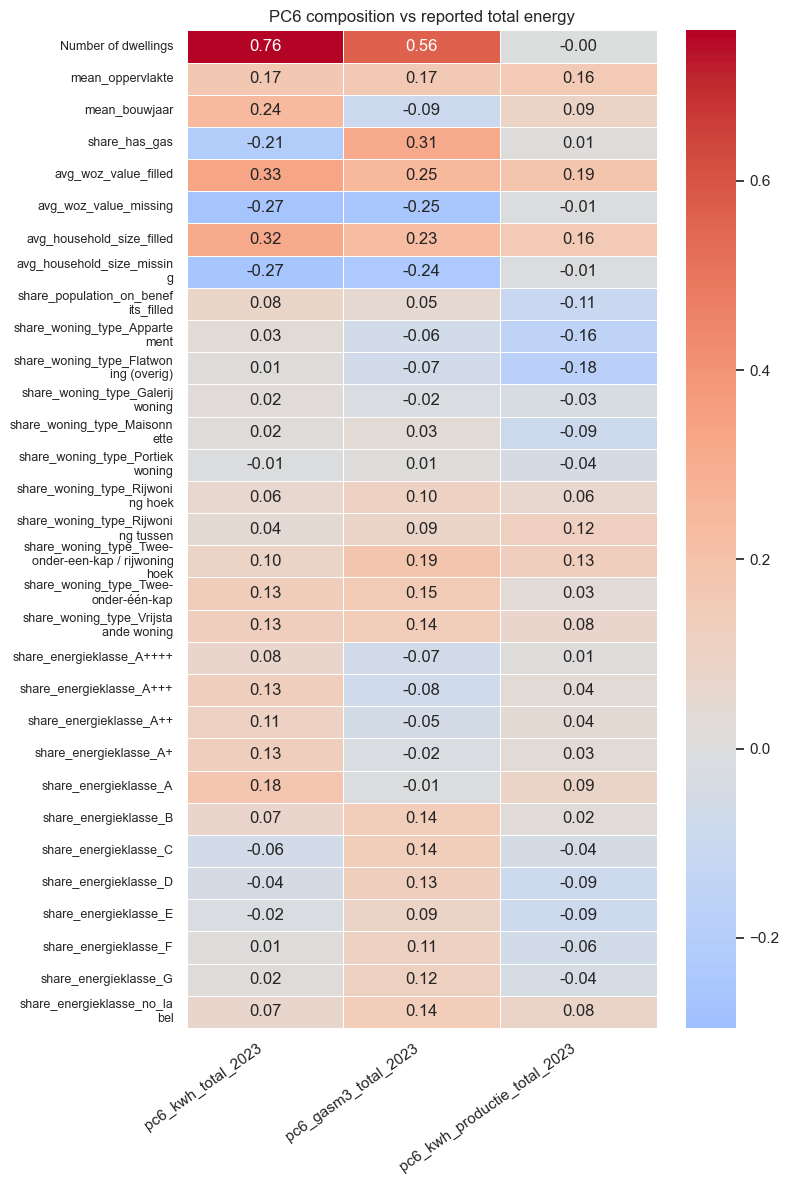

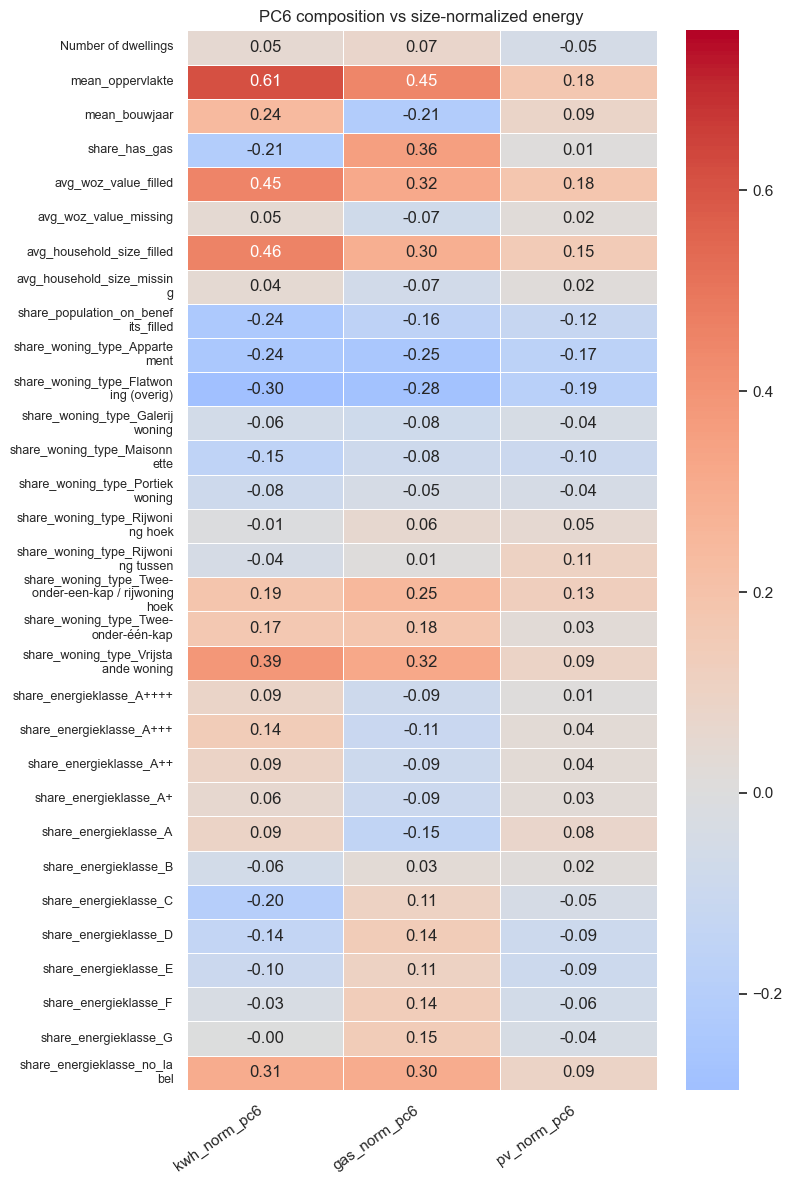

In [47]:
# ----------------------------
# Diagnostic 3: total vs normalized energy (with size row)
# ----------------------------

from textwrap import fill

energy_reported_total = [
    "pc6_kwh_total_2023",
    "pc6_gasm3_total_2023",
    "pc6_kwh_productie_total_2023"
]

energy_normalized = [
    "kwh_norm_pc6",
    "gas_norm_pc6",
    "pv_norm_pc6"
]

composition_vars_compare = [
    "mean_oppervlakte",
    "mean_bouwjaar",
    "share_has_gas",
    "avg_woz_value_filled",
    "avg_woz_value_missing",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

composition_vars_compare += [
    c for c in pc6_analysis.columns if c.startswith("share_woning_type_")
]

composition_vars_compare += [
    c for c in pc6_analysis.columns if c.startswith("share_energieklasse_")
]

rows = ["n_dwellings"] + composition_vars_compare

corr_reported_total = (
    pc6_analysis[rows + energy_reported_total]
    .corr(method="spearman")
    .loc[rows, energy_reported_total]
)

corr_normalized = (
    pc6_analysis[rows + energy_normalized]
    .corr(method="spearman")
    .loc[rows, energy_normalized]
)

rename_map = {"n_dwellings": "Number of dwellings"}
corr_reported_total = corr_reported_total.rename(index=rename_map)
corr_normalized = corr_normalized.rename(index=rename_map)

shared_min = min(
    corr_reported_total.min().min(),
    corr_normalized.min().min()
)

shared_max = max(
    corr_reported_total.max().max(),
    corr_normalized.max().max()
)

wrapped_labels = [fill(label, width=25) for label in corr_reported_total.index]

# Heatmap 1
plt.figure(figsize=(8, 12))
ax = sns.heatmap(
    corr_reported_total,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=shared_min,
    vmax=shared_max,
    linewidths=0.5
)
ax.set_title("PC6 composition vs reported total energy")
ax.set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Heatmap 2
plt.figure(figsize=(8, 12))
ax = sns.heatmap(
    corr_normalized,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=shared_min,
    vmax=shared_max,
    linewidths=0.5
)
ax.set_title("PC6 composition vs size-normalized energy")
ax.set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()

### Interpretation of PC6 energy diagnostics

**Diagnostic 1 – correlation with postcode size**  
Reported total electricity and gas consumption are strongly correlated with the number of dwellings (e.g. electricity $\rho \approx 0.76$, gas $\rho \approx 0.56$), confirming that postcode size is a dominant driver of total energy demand. After scaling-based normalization, these correlations drop close to zero ($\approx 0.05$–$0.07$), indicating that the mechanical effect of postcode size has been largely removed. For PV production, the correlation with postcode size is weak in both cases, suggesting that PV generation is not primarily driven by postcode scale.

**Diagnostic 2 – regression of normalized energy vs postcode size**  
The log-log regressions confirm that normalized energy is largely independent of postcode size, with slopes close to zero and very low explanatory power. This supports the use of scaling-based normalization as an effective way to remove size effects while preserving meaningful variation across postcode areas.

**Diagnostic 3 – composition vs energy correlation matrices**  

The comparison between reported total and size-normalized energy reveals which relationships are driven by postcode size and which reflect structural differences in energy intensity.

**Key observations:**

- **Size-driven relationships disappear after normalization**
  - The number of dwellings shows strong correlation with total energy but negligible correlation with normalized energy.
  - This confirms that normalization successfully removes the mechanical scaling effect of postcode size.

- **Structural drivers become substantially stronger after normalization**
  - Mean floor area: $0.17 \rightarrow 0.61$  
  - Average household size (filled): $0.32 \rightarrow 0.46$  
  - Average WOZ value (filled): $0.33 \rightarrow 0.45$  
  - These increases indicate that:
    - larger dwellings  
    - larger households  
    - higher-value housing  
    are associated with higher **energy use per dwelling**, not merely larger postcode size.

- **Housing typology clearly explains energy intensity**
  - Detached and semi-detached dwelling shares show positive correlations with normalized electricity and gas.
  - Apartment-type dwellings show negative correlations (down to $\approx -0.30$).
  - This reflects structural differences:
    - compact housing → lower energy intensity  
    - low-density housing → higher energy intensity  

- **Direct structural effects remain stable**
  - Share of gas-connected dwellings:
    - Gas: $0.31 \rightarrow 0.36$  
  - This relationship is not driven by postcode size, but reflects actual infrastructure and heating system dependence.

- **Socioeconomic effects weaken but remain meaningful**
  - Share of population on benefits (filled):
    - Electricity: $0.08 \rightarrow -0.24$  
  - After accounting for missingness and removing size effects, the relationship becomes clearly negative but moderate in magnitude.
  - This suggests a real but weaker socioeconomic gradient in energy intensity.

- **Missingness indicators are not interpreted as structural drivers**
  - Binary missing indicators (e.g. for WOZ and household size) are included for regression consistency but are not interpreted in the correlation analysis.
  - They serve as technical controls rather than meaningful composition variables.

**Interpretation:**  

Reported total energy combines two distinct effects:
- postcode size  
- housing and socioeconomic composition  

Normalization removes the size component, revealing that energy intensity is primarily driven by:
- dwelling size  
- household composition  
- housing typology  
- heating infrastructure  

Socioeconomic variables retain explanatory power but are weaker than physical dwelling characteristics. Variables with extreme missingness (such as vacancy rates) are excluded, as they do not provide reliable information on energy intensity.

Overall, these diagnostics confirm that reported total energy is dominated by postcode size, while size-normalized energy reveals meaningful structural differences in residential energy demand. This justifies the use of normalized energy indicators for subsequent regression analysis.

## 6️⃣ PC6-level regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to normalized electricity demand. These earlier analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint influence of multiple housing characteristics simultaneously.

The purpose of this chapter is to estimate statistical models that relate postcode-level normalized electricity demand to the structural and socioeconomic composition of the housing stock. Two objectives are pursued.

First, regression models are used to quantify how average dwelling size, construction year, gas availability, dwelling type composition, energy label composition, and selected CBS socioeconomic variables (age structure, household types, and migration origin shares) are associated with normalized electricity demand across postcode areas.

Second, the predictive performance of the preferred regression specification is evaluated out of sample and compared with a nonlinear machine-learning benchmark. This makes it possible to assess both the interpretability of the regression framework and the potential predictive gains from a more flexible nonlinear method.

The analysis proceeds in six steps:

1. define the regression dataset and model variables, including structural, compositional, and CBS socioeconomic variables  
2. assess multicollinearity among predictors  
3. estimate alternative regression specifications (linear, log-level, log-log)  
4. compare model fit and residual behaviour to select a preferred model  
5. evaluate inference robustness for the preferred model using heteroskedasticity-robust standard errors  
6. assess out-of-sample prediction and compare the preferred regression model with a nonlinear benchmark

This structure ensures analytical coherence. Model specification and selection are addressed first. Diagnostics for inference are applied to the preferred model only. Finally, predictive performance is evaluated using cross-validation.

## 6️⃣ PC6-level regression analysis

The purpose of this chapter is to estimate statistical models that relate postcode-level normalized electricity demand to the structural and socioeconomic composition of the housing stock. Two objectives are pursued:

1. Quantify how average dwelling size, construction year, gas availability, dwelling type composition, energy label composition, and selected CBS socioeconomic variables are associated with normalized electricity demand.  
2. Evaluate predictive performance of the preferred regression specification and compare with a nonlinear benchmark.

The analysis proceeds in six steps:

1. Define the regression dataset and model variables  
2. Assess multicollinearity among predictors  
3. Estimate alternative regression specifications (linear, log-level, log-log)  
4. Compare model fit and residual behaviour to select a preferred model  
5. Evaluate inference robustness using heteroskedasticity-robust standard errors  
6. Assess out-of-sample prediction and compare with a nonlinear benchmark

### 6.1 Regression dataset construction

In this section, we define the regression dataset used for PC6-level electricity consumption analysis. Only postcode areas with positive normalized electricity consumption are included. The dependent variable and explanatory variables are specified, and reference categories for categorical shares are omitted to avoid multicollinearity.

**Dependent variable**:

- `kwh_norm_pc6` — normalized electricity consumption per postcode

**Explanatory variables**:

**Structural averages**
- `mean_oppervlakte` — average dwelling floor area  
- `mean_bouwjaar` — average construction year  

**Infrastructure indicator**
- `share_has_gas` — share of dwellings with a gas connection  

**Composition shares**
- `share_woning_type_*` — postcode-level dwelling type shares  
- `share_energieklasse_*` — postcode-level energy label shares  

**CBS socioeconomic indicators**
- `avg_woz_value_filled` and `avg_woz_value_missing`  
- `avg_household_size_filled` and `avg_household_size_missing`  
- `share_population_on_benefits_filled`  

Reference categories are excluded:

- Dwelling type reference: `share_woning_type_Appartement`  
- Energy label reference: `share_energieklasse_G`

In [48]:
# ----------------------------
# 6.1 Construct regression dataset
# ----------------------------
import statsmodels.api as sm

# Filter positive normalized electricity consumption
reg_data = pc6_analysis[pc6_analysis["kwh_norm_pc6"] > 0].copy()

# Dependent variable
y = reg_data["kwh_norm_pc6"]

# Identify dwelling type and energy label shares
woningtype_cols_full = [c for c in reg_data.columns if c.startswith("share_woning_type_")]
label_cols_full = [c for c in reg_data.columns if c.startswith("share_energieklasse_")]

# CBS socioeconomic variables
cbs_vars = [
    "avg_woz_value_filled",
    "avg_woz_value_missing",
    "avg_household_size_filled",
    "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

# Reference categories
ref_woningtype = "share_woning_type_Appartement"
ref_label = "share_energieklasse_G"

# Exclude reference categories
woningtype_cols = [c for c in woningtype_cols_full if c != ref_woningtype]
label_cols = [c for c in label_cols_full if c != ref_label]

# Construct predictor matrix
X = reg_data[
    ["mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
    + cbs_vars
].copy()

# Add intercept
X = sm.add_constant(X)

# Display info
print("Regression matrix shape:")
print("Observations:", X.shape[0])
print("Predictors:", X.shape[1])
display(X.head())

Regression matrix shape:
Observations: 247049
Predictors: 29


,const,mean_oppervlakte,mean_bouwjaar,share_has_gas,share_woning_type_Flatwoning (overig),share_woning_type_Galerijwoning,share_woning_type_Maisonnette,share_woning_type_Portiekwoning,share_woning_type_Rijwoning hoek,share_woning_type_Rijwoning tussen,...,share_energieklasse_C,share_energieklasse_D,share_energieklasse_E,share_energieklasse_F,share_energieklasse_no_label,avg_woz_value_filled,avg_woz_value_missing,avg_household_size_filled,avg_household_size_missing,share_population_on_benefits_filled
0,1.0,75.615385,1789.923077,0.730769,0.421053,0.0,0.052632,0.0,0.0,0.0,...,0.076923,0.076923,0.153846,0.0000,0.269231,622.0,0,1.6,0,0.0
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.0,0.000000,0.0,0.0,1.0,...,0.000000,0.000000,0.000000,0.0625,0.937500,870.0,0,2.1,0,0.0
2,1.0,58.111111,1975.555556,0.666667,0.500000,0.0,0.250000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0000,0.555556,559.0,0,1.4,0,0.0
3,1.0,85.333333,1818.750000,0.750000,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.166667,0.000000,0.166667,0.0000,0.666667,647.0,0,1.3,0,0.0
4,1.0,83.384615,1673.769231,1.000000,0.714286,0.0,0.142857,0.0,0.0,0.0,...,0.076923,0.000000,0.461538,0.0000,0.461538,623.0,0,1.8,0,0.0


### 6.2 Alternative regression specifications

The regression models estimate how structural housing characteristics and socioeconomic indicators relate to normalized electricity demand at the postcode (PC6) level. The exact functional form of these relationships is not known a priori. For this reason, three alternative Ordinary Least Squares specifications are estimated:

1. Linear model in levels  
2. Log-level model with the dependent variable transformed logarithmically  
3. Log-log model in which both the dependent variable and average floor area are expressed in logarithmic form  

These specifications allow assessment of scale effects, residual structure, and whether transformations improve empirical adequacy while preserving interpretability.

#### 6.2.1 Linear OLS specification

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
\begin{equation*}
\begin{split}
kwh_{norm,pc6} &= \beta_0
+ \beta_1 mean\_oppervlakte_{pc6}
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_woning\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_woz\_value\_missing_{pc6} \\
&\quad + \beta_8 avg\_household\_size\_filled_{pc6}
+ \beta_9 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_{10} share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1$–$\beta_3$ are coefficients on structural and infrastructure variables  
- $\beta_{4j}$ and $\beta_{5k}$ are coefficients on dwelling-type and energy-label shares  
- $\beta_6$–$\beta_{10}$ are coefficients on CBS socioeconomic variables  
- $\varepsilon_{pc6}$ is the error term  

Each coefficient represents the change in normalized electricity demand associated with a one-unit increase in the corresponding explanatory variable, holding the remaining variables constant.

Estimation in levels provides a straightforward, interpretable baseline. Right-skewed dependent variables may require transformations, motivating the alternative specifications.

In [49]:
# ----------------------------
# 6.2.1 Linear OLS specification
# ----------------------------

# Dependent variable (positive consumption only)
y_linear = y.copy()

# Predictor matrix
X_linear = X.copy()

# Estimate Linear OLS
model_linear = sm.OLS(y_linear, X_linear).fit()
print("Linear model (levels) results:")
print(model_linear.summary())


Linear model (levels) results:
                            OLS Regression Results                            
Dep. Variable:           kwh_norm_pc6   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     5536.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:42:52   Log-Likelihood:            -2.1833e+06
No. Observations:              247049   AIC:                         4.367e+06
Df Residuals:                  247020   BIC:                         4.367e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

#### 6.2.2 Log-level OLS specification

The dependent variable $kwh_{norm,pc6}$ is right-skewed, meaning a few postcode areas have substantially higher normalized electricity demand than the majority. Estimating in levels may overweight these observations.

An alternative model transforms the dependent variable using the natural logarithm:

$$
\begin{equation*}
\begin{split}
\log(kwh_{norm,pc6}) &= \beta_0
+ \beta_1 mean\_oppervlakte_{pc6}
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_woning\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_woz\_value\_missing_{pc6} \\
&\quad + \beta_8 avg\_household\_size\_filled_{pc6}
+ \beta_9 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_{10} share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

where:

- $\log(kwh_{norm,pc6})$ is the natural logarithm of normalized electricity demand  
- other variables are as defined in the linear specification  

This specification emphasizes **proportional differences** rather than absolute differences. Only postcode areas with $kwh_{norm,pc6} > 0$ are included.

In [50]:
# ----------------------------
# 6.2.2 Log-level OLS specification
# ----------------------------

# Dependent variable log-transformed
y_log = np.log(y)

# Predictor matrix aligned with positive consumption
X_log = X.copy()

# Estimate Log-level OLS
model_log = sm.OLS(y_log, X_log).fit()
print("Log-level model results:")
print(model_log.summary())

Log-level model results:
                            OLS Regression Results                            
Dep. Variable:           kwh_norm_pc6   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     7711.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:42:52   Log-Likelihood:                -30389.
No. Observations:              247049   AIC:                         6.084e+04
Df Residuals:                  247020   BIC:                         6.114e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

Inspection of the residual behaviour of the log-level specification is also useful for guiding further model development. If systematic structure remains after log-transforming the dependent variable, this may indicate that one or more explanatory variables still enter the model in an empirically restrictive functional form.

#### 6.2.3 Log-log OLS specification with logarithmic floor area

Average dwelling floor area is a key structural characteristic. A linear effect implies that a 10 m² increase has the same marginal association with electricity demand regardless of initial size. This may be too restrictive.

The third model logs both normalized electricity demand and average floor area:

$$
\begin{equation*}
\begin{split}
\log(kwh_{norm,pc6}) &= \beta_0
+ \beta_1 \log(mean\_oppervlakte_{pc6})
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6} \\
&\quad + \sum_j \beta_{4j} share\_woning\_type_{j,pc6} 
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6} \\
&\quad + \beta_6 avg\_woz\_value\_filled_{pc6}
+ \beta_7 avg\_woz\_value\_missing_{pc6} \\
&\quad + \beta_8 avg\_household\_size\_filled_{pc6}
+ \beta_9 avg\_household\_size\_missing_{pc6} \\
&\quad + \beta_{10} share\_population\_on\_benefits\_filled_{pc6}
+ \varepsilon_{pc6}
\end{split}
\end{equation*}
$$

The coefficient $\beta_1$ is interpreted as an **elasticity**:

$$
\begin{equation*}
\begin{split}
\beta_1 &= \frac{\partial \log(kwh_{norm,pc6})}{\partial \log(mean\_oppervlakte_{pc6})}
\end{split}
\end{equation*}
$$

indicating the approximate percentage change in normalized electricity demand associated with a 1% increase in average dwelling floor area, holding all other variables constant.

**Note:** For cross-validation with `sklearn`, `LinearRegression` is used with the same predictors and log-transformed dependent variable.

In [51]:
# ----------------------------
# 6.2.3 Log-log OLS specification
# ----------------------------

# Dependent variable log-transformed
y_loglog = np.log(y)

# Predictor matrix with log-transformed mean_oppervlakte
X_loglog = X.copy()
X_loglog["log_mean_oppervlakte"] = np.log(X_loglog["mean_oppervlakte"])
X_loglog = X_loglog.drop(columns=["mean_oppervlakte"])

# Estimate Log-log OLS
model_loglog = sm.OLS(y_loglog, X_loglog).fit()
print("Log-log model results:")
print(model_loglog.summary())

Log-log model results:
                            OLS Regression Results                            
Dep. Variable:           kwh_norm_pc6   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     7799.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:42:52   Log-Likelihood:                -29733.
No. Observations:              247049   AIC:                         5.952e+04
Df Residuals:                  247020   BIC:                         5.983e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

### 6.3 Comparison and selection of the preferred regression specification

The three candidate specifications are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand.

The comparison is based on three criteria.

**1. Model fit**

Model fit is assessed using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ evaluates explanatory power while accounting for model complexity. AIC and BIC compare models by balancing fit and parsimony, with lower values indicating a more favourable trade-off.

It is important to note that likelihood-based criteria such as AIC and BIC are only directly comparable across models estimated on the same dependent variable. Therefore, AIC and BIC comparisons are valid only between the two log-based specifications. The linear model is included for descriptive comparison of fit and residual behaviour, but its AIC and BIC should not be interpreted as directly comparable to those of the log models.

**2. Residual distribution**

Residual histograms are used to assess whether the specification reduces skewness and the influence of extreme observations.

**3. Residual patterns**

Residuals are plotted against fitted values to examine whether the variance of the residuals remains approximately stable across the prediction range and whether visible systematic misspecification remains.

Taken together, these diagnostics are used to select a preferred regression specification. The preferred model is chosen on the basis of joint evidence rather than a single summary metric.

Model statistics comparison:


,Model,Observations,Adj_R2,AIC,BIC
0,Linear,247049,0.3855,4366733.0,4367035.1
1,Log-level,247049,0.4663,60836.8,61138.9
2,Log-log,247049,0.4691,59524.8,59826.9


Coefficient comparison across models:


,Variable,Linear Coef,Linear SE,Linear t,Linear p,Log-level Coef,Log-level SE,Log-level t,Log-level p,Log-log Coef,Log-log SE,Log-log t,Log-log p
0,const,-7887.948227,320.708786,-24.595361,2.052208e-133,5.132372,0.052648,97.484638,0.000000e+00,3.998807,0.052758,75.794770,0.000000e+00
1,mean_bouwjaar,5.639185,0.167931,33.580340,1.174650e-246,0.001449,0.000028,52.576905,0.000000e+00,0.001309,0.000028,47.456692,0.000000e+00
2,share_has_gas,-1129.826548,13.846690,-81.595425,0.000000e+00,-0.201201,0.002273,-88.514349,0.000000e+00,-0.210137,0.002269,-92.618208,0.000000e+00
3,share_woning_type_Flatwoning (overig),-69.378089,19.742914,-3.514075,4.413664e-04,0.000550,0.003241,0.169801,8.651668e-01,-0.001679,0.003231,-0.519848,6.031699e-01
4,share_woning_type_Galerijwoning,236.759597,60.817249,3.892968,9.905127e-05,0.056008,0.009984,5.609882,2.026802e-08,0.057456,0.009957,5.770178,7.928216e-09
5,share_woning_type_Maisonnette,-343.083759,38.210580,-8.978763,2.756783e-19,-0.023764,0.006273,-3.788500,1.515952e-04,-0.055500,0.006255,-8.873127,7.157875e-19
6,share_woning_type_Portiekwoning,-315.714602,96.657681,-3.266317,1.089712e-03,-0.080970,0.015867,-5.102877,3.347751e-07,-0.074010,0.015826,-4.676413,2.920900e-06
7,share_woning_type_Rijwoning hoek,-291.113237,36.047931,-8.075727,6.737415e-16,-0.002790,0.005918,-0.471433,6.373319e-01,-0.045756,0.005923,-7.725330,1.119803e-14
8,share_woning_type_Rijwoning tussen,-338.423681,17.136078,-19.749191,9.513918e-87,-0.000714,0.002813,-0.253817,7.996371e-01,-0.039159,0.002826,-13.855509,1.223410e-43
9,share_woning_type_Twee-onder-een-kap / rijwoni...,-304.289090,19.105028,-15.927173,4.383289e-57,0.016615,0.003136,5.297500,1.174992e-07,-0.032685,0.003202,-10.209251,1.822814e-24


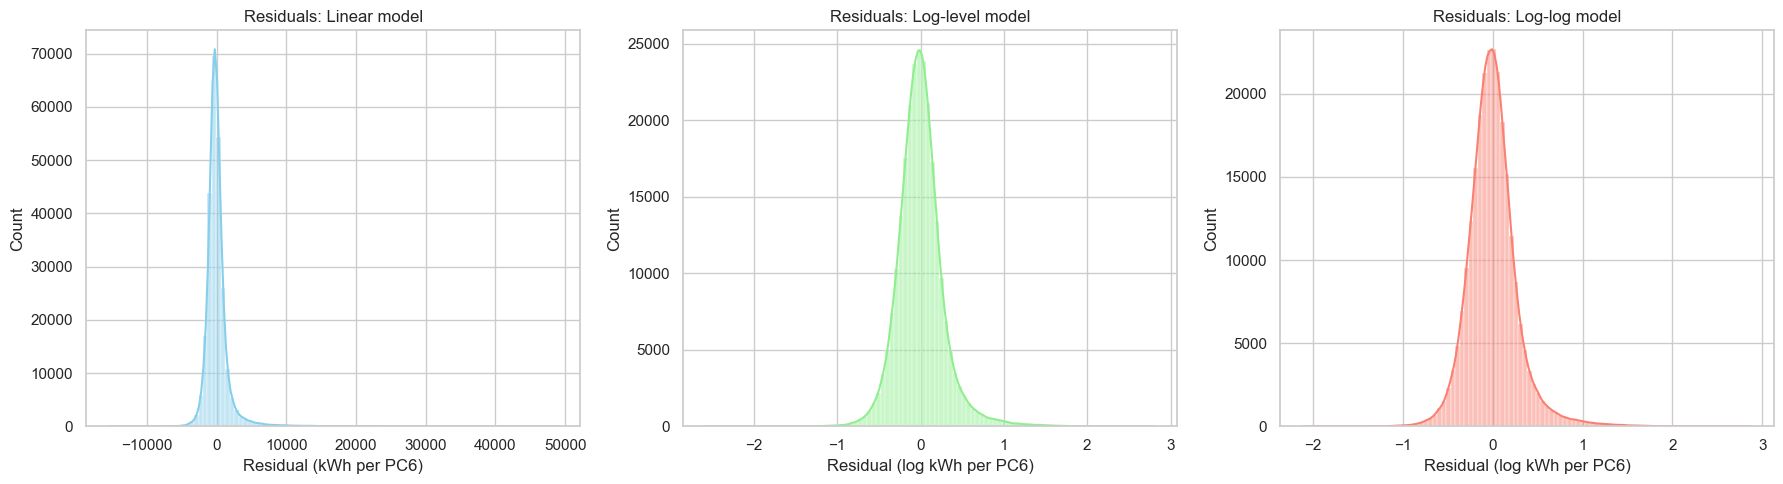

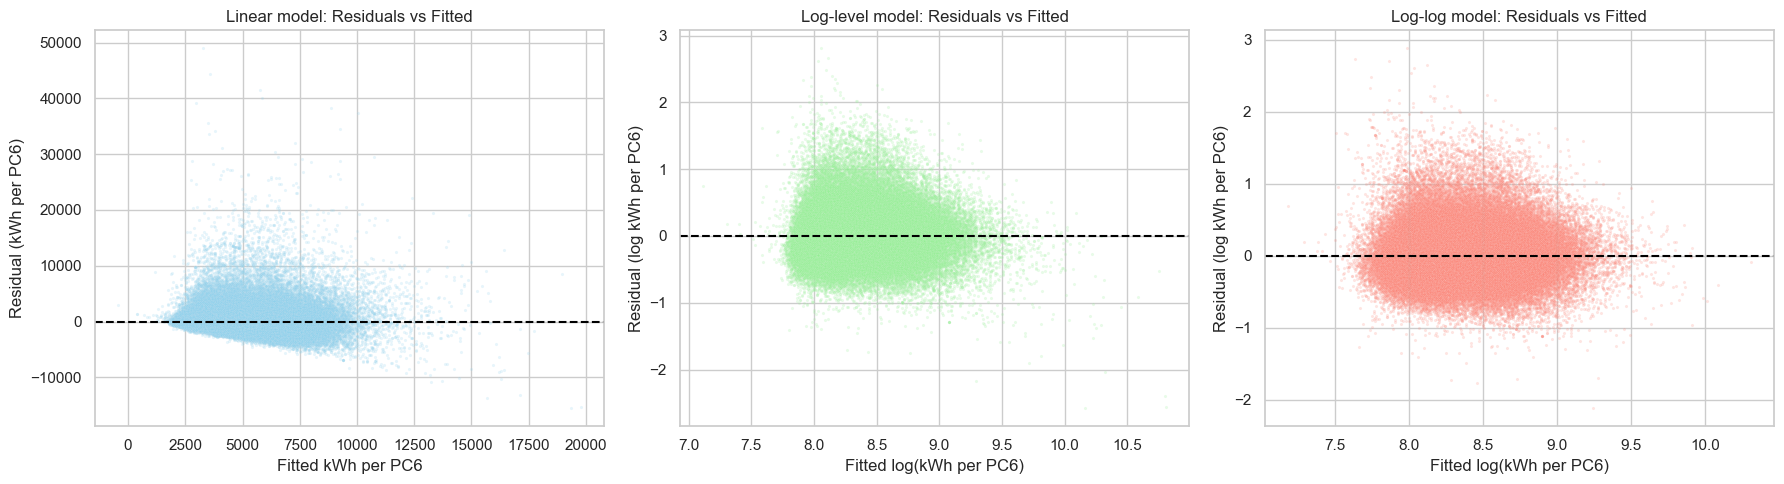

In [52]:
# ----------------------------
# 6.3 Compare regression specifications
# ----------------------------
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Model statistics table
# ----------------------------
comparison_stats = pd.DataFrame({
    "Model": ["Linear", "Log-level", "Log-log"],
    "Observations": [
        int(model_linear.nobs),
        int(model_log.nobs),
        int(model_loglog.nobs)
    ],
    "Adj_R2": [
        round(model_linear.rsquared_adj, 4),
        round(model_log.rsquared_adj, 4),
        round(model_loglog.rsquared_adj, 4)
    ],
    "AIC": [
        round(model_linear.aic, 1),
        round(model_log.aic, 1),
        round(model_loglog.aic, 1)
    ],
    "BIC": [
        round(model_linear.bic, 1),
        round(model_log.bic, 1),
        round(model_loglog.bic, 1)
    ]
})

print("Model statistics comparison:")
display(comparison_stats)

# ----------------------------
# Coefficient comparison table
# ----------------------------
models = {
    "Linear": model_linear,
    "Log-level": model_log,
    "Log-log": model_loglog
}

coef_tables = []

for name, m in models.items():
    df = pd.DataFrame({
        "Variable": m.params.index,
        f"{name} Coef": m.params.values,
        f"{name} SE": m.bse.values,
        f"{name} t": m.tvalues.values,
        f"{name} p": m.pvalues.values
    })
    coef_tables.append(df)

# Merge coefficient tables on Variable
coef_comparison = reduce(lambda left, right: pd.merge(left, right, on="Variable"), coef_tables)

print("Coefficient comparison across models:")
display(coef_comparison)

# ----------------------------
# Residual histograms
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(model_linear.resid, bins=100, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Residuals: Linear model")
axes[0].set_xlabel("Residual (kWh per PC6)")
axes[0].set_ylabel("Count")

sns.histplot(model_log.resid, bins=100, kde=True, ax=axes[1], color="lightgreen")
axes[1].set_title("Residuals: Log-level model")
axes[1].set_xlabel("Residual (log kWh per PC6)")
axes[1].set_ylabel("Count")

sns.histplot(model_loglog.resid, bins=100, kde=True, ax=axes[2], color="salmon")
axes[2].set_title("Residuals: Log-log model")
axes[2].set_xlabel("Residual (log kWh per PC6)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ----------------------------
# Residuals vs fitted values
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    x=model_linear.fittedvalues,
    y=model_linear.resid,
    s=5,
    alpha=0.2,
    ax=axes[0],
    color="skyblue"
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Linear model: Residuals vs Fitted")
axes[0].set_xlabel("Fitted kWh per PC6")
axes[0].set_ylabel("Residual (kWh per PC6)")

sns.scatterplot(
    x=model_log.fittedvalues,
    y=model_log.resid,
    s=5,
    alpha=0.2,
    ax=axes[1],
    color="lightgreen"
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Log-level model: Residuals vs Fitted")
axes[1].set_xlabel("Fitted log(kWh per PC6)")
axes[1].set_ylabel("Residual (log kWh per PC6)")

sns.scatterplot(
    x=model_loglog.fittedvalues,
    y=model_loglog.resid,
    s=5,
    alpha=0.2,
    ax=axes[2],
    color="salmon"
)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Log-log model: Residuals vs Fitted")
axes[2].set_xlabel("Fitted log(kWh per PC6)")
axes[2].set_ylabel("Residual (log kWh per PC6)")

plt.tight_layout()
plt.show()

### 6.3 Model Comparison Interpretation

The three candidate regression specifications are compared based on adjusted R², AIC, BIC, and residual behaviour to determine which functional form best represents postcode-level electricity demand.

| Model | Observations | Adj R² | AIC | BIC |
|-------|-------------|--------|-----|-----|
| Linear | 247,049 | 0.3855 | 4,366,733 | 4,367,035 |
| Log-level | 247,049 | 0.4663 | 60,836.8 | 61,138.9 |
| Log + log(area) | 247,049 | 0.4691 | 59,524.8 | 59,826.9 |

**Notes on metrics:**
- **Adjusted R²**: proportion of variance explained by the model, adjusted for the number of predictors; higher values indicate better explanatory power.  
- **AIC (Akaike Information Criterion)**: measures model fit while penalizing for extra predictors; lower values indicate a better balance between fit and model complexity.  
- **BIC (Bayesian Information Criterion)**: similar to AIC but penalizes complexity more strongly; lower values indicate a more preferred model.

**Residual distributions:**
- **Linear model:** highly skewed; residuals spread more at larger fitted values, indicating underestimation for high-consumption PC6s.  
- **Log-level model:** more symmetric residuals; spread reduced, showing log-transform helps with heteroskedasticity.  
- **Log + log(area) model:** similar to Log-level; slight tightening for larger fitted values, indicating modest improvement.

**Coefficient patterns (examples):**
- **Floor area:**  
  - Linear: `mean_oppervlakte = 0.0026` → each extra m² increases electricity slightly.  
  - Log + log(area): `log_mean_oppervlakte = 0.3853` → 1% increase in floor area increases electricity by ~0.39%.  
- **Construction year:** positive; newer dwellings consume slightly more electricity.  
- **Gas connection:** negative (`share_has_gas ≈ -0.210`) → more gas-connected homes reduce electricity.  
- **Energy labels:** efficient labels (A, B, C) reduce consumption; e.g., `share_energieklasse_B = -0.323` → 10% more B-labeled dwellings reduces demand ~3%.  
- **No-label dwellings:** lower consumption than reference (G).

**Residual vs fitted plots:**
- **Linear model:** increasing spread with fitted values → heteroskedasticity.  
- **Log models:** flatter clouds → variance more uniform; log-transform improves stability.

**Overall assessment:**
1. **Model fit:** Log + log(area) slightly better than Log-level (Adj R², AIC, BIC).  
2. **Interpretability:** Log + log(area) allows intuitive multiplicative interpretation.  
3. **Descriptive insight:** Larger/newer dwellings consume more; gas reduces demand; efficient labels reduce electricity.  
4. **Residual behaviour:** Log-transform reduces skewness and variance heterogeneity.  
5. **Caution:** Some multicollinearity among energy labels; coefficients indicate patterns, not strict causal effects.

**Conclusion:**  
- **Linear model:** easy to interpret, poorly captures high-demand PC6s.  
- **Log-level model:** improves residual behaviour, interpretable on proportional scale.  
- **Log + log(area) model:** preferred for interpretive clarity and slightly better predictive performance, especially for large/high-consumption PC6s.

### 6.4 Inference robustness of the preferred regression model

A key assumption of conventional Ordinary Least Squares (OLS) inference is **homoskedasticity**, meaning that the variance of the regression residuals is constant across observations:

$$
Var(\varepsilon_{pc6} \mid X_{pc6}) = \sigma^2
$$

If this assumption is violated, OLS coefficient estimates remain unbiased, but the **standard errors (SE)** may be unreliable. Consequently, t-statistics, p-values, and confidence intervals computed under conventional OLS may be misleading.

In the following sub-sections, we apply complementary approaches to diagnose and correct for heteroskedasticity, ensuring valid inference for our preferred regression model (log-log specification with logarithmic floor area and only positive electricity consumption).

### 6.4.1 Breusch-Pagan (BP) test

The **Breusch-Pagan test** is used to detect whether the variance of regression residuals depends on the explanatory variables. It tests the key OLS assumption of **homoskedasticity**:

$$
Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
$$

where $X_1, X_2, \dots, X_k$ are all predictor variables in the model. If this assumption fails, standard errors computed by conventional OLS may be biased, which affects t-values, p-values, and confidence intervals.

#### Hypotheses

- **Null hypothesis ($H_0$):** Residual variance is constant across observations  
  $$
  H_0: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = \sigma^2
  $$
- **Alternative hypothesis ($H_1$):** Residual variance depends on one or more predictors  
  $$
  H_1: Var(\varepsilon_{pc6} \mid X_1, X_2, \dots, X_k) = f(X_1, X_2, \dots, X_k)
  $$

#### Breusch-Pagan statistics

1. **Lagrange Multiplier (LM) statistic:**  
   - Measures the overall deviation from constant variance by regressing squared residuals on all predictors.  
   - Large LM values indicate stronger evidence against $H_0$.

2. **LM p-value:**  
   - Probability of observing an LM statistic as extreme as the one calculated, **assuming $H_0$ is true**.  
   - A small LM p-value (e.g., < 0.05) indicates that residual variance likely depends on the predictors.

3. **F-value:**  
   - Obtained by running an auxiliary F-test using the same regression of squared residuals on predictors.  
   - Conceptually, it is another way to measure how strongly residual variance is explained by the predictors.  
   - Larger F-values signal stronger evidence of heteroskedasticity.

4. **F p-value:**  
   - Probability of observing the F-value under $H_0$.  
   - A small F p-value also indicates heteroskedasticity.

#### How to interpret

1. If **LM p-value or F p-value is very small**, we reject the null of homoskedasticity.  
2. This suggests that conventional OLS standard errors may be **underestimated or overestimated**, meaning t-values and confidence intervals could be misleading.  
3. In such a situation, heteroskedasticity-robust standard errors (HC3) are recommended to obtain **reliable inference**.

In [53]:
# ----------------------------
# 6.4.1 Breusch-Pagan test
# ----------------------------
from statsmodels.stats.diagnostic import het_breuschpagan

# Use residuals and predictors from preferred log-log model
residuals_pref = model_loglog.resid
exog_pref = model_loglog.model.exog

# Run Breusch-Pagan test
bp_test = het_breuschpagan(residuals_pref, exog_pref)

# Create a tidy DataFrame with LM and F statistics
bp_results = pd.DataFrame({
    "Statistic": ["Lagrange multiplier", "LM p-value", "F-value", "F p-value"],
    "Value": bp_test
})

# Round for readability
bp_results["Value"] = bp_results["Value"].round(4)

# Display results
display(bp_results)

,Statistic,Value
0,Lagrange multiplier,13712.6256
1,LM p-value,0.0000
2,F-value,518.4564
3,F p-value,0.0000


### 6.4.1 Breusch-Pagan (BP) Test Interpretation

The Breusch-Pagan test checks whether the variance of residuals depends on the predictors in the preferred log-log model (logarithmic floor area included). Heteroskedasticity would imply that standard OLS standard errors are unreliable.

**BP test results:**

| Statistic               | Value      |
|-------------------------|-----------|
| Lagrange multiplier     | 13,712.63 |
| LM p-value              | 0.0000    |
| F-value                 | 518.46    |
| F p-value               | 0.0000    |

**Interpretation:**

1. **LM p-value = 0.0000** and **F p-value = 0.0000** indicate very strong evidence against the null hypothesis of constant residual variance.  
2. Residual variance clearly depends on one or more predictors, confirming heteroskedasticity.  
3. This suggests that conventional OLS standard errors may be biased, potentially misleading t-values, p-values, and confidence intervals.  
4. To obtain reliable inference, heteroskedasticity-robust standard errors (HC3) are recommended for this preferred model (see Section 6.4.2).

### 6.4.2 HC3 Robust Standard Errors

HC3 robust standard errors are used to provide valid inference when residual variance is not constant (heteroskedasticity). They allow us to identify which predictors remain statistically reliable even when conventional OLS assumptions are violated.

Key points:

- Coefficients remain **unchanged**; only standard errors (SE), z-values, p-values, and confidence intervals are adjusted.
- **z-values** replace OLS t-values under HC3:

$$
z_j = \frac{\hat{\beta}_j}{SE_j^{HC3}}
$$

- **SE increase:** If residual variance is not constant, HC3 SE will typically be larger than conventional OLS SE.
- **Adjusted p-values:** Larger SEs yield more conservative p-values, ensuring reliable inference.

#### HC3 statistics explanation

1. **coef:** Estimated coefficient from the OLS regression (unchanged under HC3).  
2. **SE (OLS):** Standard error assuming homoskedasticity.  
3. **t-value (OLS):** OLS t-value (coef divided by SE).  
4. **SE (HC3):** Heteroskedasticity-robust standard error.  
5. **z-value (HC3):** Robust z-value (coef divided by SE_HC3), used to assess significance under heteroskedasticity.  
6. **p-values:** Probability of observing a coefficient as extreme as the one estimated under the null hypothesis. HC3 adjusts them to account for heteroskedasticity.

#### Why use HC3?

- Conventional OLS assumes constant residual variance. If this assumption is violated, standard errors may be underestimated, making coefficients appear more statistically significant than they really are.
- HC3 adjusts the standard errors to provide **reliable inference** without changing the coefficient estimates themselves.
- Particularly relevant after detecting heteroskedasticity with the Breusch-Pagan test (Section 6.4.1).

#### HC3 example:

| Variable | coef | SE (OLS) | z/t (OLS) | SE (HC3) | z (HC3) |
|----------|------|-----------|-----------|----------|---------|
| share_energieklasse_B      | -0.3233 | 0.0105 | -30.73 | 0.0158 | -20.51 |


In [54]:
# ----------------------------
# 6.4.2 HC3 robust standard errors
# ----------------------------

# Re-estimate the preferred log-log model with HC3 robust SE
model_loglog_robust = sm.OLS(y_loglog, X_loglog).fit(cov_type="HC3")

# Show full summary (optional)
print(model_loglog_robust.summary())

# Compare OLS vs HC3 SE and p-values
coef_comparison_hc3 = pd.DataFrame({
    "coef_OLS": model_loglog.params,
    "se_OLS": model_loglog.bse,
    "pval_OLS": model_loglog.pvalues,
    "coef_HC3": model_loglog_robust.params,
    "se_HC3": model_loglog_robust.bse,
    "pval_HC3": model_loglog_robust.pvalues
})

# Round numbers for readability
coef_comparison_hc3 = coef_comparison_hc3.round({
    "coef_OLS": 4,
    "se_OLS": 4,
    "coef_HC3": 4,
    "se_HC3": 4,
    "pval_OLS": 6,
    "pval_HC3": 6
})

# Optional: sort by HC3 SE descending
coef_comparison_hc3 = coef_comparison_hc3.sort_values("se_HC3", ascending=False)

# Display table
display(coef_comparison_hc3)

                            OLS Regression Results                            
Dep. Variable:           kwh_norm_pc6   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     6237.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:42:56   Log-Likelihood:                -29733.
No. Observations:              247049   AIC:                         5.952e+04
Df Residuals:                  247020   BIC:                         5.983e+04
Df Model:                          28                                         
Covariance Type:                  HC3                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

,coef_OLS,se_OLS,pval_OLS,coef_HC3,se_HC3,pval_HC3
const,3.9988,0.0528,0.000000,3.9988,0.0686,0.000000
share_energieklasse_A++++,-0.1787,0.0191,0.000000,-0.1787,0.0273,0.000000
share_energieklasse_A++,-0.1832,0.0181,0.000000,-0.1832,0.0264,0.000000
share_energieklasse_F,-0.1453,0.0151,0.000000,-0.1453,0.0216,0.000000
share_energieklasse_A+++,-0.0252,0.0144,0.081135,-0.0252,0.0205,0.219797
share_energieklasse_A+,-0.3855,0.0139,0.000000,-0.3855,0.0193,0.000000
share_woning_type_Portiekwoning,-0.0740,0.0158,0.000003,-0.0740,0.0177,0.000028
share_energieklasse_E,-0.1954,0.0123,0.000000,-0.1954,0.0177,0.000000
share_energieklasse_D,-0.2693,0.0110,0.000000,-0.2693,0.0163,0.000000
share_energieklasse_A,-0.3191,0.0103,0.000000,-0.3191,0.0158,0.000000


### 6.4.2 Interpretation of HC3 Robust Estimation Results

This section compares the results of the **Preferred Log-Log Model** using standard OLS versus **HC3 Robust Standard Errors**. The HC3 adjustment ensures that inference remains valid in the presence of heteroskedasticity.

#### 1. Stability of Point Estimates
The **coefficients (coef)** are unchanged between OLS and HC3.  
- Example: `log_mean_oppervlakte = 0.3853` and `share_energieklasse_B = -0.3233` are identical.  
- This confirms that heteroskedasticity affects the **uncertainty** of estimates, but not the **direction or magnitude** of the relationships.

#### 2. Standard Error Inflation and Inference Reliability
- Across most variables, standard errors (SE) increase under HC3.  
- **Typical increase:** 30–50% in non-control variables.  
  - Constant: SE 0.0528 → 0.0686  
  - `share_energieklasse_A++++`: SE 0.0191 → 0.0273  
  - `share_energieklasse_B`: SE 0.0105 → 0.0158  
  - `share_has_gas`: SE 0.0023 → 0.0030  
- **Robust significance:** Major predictors (`log_mean_oppervlakte`, `share_has_gas`, most energy labels) remain highly significant ($p < 0.001$), confirming robustness to heteroskedasticity.

#### 3. Key Changes in Significance ("Borderline" Cases)
The HC3 adjustment highlights variables that lose significance or move further from significance:  
- `share_energieklasse_A+++`: p-value rises from 0.081 → 0.220 → no longer statistically reliable.  
- `share_woning_type_Twee-onder-één-kap`: p-value 0.103 → 0.150 → remains non-significant.  
- `share_woning_type_Flatwoning (overig)`: p-value 0.603 → 0.689 → continues to show no meaningful effect.  

#### 4. Interpretation of Top Drivers
- **Floor Area Elasticity:** `log_mean_oppervlakte = 0.3853` → 1% increase in mean floor area increases normalized electricity demand by ~0.38%, holding all else constant.  
- **Household Size:** `avg_household_size_filled = 0.1285` → SE barely changes (0.0013 → 0.0014), showing household size is a stable predictor.  
- **Gas Connection:** `share_has_gas = -0.2101` → a 10% higher share of gas-connected dwellings reduces electricity demand by ~2.1%, robust under HC3.  
- **Energy Labels:** Most labels remain significant; high-end labels (A+++, A++++), while negative, show slightly larger SEs under HC3.

#### 5. Confidence Intervals under HC3
For each coefficient $j$:

$$
CI_j = \hat{\beta}_j \pm 1.96 \cdot SE_j^{HC3}
$$

These intervals reflect **conservative uncertainty** estimates that account for heteroskedasticity.

#### Conclusion
- HC3 confirms the **statistical reliability** of the main drivers of electricity demand.  
- Coefficients are unchanged, but SE increases make borderline predictors less likely to appear significant.  
- Analysts should focus on **robust predictors** like `log_mean_oppervlakte`, `share_has_gas`, and most energy labels, while treating borderline effects (e.g., A+++) with caution.

### 6.5 Multicollinearity assessment

Before estimating the regression models, it is necessary to assess whether the explanatory variables are strongly collinear. Multicollinearity does not bias the fitted values of an Ordinary Least Squares model, but it can inflate the variance of the estimated coefficients and make coefficient interpretation unstable.

This issue is expected in compositional data, where postcode-level dwelling-type and energy-label shares sum to one and are partially dependent.

To evaluate the severity of multicollinearity, **Variance Inflation Factors (VIF)** are computed. The VIF for predictor $x_j$ is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is obtained by regressing $x_j$ on all other predictors.  

Rules of thumb:

- VIF < 5 → limited multicollinearity  
- 5 ≤ VIF < 10 → moderate multicollinearity  
- VIF ≥ 10 → potentially problematic multicollinearity

**Additional notes for this analysis:**

For interpretation, we focus on non-control variables (share_has_gas and energy-label shares), as control variables like floor area and dwelling-type shares are expected to have high VIFs due to compositional structure and log transformations.

In [55]:
# ----------------------------
# 6.5 VIF diagnostics for non-control variables
# ----------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the X matrix of the preferred log-log model
X_vif = X_loglog.copy()

# List of non-control variables
non_control_vars = ["share_has_gas"] + [c for c in X_vif.columns if "share_energieklasse" in c]

# Compute VIFs for non-control variables only
vif_noncontrol = pd.DataFrame({
    "Variable": non_control_vars,
    "VIF": [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(v)) for v in non_control_vars]
})

# Round for readability and sort descending
vif_noncontrol = vif_noncontrol.round(2).sort_values("VIF", ascending=False)

display(vif_noncontrol)

,Variable,VIF
5,share_energieklasse_A,24.90
11,share_energieklasse_no_label,24.17
7,share_energieklasse_C,14.58
6,share_energieklasse_B,9.71
8,share_energieklasse_D,6.04
9,share_energieklasse_E,4.00
10,share_energieklasse_F,2.94
2,share_energieklasse_A+++,2.33
4,share_energieklasse_A+,2.26
3,share_energieklasse_A++,1.59


In [59]:
### 6.5.2 VIF Comparison Table (Non-Control Variables Across Models)

models_X = {
    "Linear": X_linear,
    "Log-level": X_log,
    "Log-log": X_loglog,
    "Log-log HC3": X_loglog  # Identical matrix, but ensures a complete table
}

vif_dict = {var: {} for var in non_control_vars}

for model_name, X_model in models_X.items():
    for var in non_control_vars:
        if var in X_model.columns:
            idx = X_model.columns.get_loc(var)
            vif_j = variance_inflation_factor(X_model.values, idx)
            vif_dict[var][model_name] = round(vif_j, 2)

# Convert to DataFrame (rows = variables, columns = models)
vif_wide_df = pd.DataFrame.from_dict(vif_dict, orient="index").reset_index()
vif_wide_df.rename(columns={"index": "Variable"}, inplace=True)

# Optional: sort variables alphabetically
vif_wide_df = vif_wide_df.sort_values("Variable").reset_index(drop=True)

display(vif_wide_df)

,Variable,Linear,Log-level,Log-log,Log-log HC3
0,share_energieklasse_A,24.85,24.85,24.90,24.90
1,share_energieklasse_A+,2.26,2.26,2.26,2.26
2,share_energieklasse_A++,1.59,1.59,1.59,1.59
3,share_energieklasse_A+++,2.33,2.33,2.33,2.33
4,share_energieklasse_A++++,1.48,1.48,1.48,1.48
5,share_energieklasse_B,9.70,9.70,9.71,9.71
6,share_energieklasse_C,14.55,14.55,14.58,14.58
7,share_energieklasse_D,6.03,6.03,6.04,6.04
8,share_energieklasse_E,4.00,4.00,4.00,4.00
9,share_energieklasse_F,2.94,2.94,2.94,2.94


### 6.5 Interpretation of Variance Inflation Factors (VIF)

The VIF analysis quantifies multicollinearity among explanatory variables in the regression models. Since multicollinearity can inflate the standard errors of coefficients, it is important to check especially the **non-control variables** (`share_has_gas` and `energy label shares`) to ensure their interpretations remain reliable.

#### Key observations from the VIF results:

1. **Interpretation of VIF values:**
- Values **< 5** → limited multicollinearity (e.g., `share_has_gas`, `A+`, `A++`, `A++++`, `E`, `F`).  
- Values **5–10** → moderate multicollinearity (`B`, `D`).  
- Values **> 10** → strong multicollinearity (`A`, `C`, `no_label`).  
- These high VIFs are expected for energy label shares because shares are compositional (they sum to 1), and one category is omitted as the reference.  

2. **Comparison across models:**  
- VIFs **do not change** between Linear, Log-level, Log-log, and Log-log HC3.  
- This indicates that adding log transformations or using robust standard errors does **not affect the structural relationships** among `energy label` shares or `share_has_gas`.  
- The VIF table we present only includes **non-control variables** (`share_has_gas` and energy label shares) because these are the variables we interpret substantively.  
- Control variables (e.g., floor area, household size) are included in the regression, so their collinearity is reflected in the model, but we deliberately omit them from the VIF table for clarity.  
- Their high VIFs are expected due to compositional relationships or correlation with other predictors, but we do not interpret their coefficients substantively, so we do not report them.  
- This approach allows us to demonstrate that the **interpreted variables are not affected by problematic multicollinearity**, while still acknowledging that the model accounts for controls.

3. **Practical conclusion:**  
- The non-control variables have acceptable VIFs for interpretation, except for `share_energieklasse_A`, `C`, and `no_label`, where multicollinearity is expected due to compositional constraints.  
- Analysts should interpret these coefficients cautiously, but the sign and relative magnitude remain meaningful.  
- Overall, VIF analysis shows that most non-control predictors have acceptable multicollinearity (VIF < 10), while a few energy-label shares exhibit higher VIFs due to compositional dependence, but this is expected and does not compromise interpretation of key relationships.

### 6.6 Out-of-sample predictive assessment of the preferred regression model

The previous sections evaluated model adequacy primarily using in-sample criteria such as Adjusted $R^2$, AIC, BIC, and residual diagnostics. These metrics are useful for comparing candidate specifications, but they do not directly indicate how well the preferred model generalizes to unseen data.

To assess out-of-sample predictive performance, the preferred regression specification is evaluated using **10-fold cross-validation**. In this procedure, the dataset is partitioned into ten approximately equal folds. For each iteration, the model is trained on nine folds and evaluated on the remaining fold. This process is repeated until each fold has served once as the validation sample.

The evaluation metric is the **mean squared error (MSE)**:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:

- $y_i$ is the observed value  
- $\hat{y}_i$ is the predicted value  
- $n$ is the number of validation observations

Because the preferred regression model is estimated in log space, the resulting cross-validation error is also measured in log space.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

**What MSE represents:**  
- MSE is the **average squared difference between predicted and observed values** (here in log-space).
- Example:  
  - MSE ≈ 0.25 → average squared log-error is 0.25.  
    Translating to approximate percentage differences (small errors approximation), this corresponds roughly to **√0.25 = 0.5 → 50% average relative error in predicted electricity demand**.  

To provide a reference point for interpretation, the regression model is compared with a **naive baseline predictor (dummy model)**. This dummy model ignores all explanatory variables and simply predicts the **mean value** of the dependent variable ($\log(\text{kWh per PC6})$) for every postcode. Any reduction in MSE achieved by the preferred model relative to this baseline demonstrates that it captures meaningful variation in electricity consumption beyond the overall average, validating its predictive capability.

In [60]:
# ----------------------------
# 6.6 Out-of-sample predictive assessment
# ----------------------------
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Setup 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

y_true = []
y_pred = []

for train_index, test_index in kf.split(X_loglog):
    X_train, X_test = X_loglog.iloc[train_index], X_loglog.iloc[test_index]
    y_train, y_test = y_loglog.iloc[train_index], y_loglog.iloc[test_index]
    
    # Fit OLS model on training fold
    model = sm.OLS(y_train, X_train).fit()
    
    # Predict on test fold
    y_pred_fold = model.predict(X_test)
    
    y_true.extend(y_test)
    y_pred.extend(y_pred_fold)

# Compute MSE
mse_loglog = mean_squared_error(y_true, y_pred)
print(f"10-fold CV MSE (log-log OLS): {mse_loglog:.6f}")

# Baseline (mean predictor)
baseline_pred = np.mean(y_loglog)
mse_baseline = mean_squared_error(y_loglog, [baseline_pred]*len(y_loglog))
print(f"Baseline MSE (mean predictor): {mse_baseline:.6f}")

10-fold CV MSE (log-log OLS): 0.074518
Baseline MSE (mean predictor): 0.140327


### Interpretation of Cross-Validation Results

The 10-fold cross-validation evaluates how well the preferred log-log regression model generalizes to unseen data, using **mean squared error (MSE)** as the metric.  

**MSE Interpretation:**  
- MSE is the **average squared difference between predicted and observed values** in log-space:
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$
- Results:  
  - **Baseline dummy model:** MSE ≈ 0.140 → average squared log-error is 0.140.  
    Translating to approximate percentage differences (small errors approximation), this corresponds roughly to **√0.140 ≈ 0.374 → ~37% average relative error in predicted electricity demand**.  
  - **Log-log regression:** MSE ≈ 0.075 → √0.075 ≈ 0.274 → ~27% average relative error.  
- This illustrates that the regression reduces prediction errors substantially compared to the naive baseline.

**Key takeaways:**  

1. **Comparison with baseline:**  
   - The dummy baseline always predicts the mean log electricity consumption, ignoring postcode variation.  
   - The log-log regression model’s lower MSE shows it successfully models systematic differences across postcode areas, rather than just reproducing the mean.

2. **Practical interpretation:**  
   - Out-of-sample, the model predicts electricity consumption more accurately.  
   - The reduction in MSE (~0.140 → 0.075) demonstrates that the log-log model captures real structural patterns (floor area, building age, gas connection, dwelling type, energy labels).

3. **Caveats:**  
   - MSE is computed in **log-space**, so small log errors can correspond to larger deviations in kWh; interpret absolute electricity predictions with caution.  
   - Cross-validation assesses predictive accuracy only; coefficient inference still relies on the **HC3-adjusted standard errors** from the preferred model.

### 6.7 Nonlinear benchmark: Random Forest

While the preferred regression model captures systematic relationships between dwelling characteristics and electricity consumption, it assumes an additive and relatively structured functional form. To check whether more flexible, nonlinear patterns exist in the data, we estimate a **Random Forest regression model** as a benchmark.

Random Forest is an ensemble method that builds multiple decision trees on bootstrap samples of the data and averages their predictions. This allows it to capture:

- Nonlinear relationships between predictors and electricity consumption  
- Interactions between variables automatically  
- Threshold effects or complex patterns without manual specification

**Why use a nonlinear benchmark:**  
- The OLS log-log model assumes linearity on the log-log scale, which may miss higher-order interactions or nonlinearities in dwelling composition.  
- Random Forests provide a flexible, non-parametric alternative to check whether additional predictive power is available.  
- This benchmark is **purely predictive**; it does not produce interpretable coefficients.

To prevent the benchmark from being sensitive to arbitrary parameter choices, we perform a **small hyperparameter grid search**:

- `n_estimators = [100, 200]`: the number of trees in the forest. A larger number reduces variance but increases computation time; 100–200 trees provide a good tradeoff for speed and stability.  
- `max_depth = [10, 20, None]`: the maximum depth of each tree. Smaller depth avoids overfitting, while `None` allows trees to grow fully. These values cover shallow, medium, and unrestricted trees to test flexibility without overcomplicating tuning.

**Evaluation procedure:**  

- The Random Forest model is evaluated using **10-fold cross-validation**, the same procedure as the log-log OLS model. This ensures predictive performance is compared on the same basis.  
- The scoring metric is **mean squared error (MSE)** in log-space:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

- For reference, the Random Forest MSE can be compared to the **log-log OLS 10-fold CV MSE** and the **baseline mean predictor**.  
- A reduction in MSE relative to the OLS model indicates that nonlinearities or interactions captured by the Random Forest improve out-of-sample predictions.

**Limitations:**  

- Random Forests do not provide directly interpretable coefficients; effects cannot be assigned to individual predictors as in regression.  
- The method is computationally heavier than OLS, especially with expanded grids and large datasets.  
- Overfitting is mitigated via cross-validation and grid search, but small hyperparameter choices can still bias predictive performance.

**Practical usage:**  

- Compare the Random Forest CV MSE to the preferred OLS log-log CV MSE to assess whether additional nonlinear structure exists in the data.  
- Use the benchmark primarily for predictive validation rather than explanatory insights.  
- This analysis complements the regression diagnostics (HC3 SE, VIF) by confirming whether the structural relationships captured in OLS are sufficient to predict electricity demand accurately.

In [62]:
# ----------------------------
# 6.7 Random Forest benchmark consistent with preferred log-log OLS
# ----------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_score

reg_data_log = reg_data.copy()

# 1. Ensure log-transformed variables exist
reg_data_log["log_kwh_norm_pc6"] = np.log(reg_data_log["kwh_norm_pc6"])
reg_data_log["log_mean_oppervlakte"] = np.log(reg_data_log["mean_oppervlakte"])

# 2. Construct predictors (FIXED: Added CBS variables for a fair comparison)
cbs_vars = [
    "avg_woz_value_filled", "avg_woz_value_missing",
    "avg_household_size_filled", "avg_household_size_missing",
    "share_population_on_benefits_filled"
]

X_rf = reg_data_log[
    ["log_mean_oppervlakte", "mean_bouwjaar", "share_has_gas"] 
    + woningtype_cols 
    + label_cols 
    + cbs_vars
].copy()

y_rf = reg_data_log["log_kwh_norm_pc6"].copy()

# 3. Calculate OLS Cross-Validation (FIXED: Defining scores_cv first)
# We use LinearRegression() here as the sklearn equivalent of your OLS model
ols_sk = LinearRegression()
scores_cv = cross_val_score(
    ols_sk, X_rf, y_rf, cv=10, scoring="neg_mean_squared_error", n_jobs=-1
)

# 4. Random Forest Hyperparameter Tuning
param_grid_expanded = {
    "n_estimators": [20, 50, 100, 200],
    "max_depth": [5, 10, 15, None]
}

rf = RandomForestRegressor(random_state=0)

grid_exp = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_expanded,
    cv=3, 
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_exp.fit(X_rf, y_rf)
rf_model_exp = grid_exp.best_estimator_
print("Best RF parameters from expanded grid:", grid_exp.best_params_)

# 5. 10-fold cross-validation of the optimized RF model
scores_rf_exp = cross_val_score(
    rf_model_exp, X_rf, y_rf, cv=10, scoring="neg_mean_squared_error", n_jobs=-1
)

# 6. Final Comparison Table
rf_results_exp = pd.DataFrame({
    "Model": ["Preferred log-log regression (OLS)", "Random Forest (Optimized)"],
    "Mean_CV_MSE": [round(-scores_cv.mean(), 6), round(-scores_rf_exp.mean(), 6)],
    "Std_CV_MSE": [round(scores_cv.std(), 6), round(scores_rf_exp.std(), 6)]
})

display(rf_results_exp)

Best RF parameters from expanded grid: {'max_depth': 15, 'n_estimators': 200}


,Model,Mean_CV_MSE,Std_CV_MSE
0,Preferred log-log regression (OLS),0.075600,0.007561
1,Random Forest (Optimized),0.070057,0.006973


### Interpretation: Nonlinear benchmark results

The Random Forest benchmark is evaluated against the preferred log-log regression model using 10-fold cross-validation. The results show:

- **Preferred log-log regression:** MSE ≈ 0.0756  
- **Random Forest (optimized):** MSE ≈ 0.0701  

Both values represent the **average squared prediction error in log-space**, computed as:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i) - \log(\hat{y}_i))^2
$$

To interpret these values in more intuitive terms, we take the square root:

- **Log-log regression:** √0.0756 ≈ 0.275 → ~27.5% average proportional error  
- **Random Forest:** √0.0701 ≈ 0.265 → ~26.5% average proportional error  

This means that, on average, predictions deviate from actual electricity demand by roughly **26–28% in relative terms**.

The Random Forest reduces prediction error slightly, corresponding to:

$$
0.0756 - 0.0701 = 0.0055 \quad (\approx 7.3\%)
$$

**Key findings:**

1. **Presence of nonlinear structure**  
   The Random Forest achieves a lower prediction error than the regression model, indicating that nonlinear relationships and interactions contain additional predictive information not fully captured by the additive log-log specification.

2. **Magnitude of improvement is moderate**  
   The improvement remains limited (≈ 7%), suggesting that the regression model already captures most of the structural variation in electricity consumption, while the nonlinear model extracts only a small additional signal.

3. **Stability of predictive performance**  
   The standard deviation of cross-validation errors is slightly lower for the Random Forest, indicating marginally more stable predictions, although the difference is small.

4. **Role of model flexibility**  
   The Random Forest captures nonlinearities and interactions automatically. However, the modest improvement indicates that these effects are not dominant, and the main relationships are already well approximated by the log-log regression model.

**Overall interpretation:**

The Random Forest benchmark confirms the presence of nonlinearities and interaction effects, but their contribution is limited. The preferred log-log regression already provides a strong representation of the underlying structure, while the nonlinear benchmark yields only small additional predictive gains.

This supports the use of the regression framework as the primary model in this thesis, combining strong predictive performance with interpretability. The Random Forest serves as a robustness check, showing that conclusions are not driven by restrictive functional form assumptions.

### 6.8 Concluding remarks for Chapter 6

This chapter examined how postcode-level housing composition relates to normalized electricity demand by developing and comparing alternative regression specifications.

Three OLS models were estimated: a model using the variables in their original scale (without transformations), a model with a logarithmic dependent variable, and a log-log specification with logarithmic floor area. The model comparison showed that the two log-based specifications clearly outperform the first model in terms of fit and residual behaviour. Among them, the **log-log model** provided the strongest overall balance between interpretability and empirical adequacy, with the highest adjusted $R^2$, the lowest AIC and BIC among the comparable log-based models, and the most stable residual patterns.

The estimated coefficients indicate that normalized electricity demand is systematically associated with structural housing characteristics. In particular, larger dwellings are associated with higher electricity demand, gas-connected housing stocks are associated with lower electricity demand, and higher shares of more efficient energy labels are generally associated with lower normalized electricity consumption relative to the least efficient reference category. At the same time, the multicollinearity assessment showed that several predictors, especially construction year and energy-label composition, are strongly correlated.

The coefficient estimates should therefore be interpreted as **conditional associations within a jointly varying housing structure**, rather than as independent causal effects. They describe how electricity demand is predicted to vary when one characteristic changes while the others are held constant in the model. As a result, the model can be used for **scenario analysis**, where changes in housing composition (such as shifts in energy label shares) are translated into predicted changes in electricity demand. However, these predictions should be interpreted as **model-based counterfactuals**, not as causal effects, since changes in housing characteristics in reality are likely to be accompanied by other unobserved adjustments.

Inference robustness was then evaluated for the preferred log-log model. The Breusch-Pagan test indicated heteroskedasticity, implying that conventional OLS standard errors may be unreliable. Re-estimation with **HC3 robust standard errors** did not alter the coefficients and did not materially change the substantive conclusions, indicating that the main patterns identified in the preferred model are statistically robust.

The predictive assessment further showed that the preferred log-log regression generalizes meaningfully beyond the estimation sample. In 10-fold cross-validation, it performs substantially better than a naive baseline that predicts only the mean of the dependent variable, confirming that the model captures systematic postcode-level variation rather than merely reproducing the average outcome.

Finally, the nonlinear Random Forest benchmark achieved a lower cross-validated prediction error than the preferred regression model. However, the gain was **moderate rather than transformative**, indicating that while some nonlinearities and interaction effects remain in the data, the log-log regression already captures most of the systematic variation in normalized electricity demand. This strengthens the case for retaining the regression framework as the main model in the thesis: it provides strong predictive performance while preserving direct interpretability of the relationships between housing composition and electricity demand.

Overall, Chapter 6 shows that postcode-level structural housing variables contain substantial explanatory and predictive information for normalized electricity demand. A log-log regression framework is sufficient to capture the main regularities in the data, while the nonlinear benchmark confirms that any additional predictive structure is limited in magnitude. For the purposes of this thesis, this makes the preferred regression model both a defensible analytical choice and a useful basis for subsequent interpretation.

### 7 Feature Importance Analysis

The regression analysis in Chapter 6 identified the preferred specification and evaluated its robustness, predictive performance, and nonlinear benchmark. However, coefficient estimates alone do not provide a complete picture of which predictors are most influential across different modelling frameworks.

This chapter therefore examines **feature importance** using multiple complementary methods. The purpose is not only to rank predictors, but also to assess whether the main substantive variables of interest remain important across linear, regularized, and nonlinear models.

The analysis focuses on four approaches:

1. **Standardized OLS coefficients** from the preferred log-log regression model  
2. **LASSO regression**, which performs feature selection through L1 regularization  
3. **Elastic Net regression**, which combines L1 and L2 regularization and is better suited to correlated predictors  
4. **Random Forest feature importance**, based on impurity reduction  

An additional importance measure, **permutation importance**, may also be used for the Random Forest benchmark to complement impurity-based importance.

These methods capture different notions of importance:

- **Standardized OLS coefficients** reflect the size and direction of marginal associations in the preferred interpretable regression model  
- **LASSO** highlights predictors that remain useful when weak variables are shrunk toward zero  
- **Elastic Net** provides a more stable ranking when predictors are correlated  
- **Random Forest importance** captures nonlinear and interaction-based predictive relevance  

This distinction is important in the present dataset because several predictors are correlated, especially the compositional variables such as dwelling-type shares and energy-label shares. As a result, feature importance should be interpreted cautiously, particularly for individual categories within the same group.

Throughout this chapter, consistency with Chapter 6 is maintained:

- The dependent variable remains `log_kwh_norm_pc6`  
- The preferred predictor set remains the one used in the preferred log-log specification  
- The same filtered dataset is used, i.e. only postcode areas with positive normalized electricity consumption (`kwh_norm_pc6 > 0`) are included  

The goal is to identify which variables emerge as consistently important across methods, while distinguishing between:

- **non-control variables of substantive interest**: `share_has_gas` and energy-label shares  
- **control variables**: floor area, construction year, dwelling-type shares, and CBS socioeconomic variables  

A final comparison section will summarize whether the main conclusions from Chapter 6 are supported by these alternative feature-importance approaches.

### 7.1 Standardized OLS Coefficients

The first feature-importance measure is based on the preferred log-log regression model from Chapter 6. Because the raw coefficients are expressed in different units across predictors, they are not directly comparable in magnitude.

To obtain a common scale, the predictors and dependent variable are standardized before estimating the same log-log specification. The resulting coefficients can then be interpreted as **standardized OLS coefficients** (beta coefficients).

A standardized coefficient measures the expected change in the dependent variable, in standard deviations, associated with a one-standard-deviation increase in the predictor, holding all other variables constant.

This approach provides a useful baseline because:

- it remains directly linked to the preferred regression framework  
- it preserves coefficient sign and interpretability  
- it allows comparison of relative variable importance within a linear specification  

The standardized OLS coefficients should still be interpreted with caution in the presence of multicollinearity, but they provide a natural benchmark before moving to regularized and nonlinear methods.

In [63]:
# ----------------------------
# 7.1 Standardized OLS coefficients
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.preprocessing import StandardScaler

# Use the same filtered data and variable definitions as the preferred log-log model
X_std_source = X_loglog.copy()
y_std_source = y_loglog.copy()

# Standardize predictors
scaler_X = StandardScaler()
X_std_array = scaler_X.fit_transform(X_std_source)
X_std = pd.DataFrame(X_std_array, columns=X_std_source.columns, index=X_std_source.index)

# Standardize dependent variable
scaler_y = StandardScaler()
y_std_array = scaler_y.fit_transform(y_std_source.to_frame()).ravel()
y_std = pd.Series(y_std_array, index=y_std_source.index, name="log_kwh_norm_pc6_std")

# Estimate standardized OLS model
model_loglog_std = sm.OLS(y_std, sm.add_constant(X_std, has_constant="add")).fit()

# Create coefficient table
std_coef_table = pd.DataFrame({
    "Variable": model_loglog_std.params.index,
    "Std_Coefficient": model_loglog_std.params.values,
    "Std_Error": model_loglog_std.bse.values,
    "p_value": model_loglog_std.pvalues.values
})

# Remove intercept for feature-importance ranking
std_coef_table = std_coef_table[std_coef_table["Variable"] != "const"].copy()

# Rank by absolute standardized coefficient
std_coef_table["Abs_Std_Coefficient"] = std_coef_table["Std_Coefficient"].abs()
std_coef_table = std_coef_table.sort_values("Abs_Std_Coefficient", ascending=False).reset_index(drop=True)

display(std_coef_table)

,Variable,Std_Coefficient,Std_Error,p_value,Abs_Std_Coefficient
0,log_mean_oppervlakte,0.366827,0.002791,0.000000e+00,0.366827
1,avg_household_size_filled,0.257054,0.002551,0.000000e+00,0.257054
2,share_energieklasse_A,-0.225789,0.007315,8.255548e-209,0.225789
3,share_energieklasse_C,-0.174987,0.005596,3.347251e-214,0.174987
4,avg_woz_value_filled,0.171413,0.002115,0.000000e+00,0.171413
5,avg_household_size_missing,0.153416,0.003163,0.000000e+00,0.153416
6,share_has_gas,-0.152348,0.001645,0.000000e+00,0.152348
7,share_energieklasse_B,-0.140384,0.004568,5.302974e-207,0.140384
8,share_energieklasse_no_label,-0.132873,0.007207,7.490759e-76,0.132873
9,mean_bouwjaar,0.091434,0.001927,0.000000e+00,0.091434


### 7.1 Interpretation of Standardized OLS Coefficients

The standardized OLS coefficients provide a ranking of predictors based on their relative contribution within the preferred log-log regression model. Because all variables are expressed in standard deviation units, coefficients can be compared directly in magnitude.

**Key findings:**

1. **Structural and socioeconomic variables dominate the variation**

The largest standardized coefficient is observed for `log_mean_oppervlakte` (0.367), followed by `avg_household_size_filled` (0.257) and `avg_woz_value_filled` (0.171).

This indicates that most of the variation in electricity demand across postcode areas is explained by **dwelling size, household composition, and economic conditions**. These variables capture baseline differences in consumption levels across areas.

2. **Energy-label composition is relevant, but not dominant**

Several energy-label variables appear among the more important predictors (e.g., A, C, B, and no-label categories), all with negative coefficients.

This suggests that more efficient dwelling stocks are associated with lower electricity demand. However, their magnitude is **smaller than that of the main structural and socioeconomic variables**, indicating that energy-label composition contributes meaningfully but is not the primary driver of variation.

3. **Gas connectivity has a clear but moderate effect**

The variable `share_has_gas` (−0.152) shows a consistent negative association with electricity demand.

While economically intuitive, its importance is **moderate relative to variables such as floor area, household size, and WOZ value**, suggesting that gas connectivity explains part of the variation, but not a dominant share.

4. **Dwelling-type effects are limited once controls are included**

Dwelling-type shares generally have smaller standardized coefficients. This suggests that once floor area, household composition, and socioeconomic conditions are accounted for, dwelling type itself adds relatively limited additional explanatory power.

5. **Interpretation of compositional variables**

Energy-label and dwelling-type variables are compositional shares, meaning that their effects are relative to an omitted reference category and are partially interdependent.

As a result, individual coefficients should not be interpreted in isolation; instead, the overall pattern across categories is more informative.

6. **Overall assessment**

The standardized OLS results confirm that the main variation in electricity demand is driven by structural and socioeconomic characteristics of the housing stock.

The variables of interest — gas connectivity and energy-label composition — are statistically significant and contribute to the model, but their role is **secondary compared to core drivers such as dwelling size, household size, and WOZ value**.

**Conclusion**

Feature importance based on standardized OLS coefficients suggests that electricity demand at the postcode level is primarily shaped by structural and socioeconomic factors. Housing composition variables remain relevant, but do not dominate the explanation of variation. This provides a baseline for comparison with regularized and nonlinear models in the following sections.

### 7.2 LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) is used as the first regularization-based importance method. LASSO adds an L1 penalty to the regression objective, shrinking weak coefficients toward zero:

$$
\min_{\beta} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}
$$

where $\lambda$ controls the strength of regularization.

This method is useful for feature importance because:

- it reduces overfitting  
- it performs automatic variable selection  
- it highlights which predictors retain predictive value after penalization  

In the present context, LASSO is especially relevant because the dataset contains correlated predictors, including compositional shares. However, a known limitation is that LASSO may select one variable from a correlated group while shrinking others to zero, even if the omitted variables are also relevant.

For this reason, LASSO results will be interpreted as an indicator of sparse predictive importance rather than definitive evidence that zeroed variables are unimportant in a substantive sense.

As with the standardized OLS analysis, the same filtered dataset and preferred log-log predictor set are used.

In [64]:
# ----------------------------
# 7.2 LASSO regression
# Consistent with preferred log-log model from Chapter 6
# ----------------------------

from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Use the same predictors and target as the preferred log-log model
X_lasso = X_loglog.copy()
y_lasso = y_loglog.copy()

# Standardize predictors inside pipeline and tune alpha with CV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=42, max_iter=20000))
])

lasso_pipeline.fit(X_lasso, y_lasso)

# Extract fitted LASSO model
lasso_model = lasso_pipeline.named_steps["lasso"]

# Create coefficient table
lasso_coef_table = pd.DataFrame({
    "Variable": X_lasso.columns,
    "LASSO_Coefficient": lasso_model.coef_
})

lasso_coef_table["Abs_LASSO_Coefficient"] = lasso_coef_table["LASSO_Coefficient"].abs()
lasso_coef_table["Selected"] = lasso_coef_table["LASSO_Coefficient"] != 0
lasso_coef_table = lasso_coef_table.sort_values("Abs_LASSO_Coefficient", ascending=False).reset_index(drop=True)

print("Best alpha selected by LASSO:", lasso_model.alpha_)
display(lasso_coef_table)

Best alpha selected by LASSO: 0.00022781898334572003


,Variable,LASSO_Coefficient,Abs_LASSO_Coefficient,Selected
0,log_mean_oppervlakte,0.136756,0.136756,True
1,avg_household_size_filled,0.095324,0.095324,True
2,avg_woz_value_filled,0.064112,0.064112,True
3,share_energieklasse_A,-0.058243,0.058243,True
4,share_has_gas,-0.057103,0.057103,True
5,avg_household_size_missing,0.056856,0.056856,True
6,share_energieklasse_C,-0.045867,0.045867,True
7,share_energieklasse_B,-0.036712,0.036712,True
8,mean_bouwjaar,0.032275,0.032275,True
9,share_energieklasse_no_label,-0.023920,0.023920,True


### Interpretation of LASSO Results

The LASSO regression applies L1 regularization, shrinking coefficients toward zero and allowing for variable selection. The optimal regularization parameter selected via cross-validation is:

- **alpha ≈ 0.000228**

This is a relatively small value, indicating that only mild regularization is applied.

**Key findings:**

1. **Limited variable selection**

Almost all variables retain non-zero coefficients. Only the intercept and one dwelling-type category (`share_woning_type_Flatwoning (overig)`) are set exactly to zero.

This indicates that:
- most predictors contribute some predictive information  
- there is no clear subset of variables that can be removed without affecting model performance  

2. **Structural and socioeconomic variables remain the most important**

The largest coefficients are:

- `log_mean_oppervlakte`  
- `avg_household_size_filled`  
- `avg_woz_value_filled`  

This is consistent with the standardized OLS results and confirms that **dwelling size, household composition, and economic conditions** explain a large share of the variation in electricity demand.

3. **Energy-label composition and gas remain relevant**

The variables of interest remain selected with non-zero coefficients:

- energy-label shares (A, B, C, etc.)  
- `share_has_gas`  

Their signs are consistent with previous results. However, their magnitude is smaller than that of the main structural and socioeconomic variables, indicating a more limited contribution.

4. **Coefficient shrinkage reduces magnitudes**

Compared to standardized OLS, LASSO reduces the magnitude of coefficients across all variables. Larger coefficients are shrunk, while smaller ones are pushed closer to zero.

This reflects the regularization penalty and reduces sensitivity to multicollinearity.

5. **Overall assessment**

The LASSO results are broadly consistent with the standardized OLS findings:

- structural and socioeconomic variables remain dominant  
- housing composition variables contribute additional but smaller effects  
- most variables retain some predictive role  

The absence of strong variable selection suggests that electricity demand is influenced by multiple factors rather than a small number of dominant predictors.

**Conclusion**

LASSO does not substantially simplify the model, as most variables remain included. Instead, it confirms that predictive information is distributed across many variables. This provides a useful comparison point for the Elastic Net and Random Forest results in the following sections.

### 7.3 Elastic Net Regression

Elastic Net is a regularized regression method that combines the properties of **LASSO (L1)** and **Ridge (L2)** regression. It is particularly useful in settings where predictors are correlated, as is the case in this dataset due to compositional variables such as energy-label shares and dwelling-type shares.

The Elastic Net estimator solves the following optimization problem:

$$
\min_{\beta} \left\{ \frac{1}{n} \sum_{i=1}^{n} (y_i - X_i \beta)^2 
+ \lambda \left[ \alpha \sum_j |\beta_j| + (1 - \alpha) \sum_j \beta_j^2 \right] \right\}
$$

where:

- $y_i$ is the dependent variable (log electricity demand)  
- $X_i$ are the explanatory variables  
- $\beta_j$ are the regression coefficients  
- $\lambda$ controls the overall strength of regularization  
- $\alpha \in [0,1]$ controls the balance between L1 and L2 penalties  

Special cases:

- $\alpha = 1$ → LASSO (pure L1 penalty)  
- $\alpha = 0$ → Ridge regression (pure L2 penalty)  

**Why Elastic Net is used in this analysis:**

- The dataset contains **correlated predictors**, especially compositional variables (shares that sum to one)  
- LASSO may arbitrarily select one variable from a correlated group and discard others  
- Elastic Net mitigates this by **retaining groups of correlated variables together**, leading to more stable coefficient estimates  

**Standardization:**

Before estimation, all predictors are standardized to zero mean and unit variance. This ensures that the penalty treats all variables equally and allows coefficients to be compared in magnitude.

**Model selection:**

The hyperparameters $\lambda$ (regularization strength) and $\alpha$ (penalty mixing parameter) are selected using cross-validation. A grid of candidate $\alpha$ values is evaluated, and the combination that minimizes the cross-validated mean squared error is chosen.

**Interpretation:**

Elastic Net coefficients reflect the relative contribution of predictors under regularization. As in LASSO, coefficients are shrunk toward zero, but unlike LASSO, correlated variables tend to be retained together rather than being excluded individually.

This makes Elastic Net particularly suitable for assessing feature importance in the presence of multicollinearity.

In [65]:
# ----------------------------
# 7.3 Elastic Net Feature Importance
# Consistent with preferred log-log model (same X_loglog, y_loglog)
# ----------------------------

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Use same variables as before
X_enet = X_loglog.copy()
y_enet = y_loglog.copy()

# 2. Standardize predictors (important for Elastic Net)
scaler = StandardScaler()
X_enet_scaled = scaler.fit_transform(X_enet)

# 3. Fit Elastic Net with cross-validation
# l1_ratio controls mix between LASSO (1) and Ridge (0)
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=None,
    cv=5,
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

enet_cv.fit(X_enet_scaled, y_enet)

# 4. Extract results
enet_coefs = pd.Series(enet_cv.coef_, index=X_enet.columns)

enet_results = pd.DataFrame({
    "Variable": enet_coefs.index,
    "ElasticNet_Coefficient": enet_coefs.values,
    "Abs_ElasticNet_Coefficient": np.abs(enet_coefs.values),
    "Selected": enet_coefs.values != 0
})

enet_results = enet_results.sort_values("Abs_ElasticNet_Coefficient", ascending=False).reset_index(drop=True)

print("Best alpha:", enet_cv.alpha_)
print("Best l1_ratio:", enet_cv.l1_ratio_)

display(enet_results)

c:\Users\kosta\miniconda3\envs\illuminator-examples\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


Best alpha: 0.0002531322037174667
Best l1_ratio: 0.9


,Variable,ElasticNet_Coefficient,Abs_ElasticNet_Coefficient,Selected
0,log_mean_oppervlakte,0.136747,0.136747,True
1,avg_household_size_filled,0.095318,0.095318,True
2,avg_woz_value_filled,0.064114,0.064114,True
3,share_energieklasse_A,-0.058147,0.058147,True
4,share_has_gas,-0.057102,0.057102,True
5,avg_household_size_missing,0.056849,0.056849,True
6,share_energieklasse_C,-0.045796,0.045796,True
7,share_energieklasse_B,-0.036655,0.036655,True
8,mean_bouwjaar,0.032268,0.032268,True
9,share_energieklasse_no_label,-0.023826,0.023826,True


### Interpretation of Elastic Net Results

The Elastic Net regression combines L1 and L2 regularization and is designed to provide more stable coefficient estimates when predictors are correlated. The optimal parameters selected by cross-validation are:

- **alpha ≈ 0.000253**
- **l1_ratio = 0.9**

The value of `l1_ratio = 0.9` indicates that the preferred Elastic Net specification is close to a LASSO model, with only a limited Ridge component.

**Key findings:**

1. **Results are very similar to LASSO**

The Elastic Net coefficients are almost identical in ranking and magnitude to the LASSO results. This suggests that adding a small L2 penalty does not materially change the feature-importance structure.

2. **Limited variable elimination**

As in LASSO, almost all variables retain non-zero coefficients. Only the intercept and one dwelling-type category (`share_woning_type_Flatwoning (overig)`) are shrunk exactly to zero.

This indicates that predictive information remains distributed across many variables, rather than being concentrated in a small subset.

3. **Structural and socioeconomic variables remain dominant**

The largest coefficients are again:

- `log_mean_oppervlakte`
- `avg_household_size_filled`
- `avg_woz_value_filled`

This is consistent with both standardized OLS and LASSO, confirming that dwelling size, household composition, and economic conditions explain most of the variation in electricity demand.

4. **Gas connectivity and energy-label composition remain relevant**

The variables of substantive interest remain selected with non-zero coefficients:

- `share_has_gas`
- several energy-label shares, especially A, B, C, and no-label categories

Their coefficients remain smaller than those of the main structural and socioeconomic variables, indicating that they contribute to the model but do not dominate it.

5. **Limited additional benefit relative to LASSO**

Because the Elastic Net results are so close to the LASSO results, there is limited evidence that the small Ridge component materially changes the allocation of importance across correlated predictors in this dataset.

This suggests that, although multicollinearity exists, it does not lead to substantially different feature-selection behaviour once regularization is introduced.

**Conclusion**

The Elastic Net results largely confirm the conclusions from LASSO. Structural and socioeconomic variables remain the main drivers of electricity demand, while gas connectivity and energy-label composition contribute additional but smaller effects. In this case, Elastic Net does not materially alter the feature-importance ranking, indicating that the overall conclusions are robust to the choice between LASSO-style and mixed L1/L2 regularization.

### 7.4 Random Forest Feature Importance

The final feature-importance approach is based on the Random Forest benchmark estimated in Section 6.7. Unlike the linear and regularized regression models, Random Forest does not provide interpretable coefficients. Instead, predictor relevance is assessed through **feature-importance measures** derived from the fitted ensemble.

Two complementary measures are used:

1. **Impurity-based importance (Gini importance)**  
   - This measures how much each predictor contributes to reducing prediction error across the decision trees in the forest.  
   - Variables that are frequently used for high-value splits receive larger importance scores.  
   - The scores are normalized to sum to one.

2. **Permutation importance**  
   - This measures the change in predictive performance when the values of one predictor are randomly shuffled, while all other predictors are kept unchanged.  
   - If prediction error increases strongly after shuffling a variable, that variable is considered important.  
   - This approach is often more robust than impurity-based importance when predictors are correlated.

**Why Random Forest importance is useful:**

- It captures **nonlinear predictive relevance** rather than linear marginal effects  
- It can reflect **interactions and threshold effects** that are not explicitly specified in regression models  
- It provides a useful complement to OLS, LASSO, and Elastic Net feature rankings  

**Important interpretation note:**

Random Forest importance should be interpreted as a measure of **predictive contribution**, not causal influence. In addition, correlated variables may share importance across one another, so the results should be interpreted cautiously, especially for groups such as energy-label shares and dwelling-type shares.

To maintain consistency with Chapter 6:

- The fitted Random Forest model from Section 6.7 is reused  
- The same predictor set (`X_rf`) and dependent variable (`y_rf`) are used  
- No new Random Forest model is re-estimated in this section

In [66]:
# ----------------------------
# 7.4 Random Forest feature importance
# Reuse fitted model from Section 6.7 (rf_model_exp)
# ----------------------------

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

# 1. Impurity-based importance from the already fitted Random Forest
rf_gini_importance = pd.DataFrame({
    "Variable": X_rf.columns,
    "Gini_Importance": rf_model_exp.feature_importances_
})

rf_gini_importance = rf_gini_importance.sort_values(
    "Gini_Importance", ascending=False
).reset_index(drop=True)

display(rf_gini_importance)

# 2. Permutation importance using the same fitted model and same dataset
perm_result = permutation_importance(
    rf_model_exp,
    X_rf,
    y_rf,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

rf_perm_importance = pd.DataFrame({
    "Variable": X_rf.columns,
    "Permutation_Importance_Mean": perm_result.importances_mean,
    "Permutation_Importance_SD": perm_result.importances_std
})

rf_perm_importance = rf_perm_importance.sort_values(
    "Permutation_Importance_Mean", ascending=False
).reset_index(drop=True)

display(rf_perm_importance)

,Variable,Gini_Importance
0,log_mean_oppervlakte,0.550462
1,share_has_gas,0.076578
2,avg_woz_value_filled,0.069482
3,avg_household_size_filled,0.068341
4,mean_bouwjaar,0.065497
5,share_energieklasse_no_label,0.031933
6,share_energieklasse_A,0.014379
7,share_energieklasse_C,0.012139
8,share_woning_type_Vrijstaande woning,0.010739
9,share_woning_type_Rijwoning tussen,0.010314


,Variable,Permutation_Importance_Mean,Permutation_Importance_SD
0,log_mean_oppervlakte,0.074762,0.000144
1,avg_household_size_filled,0.025321,0.000064
2,share_has_gas,0.024792,0.000142
3,mean_bouwjaar,0.019107,0.000073
4,avg_woz_value_filled,0.017518,0.000083
5,share_energieklasse_no_label,0.010008,0.000048
6,share_woning_type_Vrijstaande woning,0.004650,0.000022
7,share_energieklasse_A,0.003299,0.000014
8,share_woning_type_Rijwoning tussen,0.002410,0.000019
9,share_energieklasse_C,0.002363,0.000027


### Interpretation of Random Forest Feature Importance

Feature importance from the Random Forest model is evaluated using both impurity-based (Gini) importance and permutation importance. These measures capture different aspects of predictive relevance and are therefore interpreted jointly.

**Key findings:**

1. **Floor area is the most important predictor**

Both measures identify `log_mean_oppervlakte` as the most influential variable:

- Gini importance assigns a very large share (≈ 0.55)  
- Permutation importance also ranks it first (≈ 0.075)  

This confirms that dwelling size is the primary driver of electricity demand. However, the magnitude differs across measures: Gini importance tends to emphasize variables that are frequently used for splitting, while permutation importance reflects the actual impact on predictive performance.

2. **Several variables contribute meaningfully to prediction**

Permutation importance shows that multiple variables have clearly positive and stable contributions:

- `avg_household_size_filled`  
- `share_has_gas`  
- `mean_bouwjaar`  
- `avg_woz_value_filled`  

Although these variables are less important than floor area, they form a second tier of predictors that significantly contribute to model performance. This indicates that electricity demand is influenced by a combination of structural and socioeconomic characteristics rather than a single dominant factor.

3. **Energy-label composition has a smaller but consistent role**

Energy-label variables appear with lower importance values:

- `share_energieklasse_no_label` is the most relevant among them  
- other labels (A, B, C, D, etc.) contribute smaller amounts  

Permutation importance confirms that these variables affect prediction, but their contribution is limited compared to the main structural and socioeconomic variables.

4. **Dwelling-type variables add limited additional information**

Dwelling-type shares generally have low importance across both measures. This suggests that once floor area, household characteristics, and socioeconomic variables are included, dwelling type provides relatively little additional predictive value.

5. **Differences between Gini and permutation importance**

The two measures differ in magnitude and distribution:

- Gini importance is highly concentrated on `log_mean_oppervlakte`  
- Permutation importance is more evenly distributed across variables  

This reflects a known limitation of Gini importance, which tends to overemphasize continuous variables with many possible split points. Permutation importance provides a more direct measure of how much each variable contributes to predictive performance.

6. **Consistency with previous models**

The Random Forest results are consistent with OLS, LASSO, and Elastic Net:

- structural and socioeconomic variables dominate  
- gas connectivity remains important  
- energy-label variables contribute but are not dominant  

The nonlinear model does not substantially change the ranking of variables.

**Conclusion**

The Random Forest feature-importance analysis confirms that electricity demand is primarily driven by structural and socioeconomic characteristics, with floor area playing a central role. At the same time, permutation importance shows that several additional variables contribute meaningfully to prediction, indicating that electricity demand is shaped by multiple factors rather than a single dominant predictor. The overall importance structure remains consistent across modeling approaches.

### 7.5 Concluding Remarks for Chapter 7

This chapter examined feature importance using multiple complementary methods, including standardized OLS coefficients, LASSO, Elastic Net, and Random Forest importance measures. The objective was to assess whether the main variables identified in Chapter 6 remain important across different modelling frameworks and assumptions.

Across all methods, a consistent pattern emerges.

First, **structural and socioeconomic variables dominate the explanation of electricity demand**. In particular, dwelling size (`log_mean_oppervlakte`), household size, and WOZ value are consistently identified as the most important predictors. These variables capture baseline differences in energy demand across postcode areas and account for a large share of the observed variation.

Second, **gas connectivity and energy-label composition remain relevant but secondary factors**. These variables are consistently selected across all models and have stable signs and non-zero importance. However, their contribution is smaller compared to the main structural drivers. This indicates that while housing composition matters, it does not dominate the explanation of electricity demand.

Third, **there is no strong evidence of a sparse underlying structure**. LASSO retains nearly all variables, and Elastic Net produces very similar results. This suggests that predictive information is distributed across multiple correlated predictors rather than concentrated in a small subset of variables.

Fourth, **nonlinear modelling does not substantially change the importance ranking**. The Random Forest results confirm the central role of floor area and identify a similar set of secondary predictors. Permutation importance shows that several variables contribute meaningfully to prediction, reinforcing the view that electricity demand is influenced by multiple factors. At the same time, no new dominant variables emerge, indicating that nonlinearities and interactions do not fundamentally alter the structure identified by the regression models.

Overall, the results of this chapter support the conclusions of Chapter 6. Electricity demand at the postcode level is primarily shaped by structural and socioeconomic characteristics of the housing stock. Housing composition variables, including energy-label shares and gas connectivity, provide additional explanatory power but play a secondary role.

Taken together, the evidence from linear, regularized, and nonlinear models indicates that the main relationships identified in this thesis are robust to different modelling approaches. This strengthens confidence in the empirical findings and provides a consistent basis for interpretation and further analysis.

## TO DO
1. Quantiles on model error and vizualisation.
2. Add gas into the analysis.
3. a Inspect why we have this error. Is it always overshooting or undershooting or is it random?
4. b Error distribution, location of the error, worst values, best values. 
5. c When is our prediction very accurate? 
6. 2 Branches one for socioeconomic and one for +gas.
7. Create a flowchart overview of the pipeline.